# 0.0. Imports

In [1]:
!pip install boruta scikit-plot -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.1 MB/s eta 0:00:00


In [ ]:
import random

import numpy  as np
import pandas as pd
import boruta as bt
from IPython.display import HTML

import scipy
scipy.interp = np.interp

import scikitplot as skplt
import xgboost    as xgb

import pickle
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn import preprocessing   as pp
from sklearn import linear_model    as lm
from sklearn import model_selection as ms
from sklearn import ensemble        as en
from sklearn import neighbors       as nh

from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics         import precision_score, recall_score, accuracy_score,\
                                    balanced_accuracy_score,classification_report,roc_auc_score,\
                                    top_k_accuracy_score, roc_curve,auc,RocCurveDisplay,confusion_matrix

from scipy import stats

In [3]:
pd.options.mode.chained_assignment = None  # default='warn'

# 0.1. Helper Function

In [4]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )

    sns.set()

jupyter_settings()

#Função para executar o cálculo Cramer's V.
def cramer_v(x,y):
    cm = pd.crosstab(x,y).values
    n = int(cm.sum())
    r,k = cm.shape
    chi2 = stats.chi2_contingency(cm)[0]
    numbers = [0, chi2 - (k-1)*(r-1)/(n-1)]
    chi2corr = max(numbers)
    kcorr = k - (k-1)**2/(n-1)
    rcorr = r - (r-1)**2/(n-1)
    numbers2 = [kcorr-1,rcorr-1]

    return np.sqrt((chi2corr/n)/(min(numbers2)))


def cross_validation(model,x_train,y_train,k,Verbose=True):
    kfold = ms.StratifiedKFold(n_splits=k,shuffle=True,random_state=42)

    accuracy_balanced_list = []
    precision_k_list = []
    recall_k_list = []
    auc_roc_list = []
    top_k_list = []
    i = 1

    for train_cv, val_cv in kfold.split(x_train,y_train):
        if Verbose == True:
            print(f'Fold Number {i}/{k}')
        else:
            pass

        x_train_fold = x_train.iloc[train_cv]
        y_train_fold = y_train.iloc[train_cv]

        x_val_fold = x_train.iloc[val_cv]
        y_val_fold = y_train.iloc[val_cv]

        model.fit(x_train_fold,y_train_fold)

        yhat_model = model.predict(x_val_fold)
        yhat_proba = model.predict_proba(x_val_fold)

        # Create data to make the precision and recall k
        data = pd.DataFrame()

        data = x_val_fold.copy()
        data['response'] = y_val_fold.copy()
        data['score'] = yhat_proba[:,1].tolist()
        data = data.sort_values('score',ascending=False)

        knum = y_val_fold.value_counts().count()-1

        # ROC AUC SCORE
        auc_roc = roc_auc_score(y_val_fold, yhat_proba[:, 1])
        auc_roc_list.append(auc_roc)

        # TOP K SCORE
        top_k = top_k_accuracy_score(y_val_fold,yhat_model,k=knum)
        top_k_list.append(top_k)

        # Balanced Accuracy
        accuracy_balanced = balanced_accuracy_score(y_val_fold,yhat_model)
        accuracy_balanced_list.append(accuracy_balanced)

        # Precision at K
        precision_k = precision_at_k(data,20000)
        precision_k_list.append(precision_k)

        # Recall at K
        recall_k = recall_at_k(data,20000)
        recall_k_list.append(recall_k)
        i = i + 1

    df = pd.DataFrame({'Model Name': type(model).__name__,
                       'Accuracy Balanced': np.round(np.mean(accuracy_balanced_list),4).astype(str) + ' +/- ' + np.round(np.std(accuracy_balanced_list),4).astype(str),
                       'Precision @K Mean': np.round(np.mean(precision_k_list),4).astype(str) + ' +/- ' + np.round(np.std(precision_k_list),4).astype(str),
                       'Recall @K Mean': np.round(np.mean(recall_k_list),4).astype(str) + ' +/- ' + np.round(np.std(recall_k_list),4).astype(str),
                       'ROC AUC Score': np.round(np.mean(auc_roc_list),4).astype(str) + ' +/- ' + np.round(np.std(auc_roc_list),4).astype(str),
                       'Top K Score': np.round(np.mean(top_k_list),4).astype(str) + ' +/- ' + np.round(np.std(top_k_list),4).astype(str) },index = [0])
    return df

def precision_at_k(df8,k=20000):
    #reset index
    df8 = df8.reset_index(drop=True)

    #create ranking order
    df8['ranking'] = df8.index + 1 #Pra não começar do 0

    #cumsum - soma acumulada
    df8['precision_k'] = df8['response'].cumsum()/df8['ranking']

    return df8.loc[k,'precision_k']

def recall_at_k(df8,k=20000):
    #reset index
    df8 = df8.reset_index(drop=True)

    #create ranking order
    df8['ranking'] = df8.index + 1 #Pra não começar do 0

    #cumsum - soma acumulada
    df8['recall_k'] = df8['response'].cumsum()/df8['response'].sum()

    return df8.loc[k,'recall_k']

def gain(df8,yhat_et):

    #propensity score
    df8['score'] = yhat_et[:,1].tolist()

    #sorted by propensity score
    df8 = df8.sort_values('score',ascending=False)
    df8 = df8.reset_index(drop=True)

    #create ranking order
    df8['ranking'] = df8.index + 1 #Pra não começar do 0

    #cumsum - soma acumulada
    df8['recall'] = df8['response'].cumsum()/df8['response'].sum()
    df8['base_porcentage'] = df8['ranking']/df8.shape[0]

    return df8

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


# 0.2. Load dataset

In [5]:
from google import colab as cl

# importando o arquivo para o computador
file_upload = cl.files.upload()

Saving train.csv to train.csv


In [6]:
df_raw = pd.read_csv( 'train.csv', low_memory=False )

In [7]:
df_raw.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


# 1.0. Data Description

In [8]:
df1 = df_raw.copy()

## 1.1. Rename Columns

In [9]:
cols_new = ['id', 'gender', 'age', 'driving_license', 'region_code', 'previously_insured', 'vehicle_age',
            'vehicle_damage', 'annual_premium', 'policy_sales_channel', 'vintage', 'response']

# rename
df1.columns = cols_new

<li><b>id</b> - Unique ID for the customer</li>
<li><b>Gender</b> - Gender of the customer</li>
<li><b>Age</b> - Age of the customer</li>
<li><b>Driving_License</b> - 0 : Customer does not have DL, 1 : Customer already has DL</li>
<li><b>Region_Code</b> - Unique code for the region of the customer</li>
<li><b>Previously_Insured</b> - 1 : Customer already has Vehicle Insurance, 0 : Customer doesn't have Vehicle Insurance</li>
<li><b>Vehicle_Age</b> - Age of the Vehicle</li>
<li><b>Vehicle_Damage</b> - 1 : Customer got his/her vehicle damaged in the past. 0 : Customer didn't get his/her vehicle damaged in the past</li>
<li><b>Annual_Premium</b> - The amount customer needs to pay as premium in the year</li>
<li><b>Policy_Sales_Channel</b> - Anonymized Code for the channel of outreaching to the customer id. Different Agents, Over Mail, Over Phone, In Person, etc.</li>
<li><b>Vintage</b> - Number of Days, Customer has been associated with the company</li>
<li><b>Response</b> - 1 : Customer is interested, 0 : Customer is not interested</li>

## 1.2. Data Dimensions

In [10]:
print( 'Number of Rows: {}'.format( df1.shape[0] ) )
print( 'Number of Cols: {}'.format( df1.shape[1] ) )

Number of Rows: 381109
Number of Cols: 12


## 1.3. Data Types

In [11]:
df1.dtypes

,0
id,int64
gender,object
age,int64
driving_license,int64
region_code,float64
previously_insured,int64
vehicle_age,object
vehicle_damage,object
annual_premium,float64
policy_sales_channel,float64


## 1.4. Check NA

In [12]:
df1.isna().sum()

,0
id,0
gender,0
age,0
driving_license,0
region_code,0
previously_insured,0
vehicle_age,0
vehicle_damage,0
annual_premium,0
policy_sales_channel,0


## 1.5. Data Descriptive

In [13]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'] )
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

### 1.5.1. Numerical Attributes

In [14]:
# Central Tendency - Mean, Median
ct1 = pd.DataFrame( num_attributes.apply( np.mean ) ).T
ct2 = pd.DataFrame( num_attributes.apply( np.median ) ).T

# dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T
d2 = pd.DataFrame( num_attributes.apply( min ) ).T
d3 = pd.DataFrame( num_attributes.apply( max ) ).T
d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max() - x.min() ) ).T
d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T
d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T

# concatenar
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,1.0,381109.0,381108.0,190555.000000,190555.0,110016.691870,9.443274e-16,-1.200000
1,age,20.0,85.0,65.0,38.822584,36.0,15.511591,6.725390e-01,-0.565655
2,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-2.159518e+01,464.354302
3,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-1.152664e-01,-0.867857
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,1.677471e-01,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087e+00,34.004569
6,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-9.000081e-01,-0.970810
7,vintage,10.0,299.0,289.0,154.347397,154.0,83.671194,3.029517e-03,-1.200688
8,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906e+00,3.298788


# 2.0. Feature Engineering

In [15]:
df2 = df1.copy()

# Vehicle Damage Number
df2['vehicle_damage'] = df2['vehicle_damage'].apply( lambda x: 1 if x == 'Yes' else 0 )

# Vehicle Age
df2['vehicle_age'] =  df2['vehicle_age'].apply( lambda x: 'over_2_years' if x == '> 2 Years' else 'between_1_2_year' if x == '1-2 Year' else 'below_1_year' )

# 3.0. Data Filtering

In [16]:
df3 = df2.copy()

# 4.0. Exploratoria Data Analysis

In [17]:
df4 = df3.copy()

## 4.1. Univariate Analysis

### 4.1.1. Age

<Axes: xlabel='response', ylabel='age'>

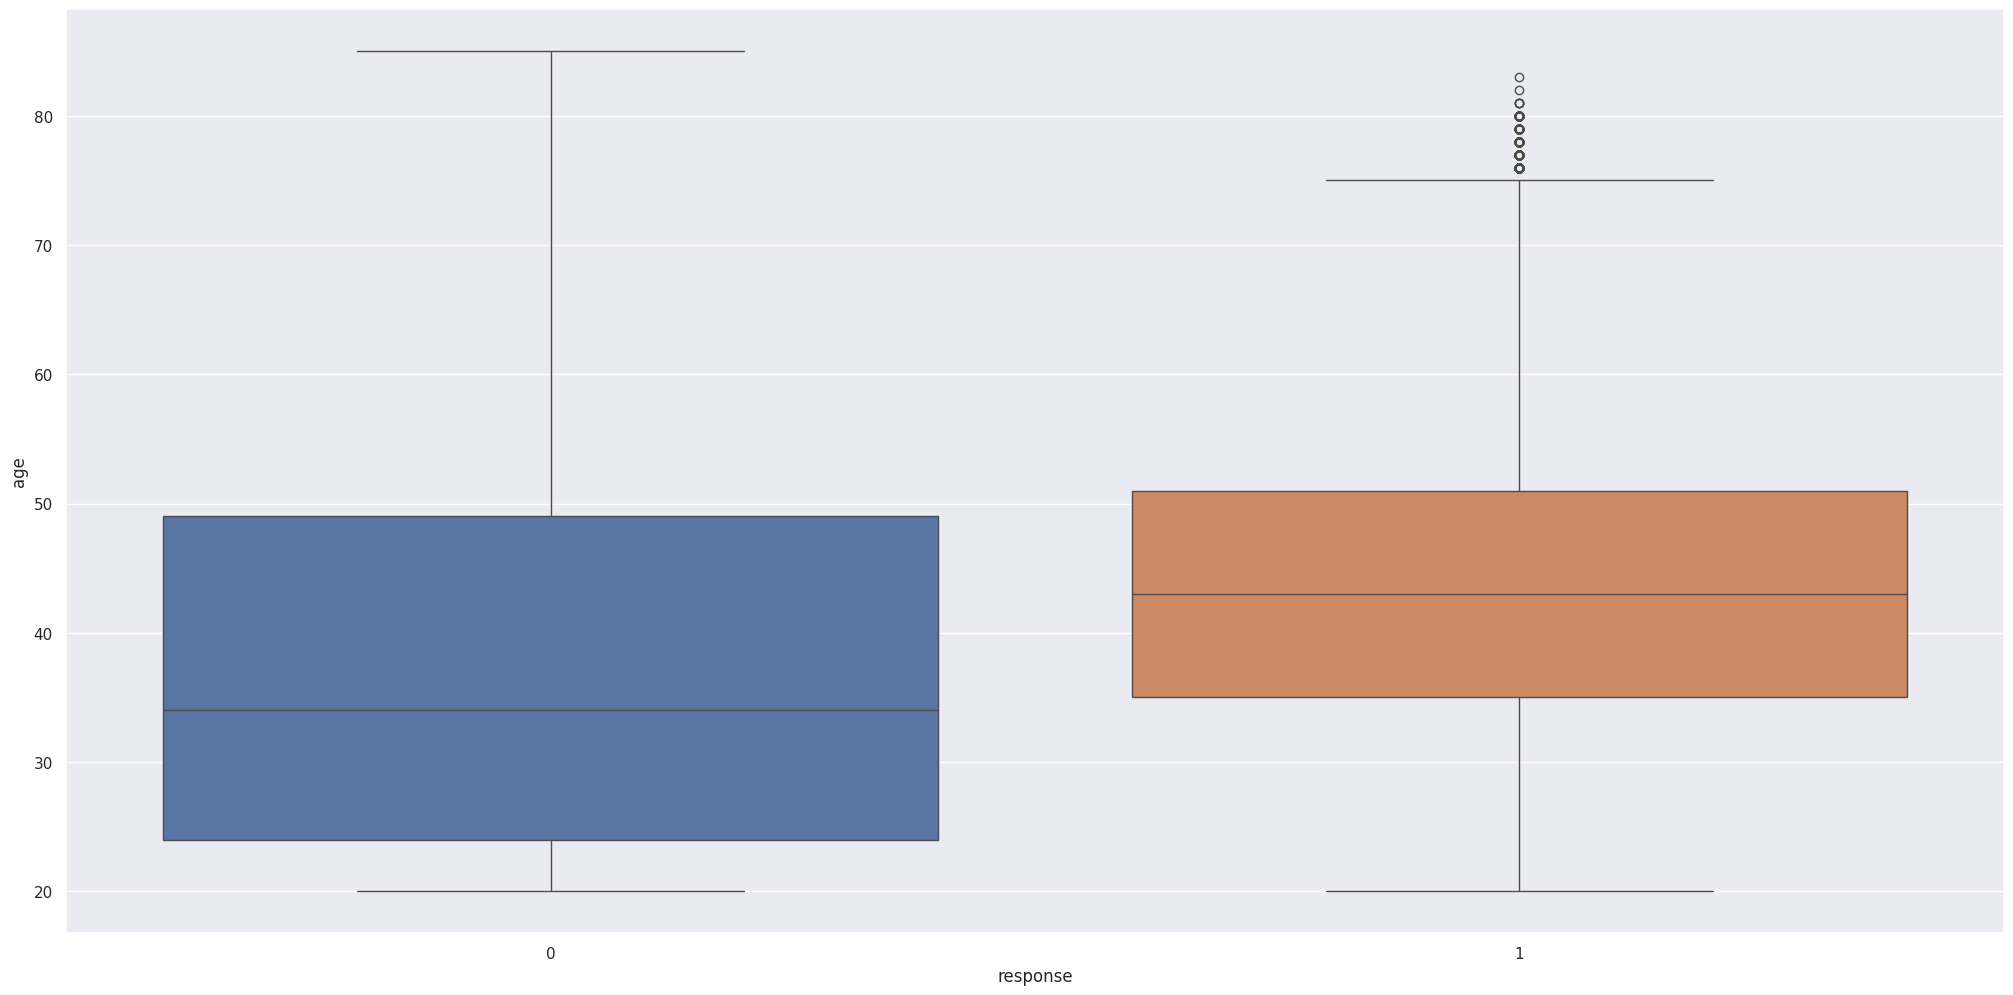

In [18]:
sns.boxplot( x='response', y='age', hue='response', data=df4, legend=False )

<Axes: xlabel='age', ylabel='Count'>

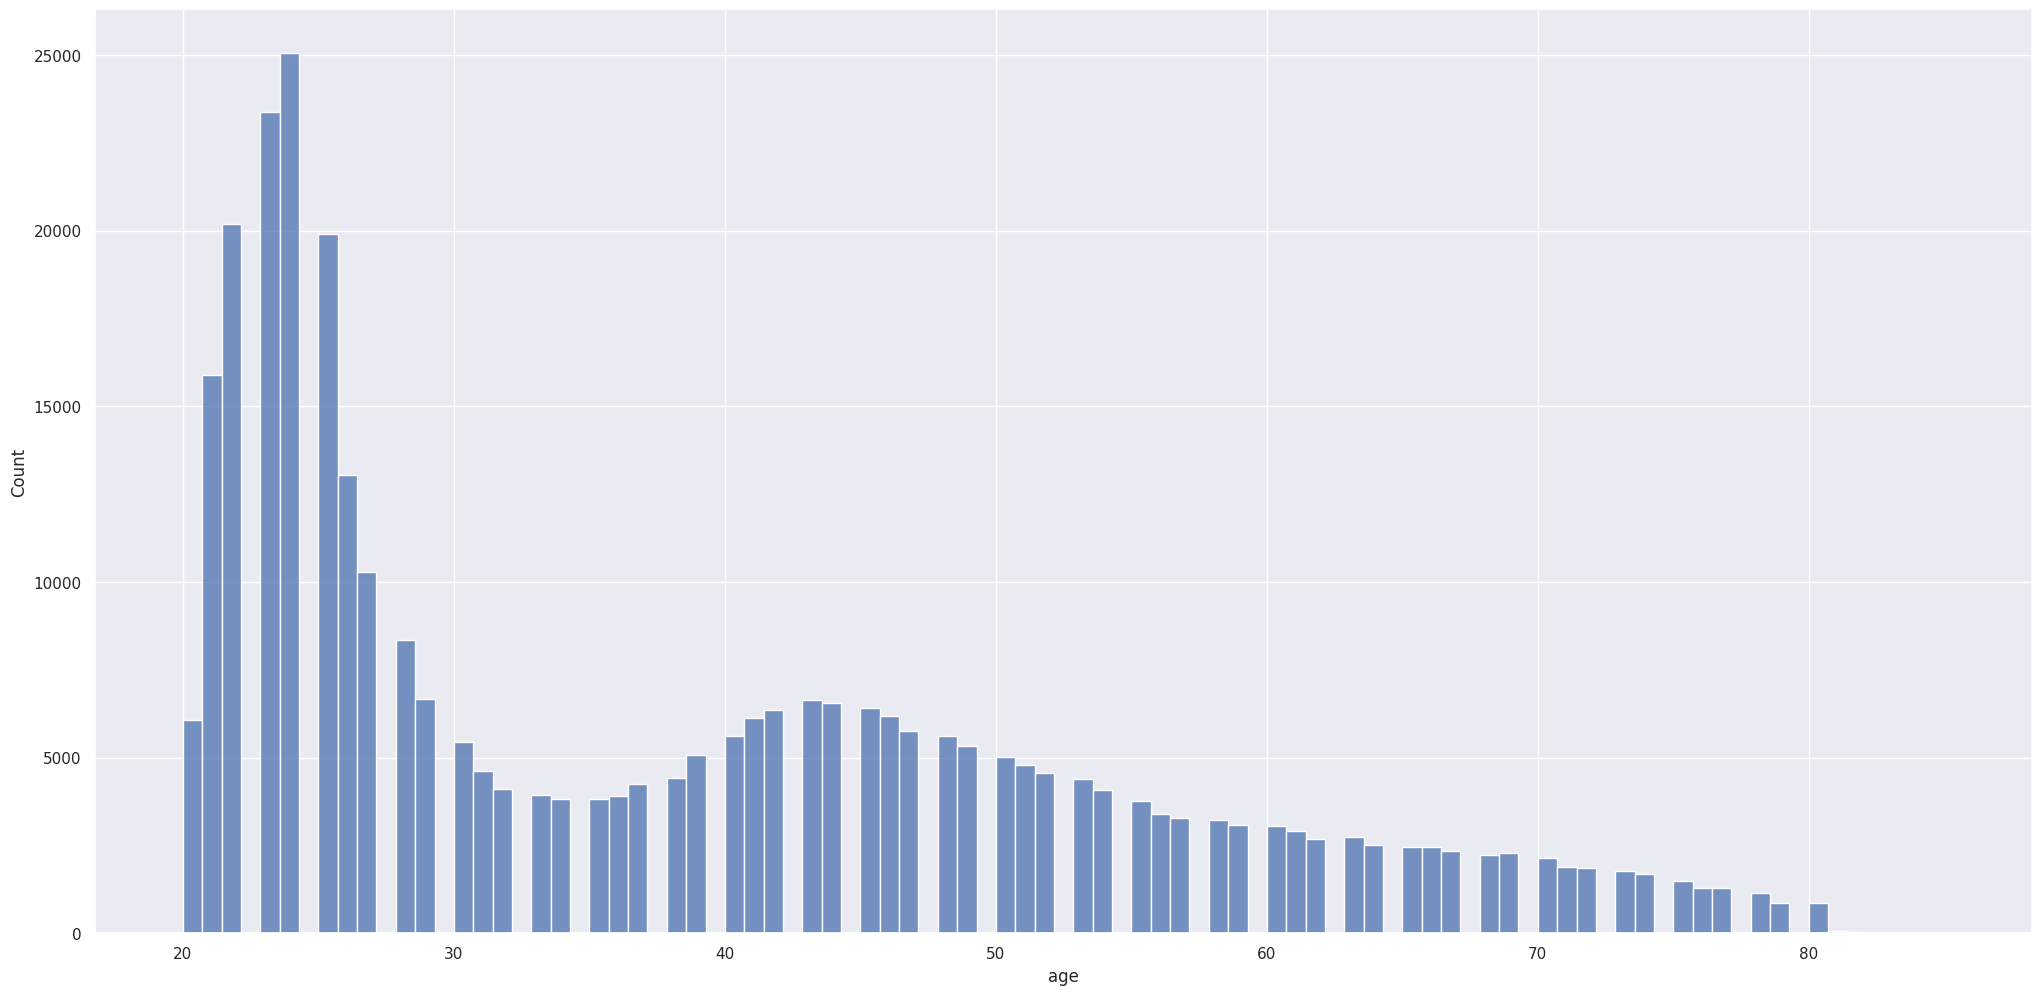

In [19]:
aux00 = df4.loc[df4['response'] == 0, 'age']
sns.histplot( aux00 )

<Axes: xlabel='age', ylabel='Count'>

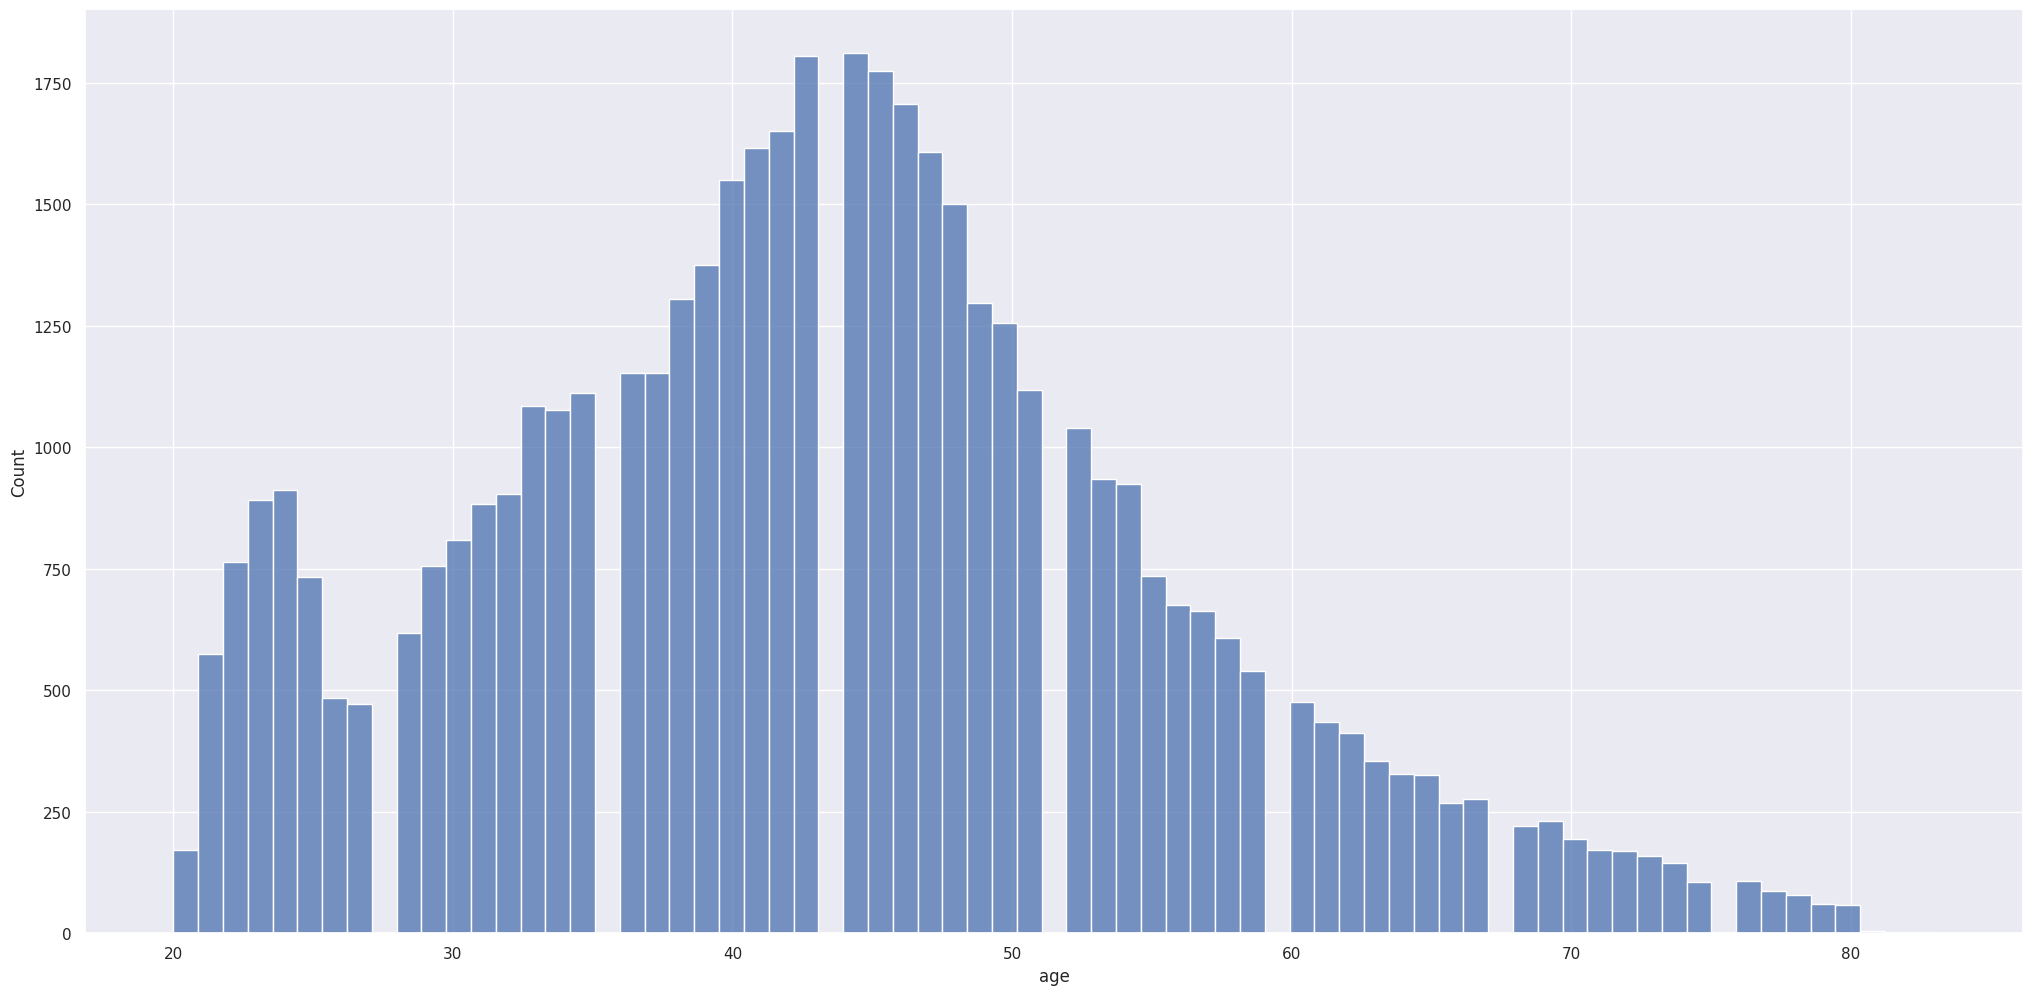

In [20]:
aux00 = df4.loc[df4['response'] == 1, 'age']
sns.histplot( aux00 )

### 4.1.2. Gender

<Axes: xlabel='gender', ylabel='count'>

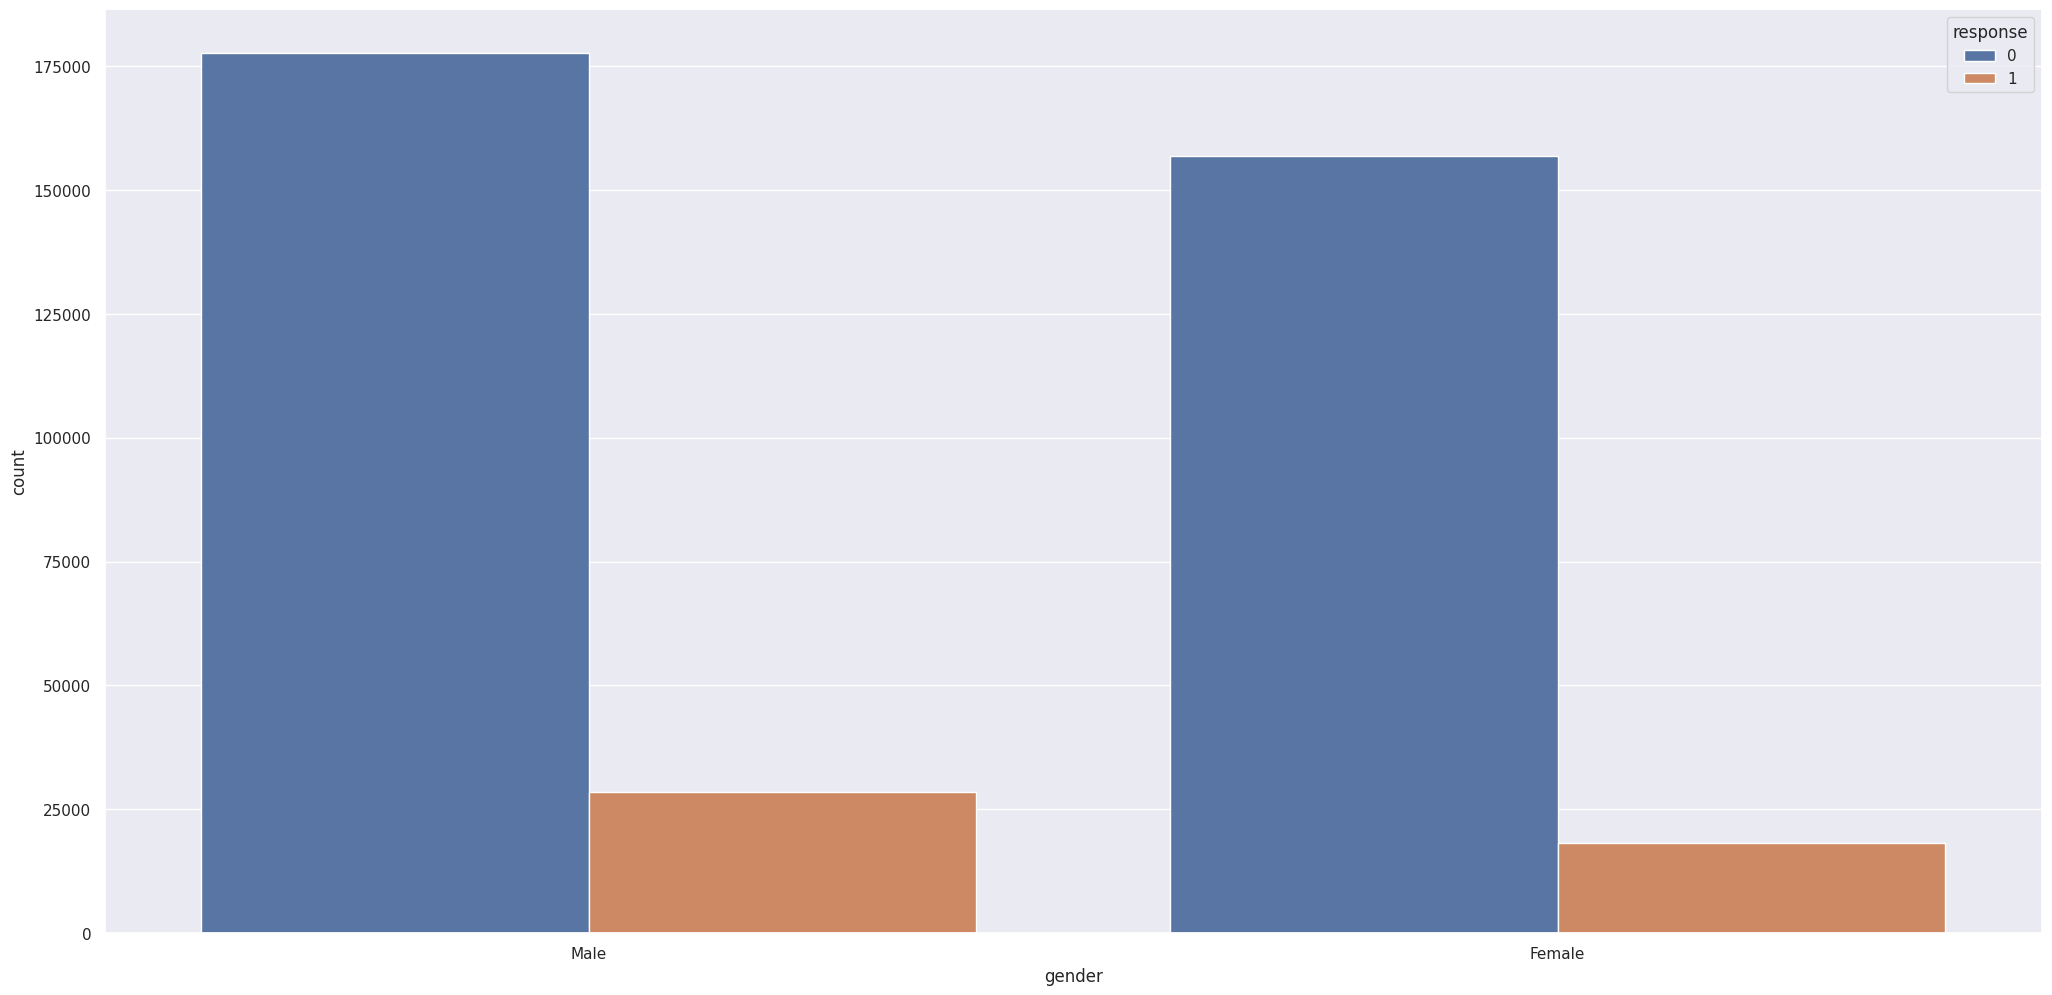

In [21]:
aux = df4[['gender', 'response']].value_counts().reset_index(name='count')
sns.barplot(y='count', x='gender', hue='response', data=aux)

### 4.1.3. Anual Income

<Axes: xlabel='response', ylabel='annual_premium'>

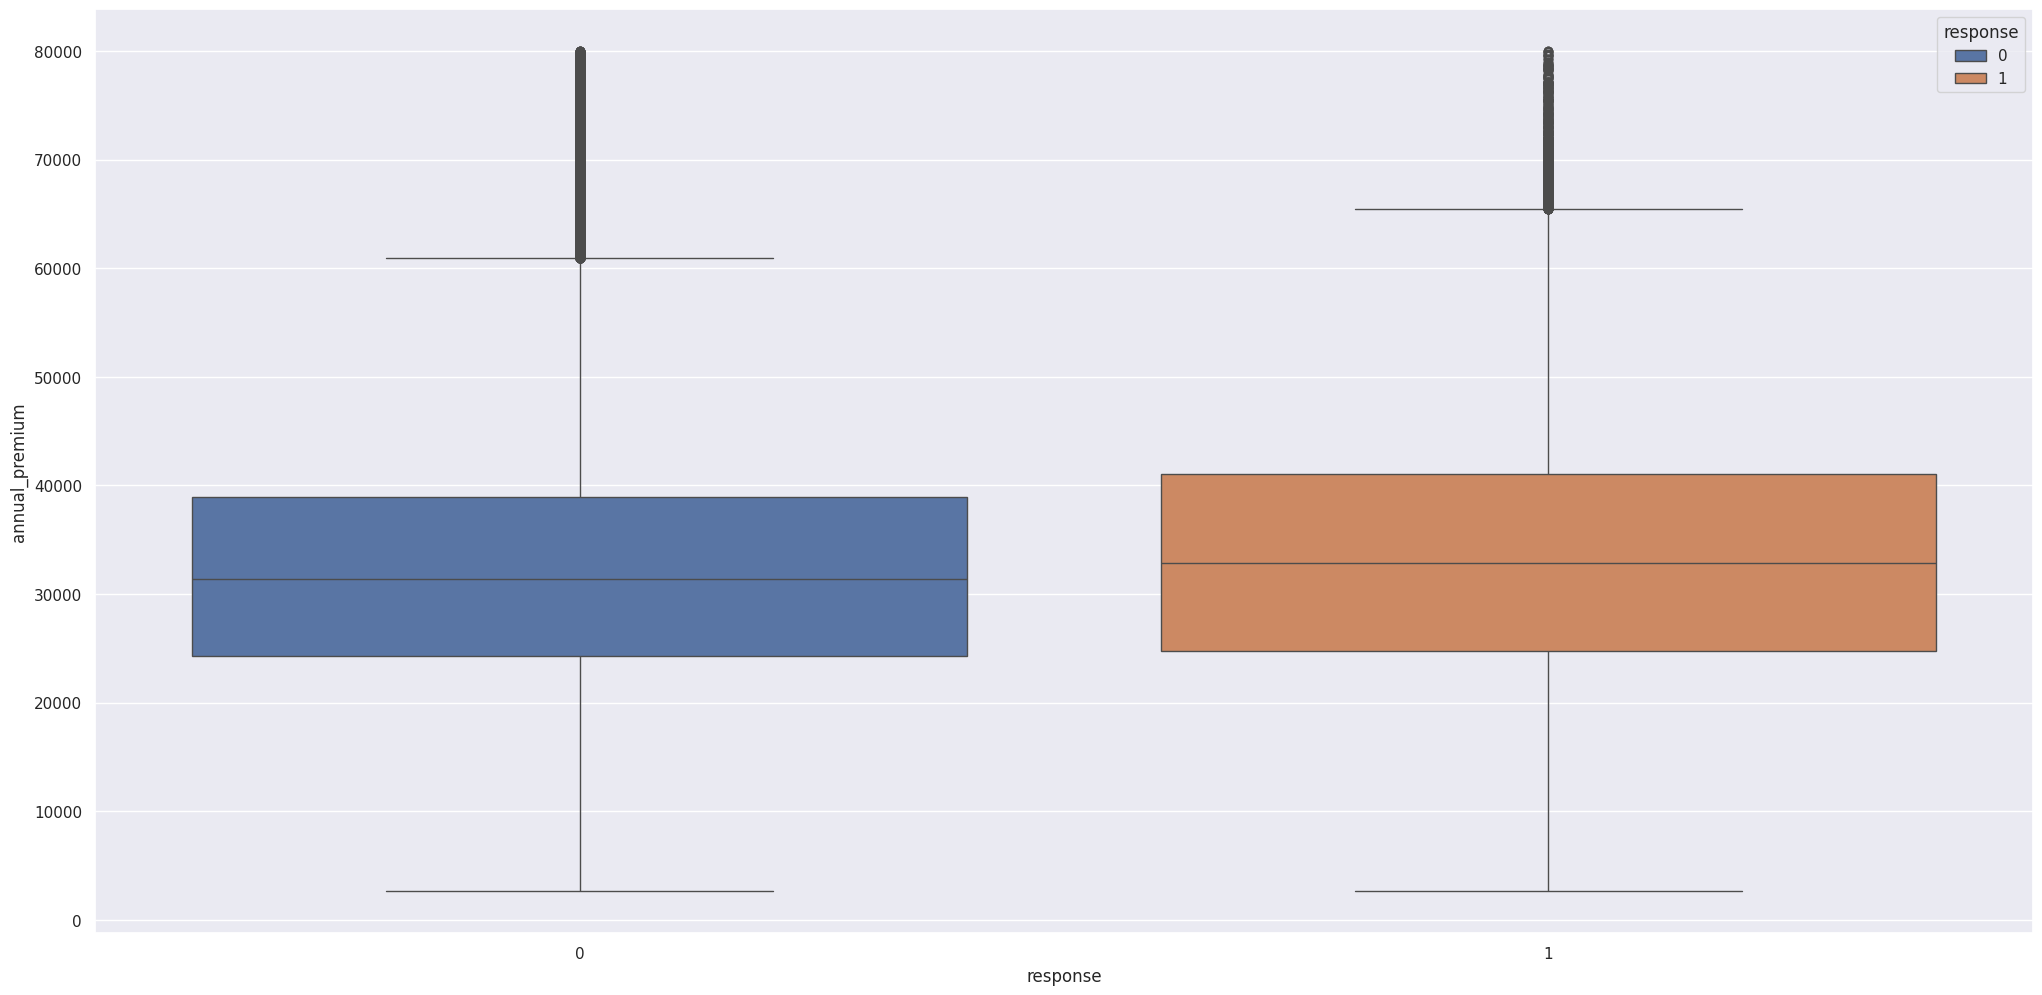

In [22]:
aux = df4[df4['annual_premium'] < 80000]
sns.boxplot( x='response', y='annual_premium', hue='response', data=aux )

<Axes: xlabel='annual_premium', ylabel='Count'>

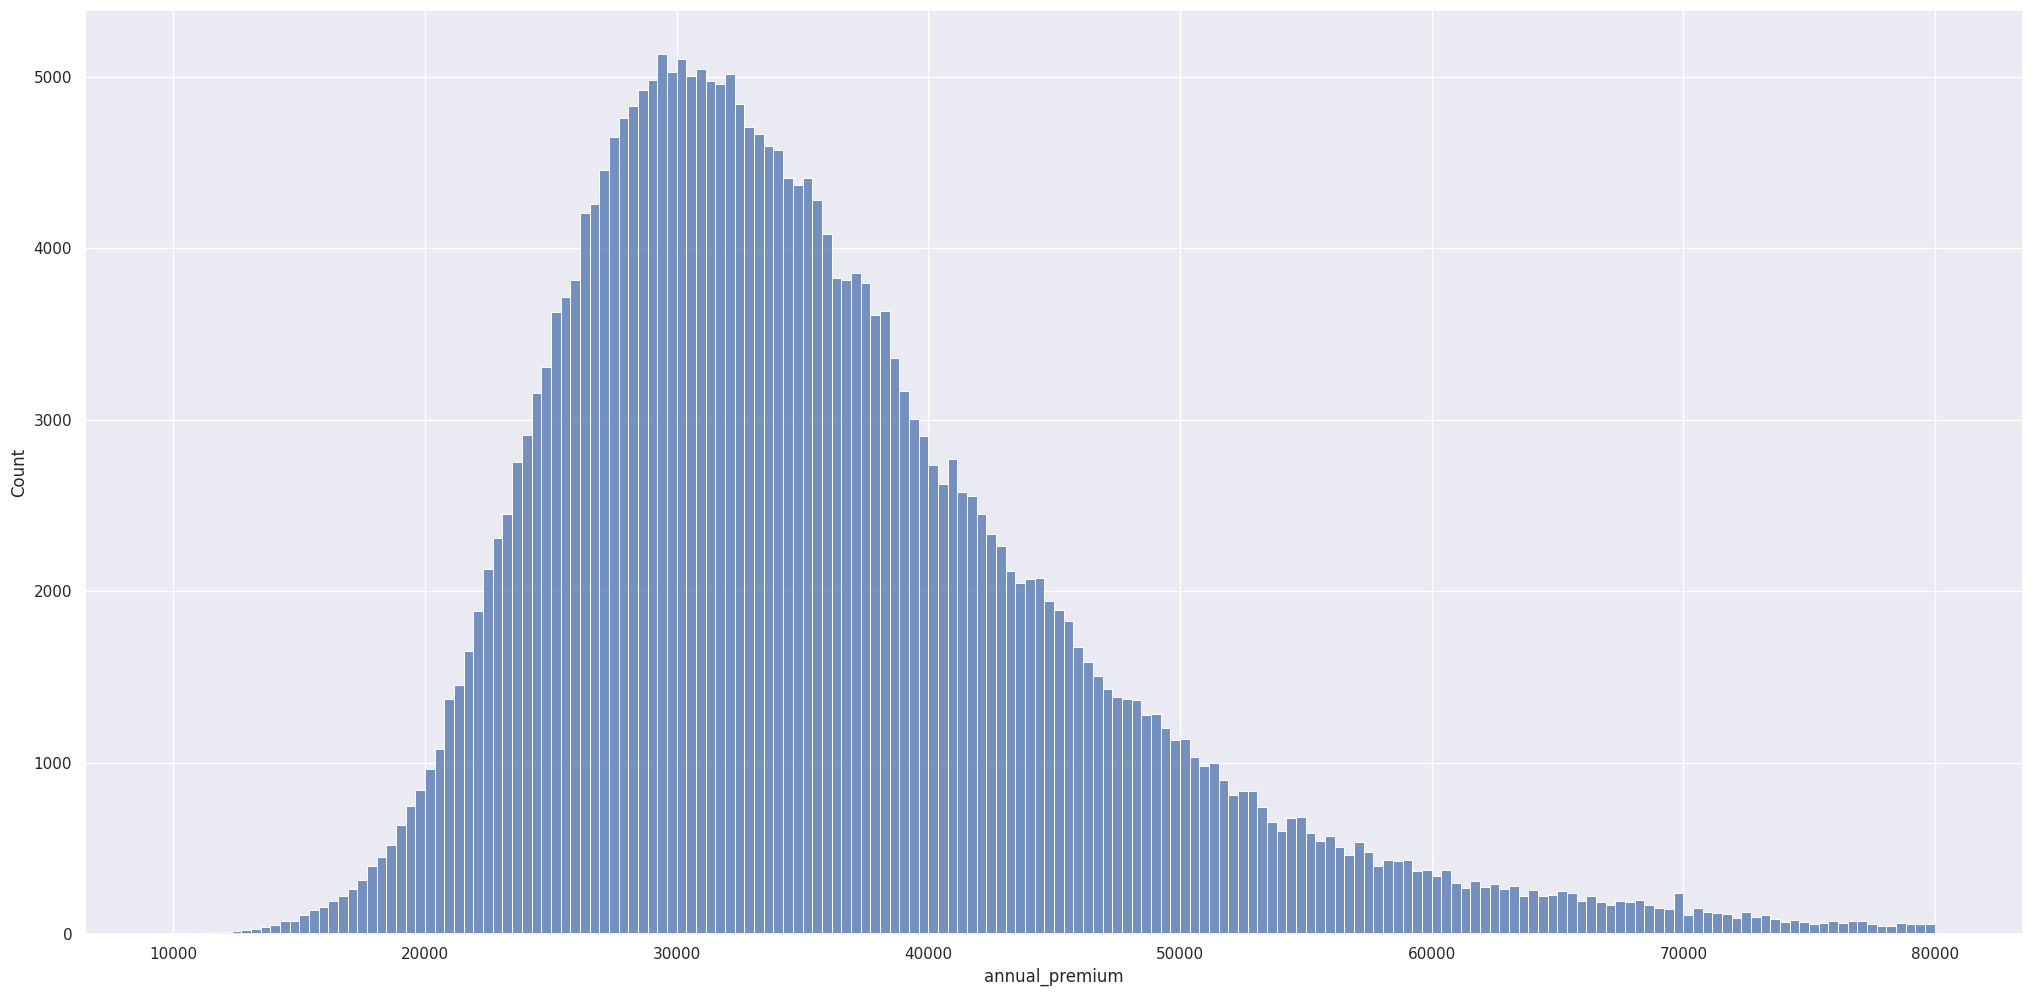

In [23]:
aux = df4[(df4['annual_premium'] > 10000) &(df4['annual_premium'] < 80000 )]
aux00 = aux.loc[aux['response'] == 0, 'annual_premium']
sns.histplot( aux00 )

<Axes: xlabel='annual_premium', ylabel='Count'>

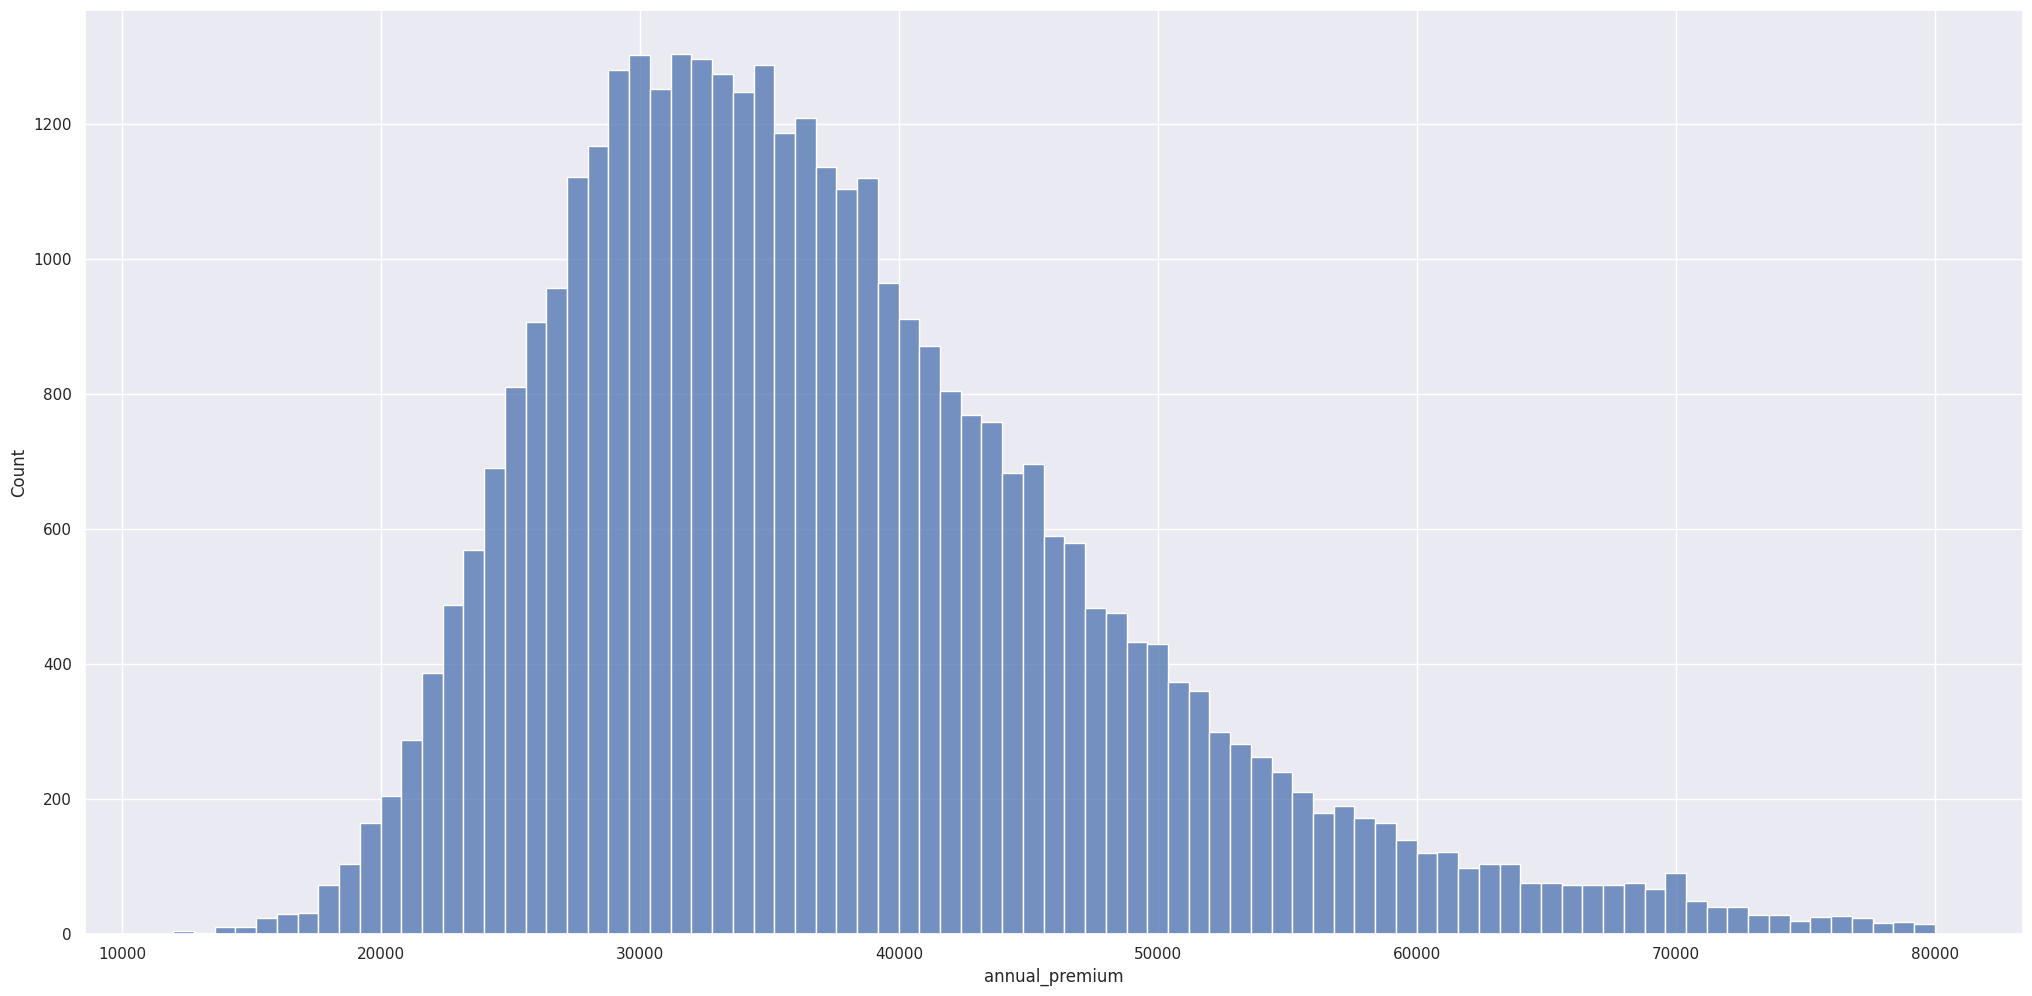

In [24]:
aux00 = aux.loc[aux['response'] == 1, 'annual_premium']
sns.histplot( aux00 )

### 4.1.4. Driving License

,response,driving_license,driving_license_perc
0,0,333628,0.877283
1,1,46669,0.122717


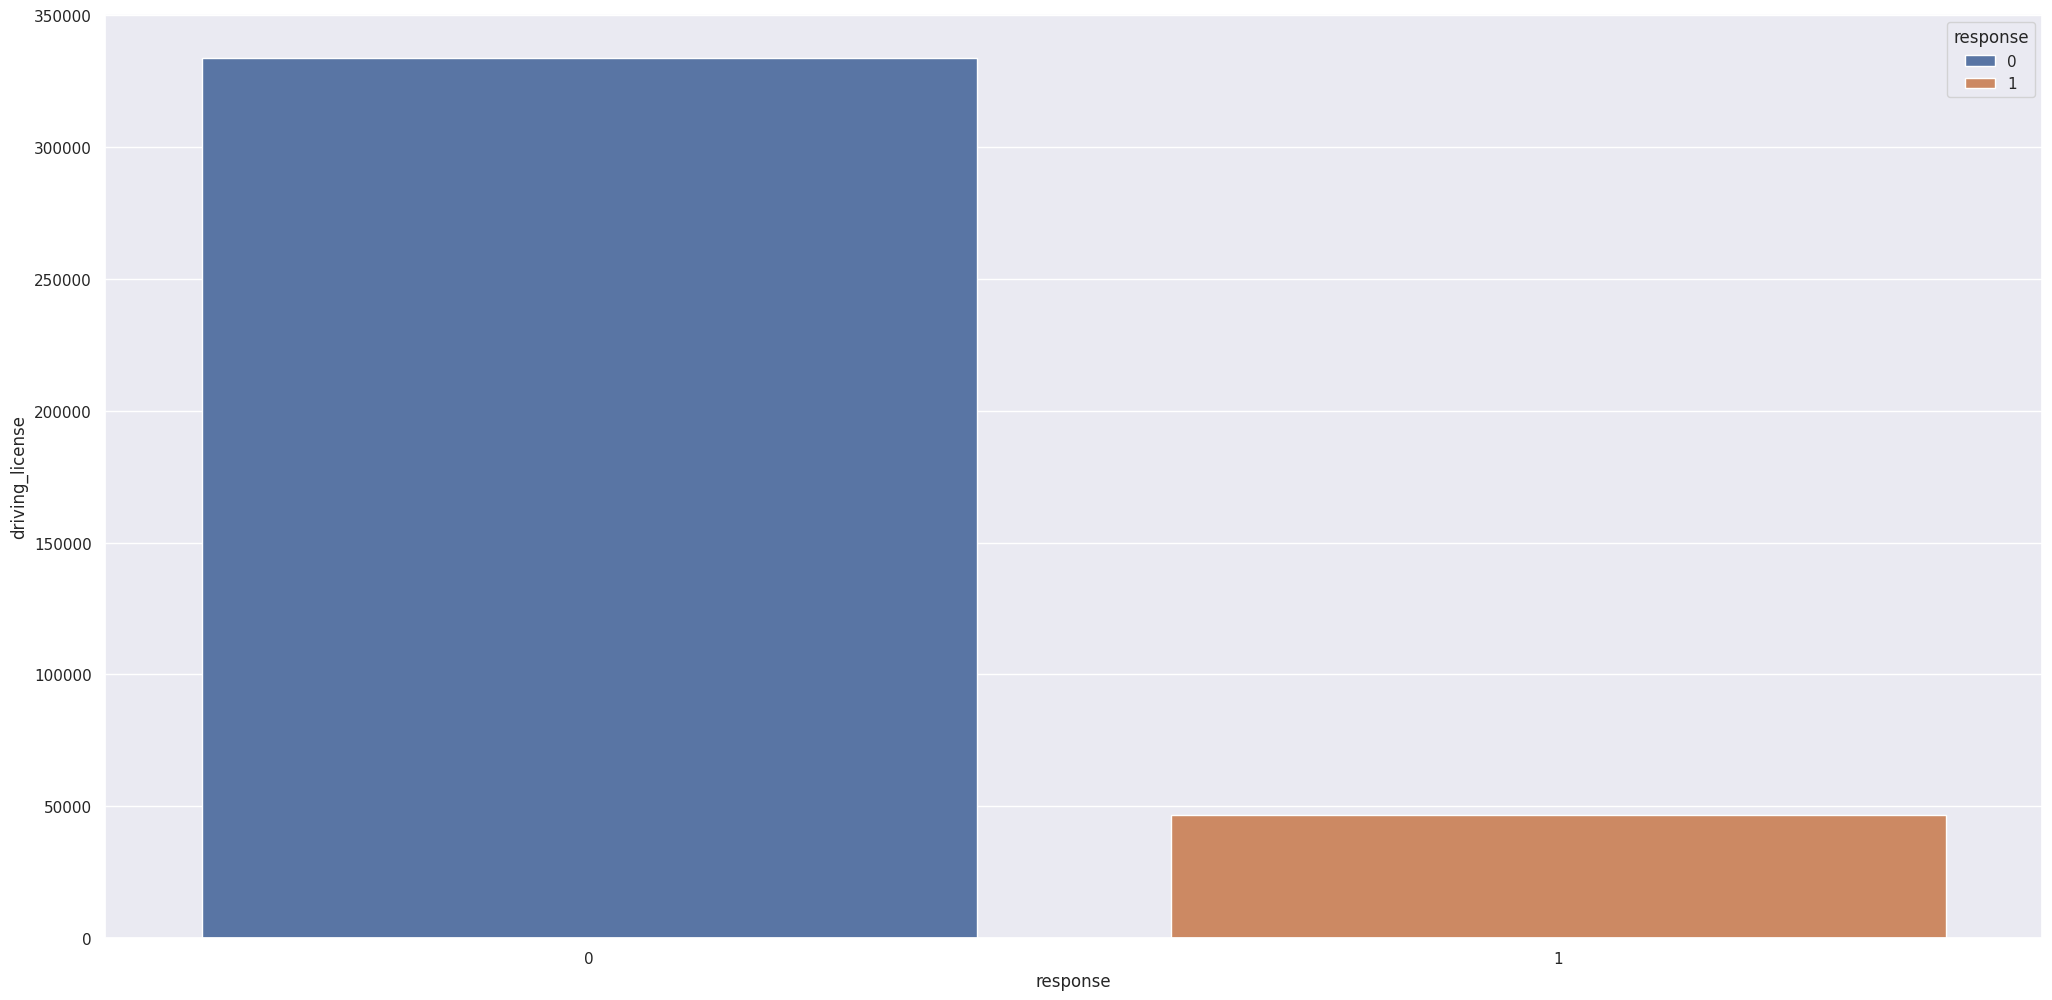

In [25]:
aux = df4[['driving_license', 'response']].groupby( 'response' ).sum().reset_index()
aux.head()
aux['driving_license_perc'] = aux['driving_license'] / aux['driving_license'].sum()
sns.barplot( x='response', y='driving_license', hue='response', data=aux )
aux

### 4.1.5. Region Code

<Axes: xlabel='region_code', ylabel='id'>

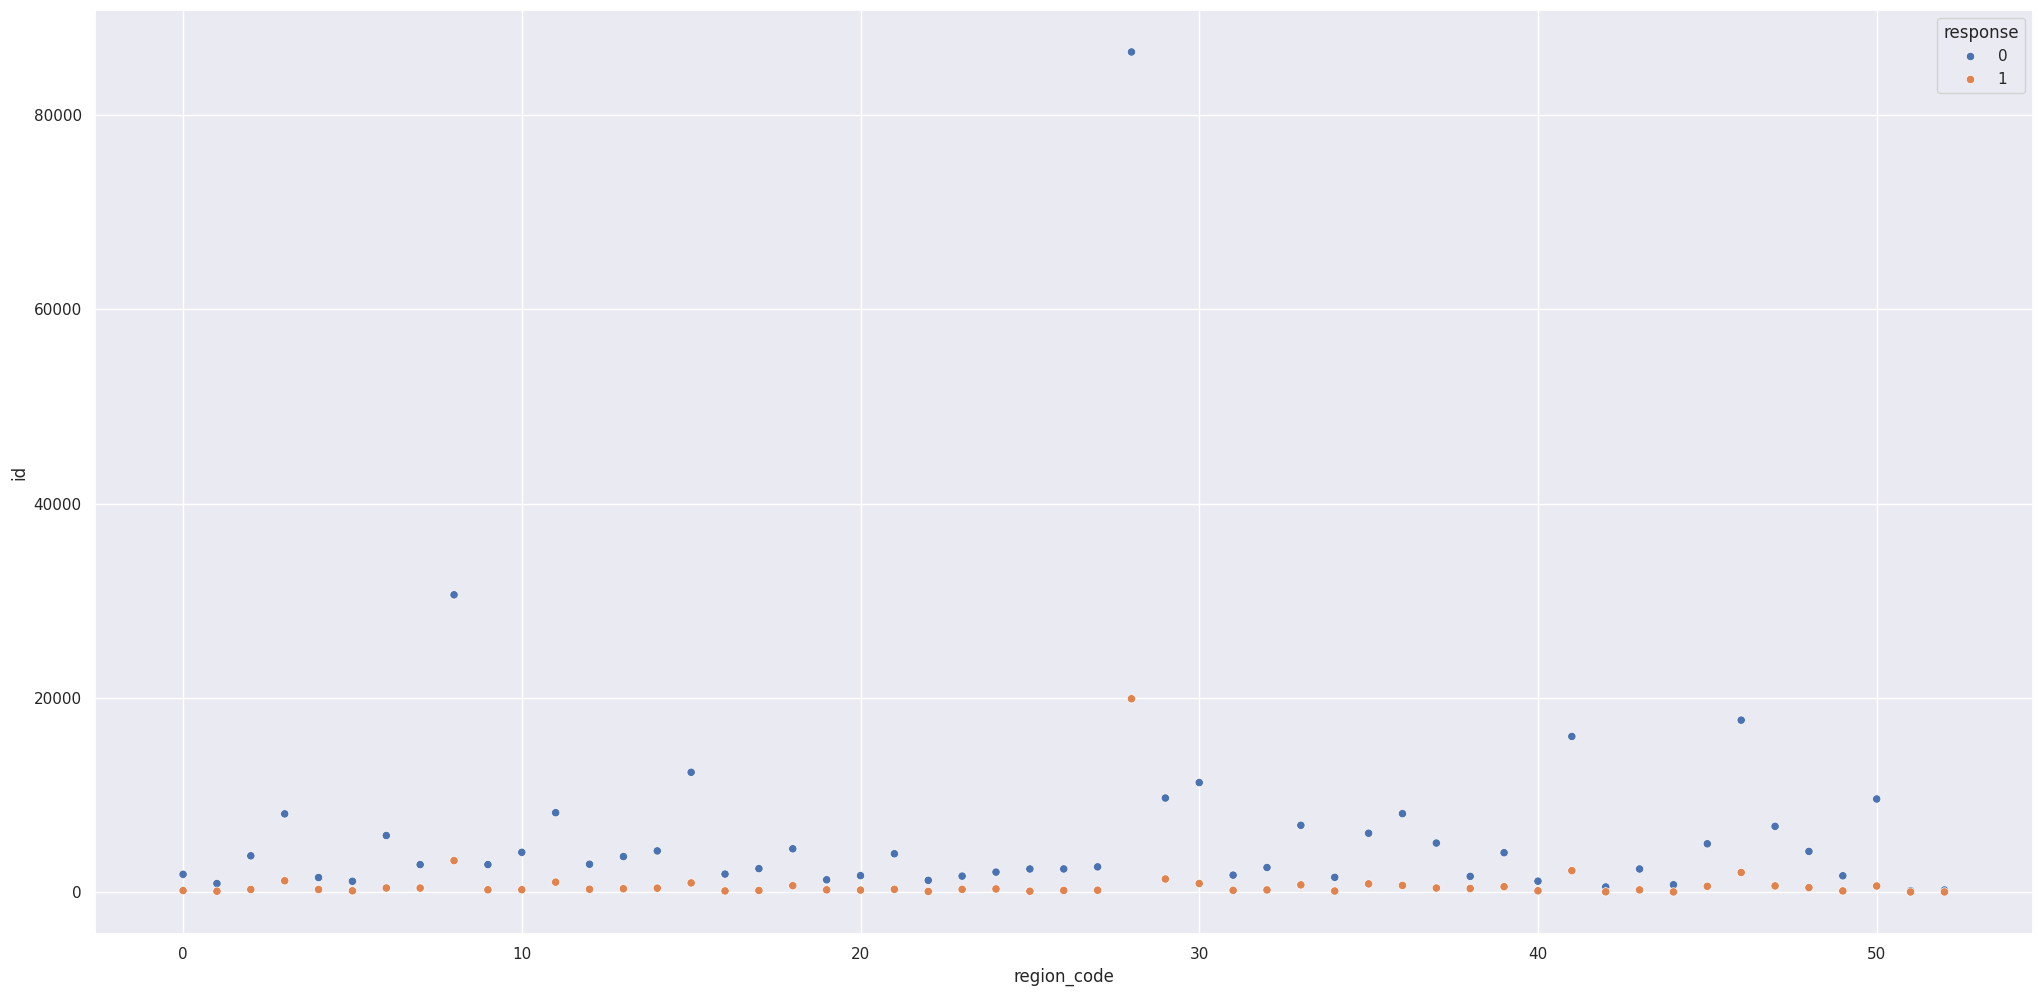

In [26]:
aux0 = df4[['id', 'region_code', 'response']].groupby( ['region_code', 'response'] ).count().reset_index()

sns.scatterplot( x='region_code', y='id', hue='response', data=aux0 )

### 4.1.6. Previously Insured

<Axes: xlabel='previously_insured', ylabel='id'>

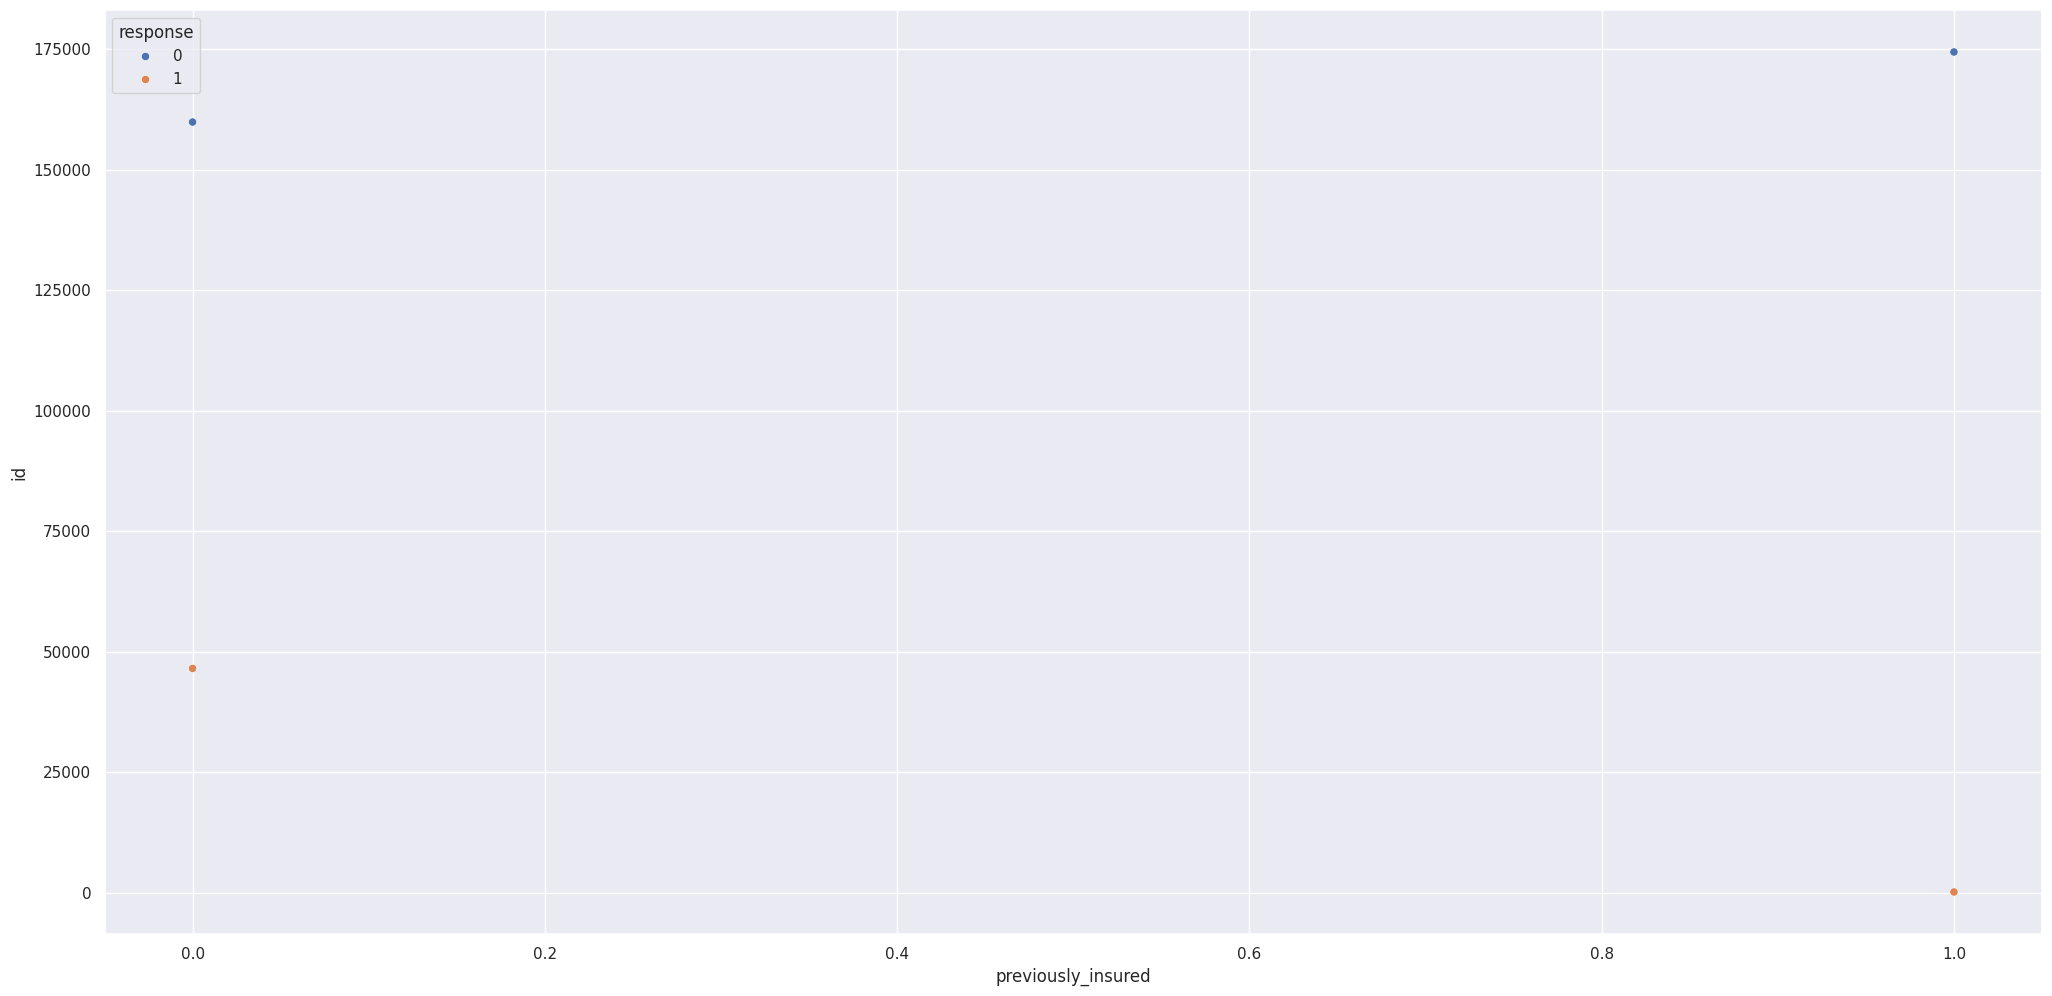

In [27]:
aux0 = df4[['id', 'previously_insured', 'response']].groupby( ['previously_insured', 'response'] ).count().reset_index()

sns.scatterplot( x='previously_insured', y='id', hue='response', data=aux0 )

In [28]:
pd.crosstab(df4['previously_insured'], df4['response'] ).apply( lambda x: x / x.sum(), axis=1 )

response,0,1
previously_insured,,
0,0.774546,0.225454
1,0.999095,0.000905


### 4.1.7. Vehicle Age

In [29]:
df4[['vehicle_age', 'response']].value_counts( normalize=True ).reset_index().sort_values('vehicle_age')

,vehicle_age,response,proportion
1,below_1_year,0,0.413488
4,below_1_year,1,0.018897
0,between_1_2_year,0,0.434285
2,between_1_2_year,1,0.091328
3,over_2_years,0,0.029663
5,over_2_years,1,0.012338


### 4.1.8. Vehicle Damage

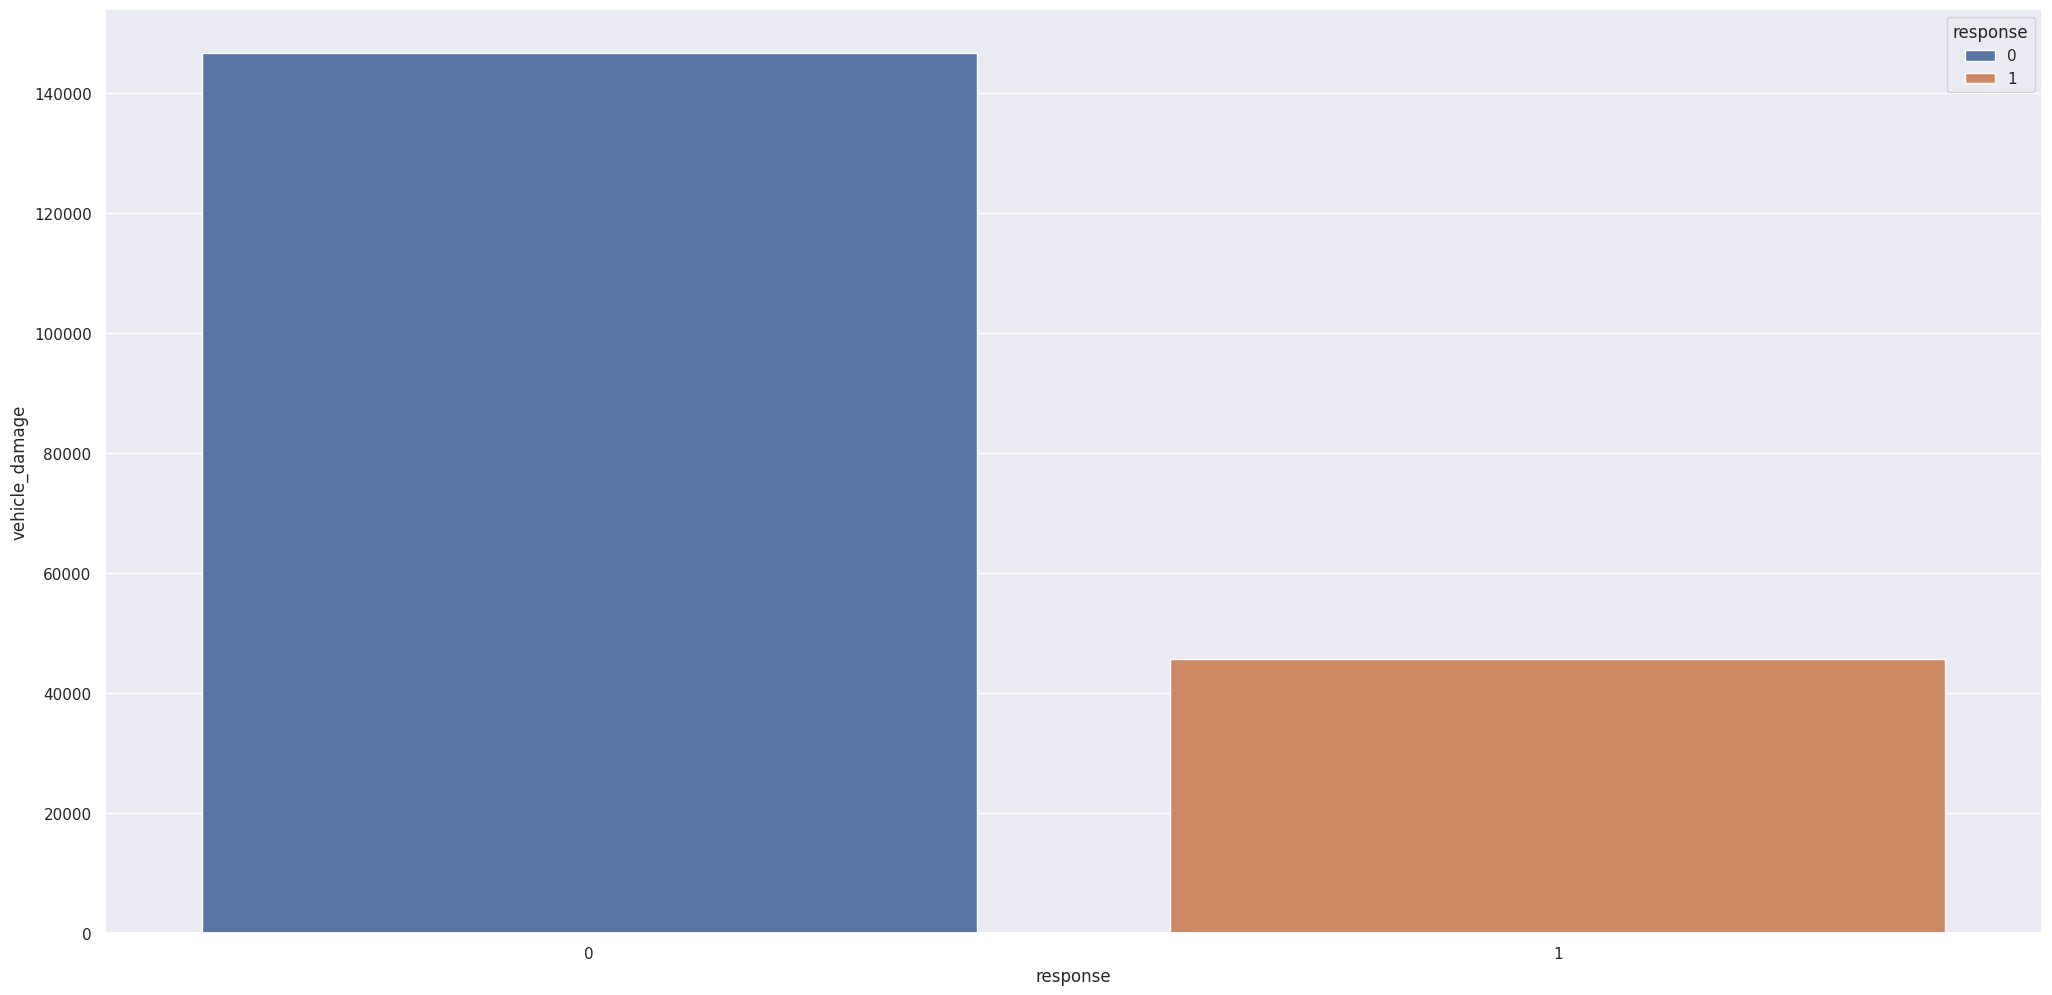

In [30]:
aux = df4[['vehicle_damage', 'response']].groupby( 'response' ).sum().reset_index()
sns.barplot( x='response', y='vehicle_damage', hue='response', data=aux );

### 4.1.9. Policy Sales Channel - Stacked Percentage Bar

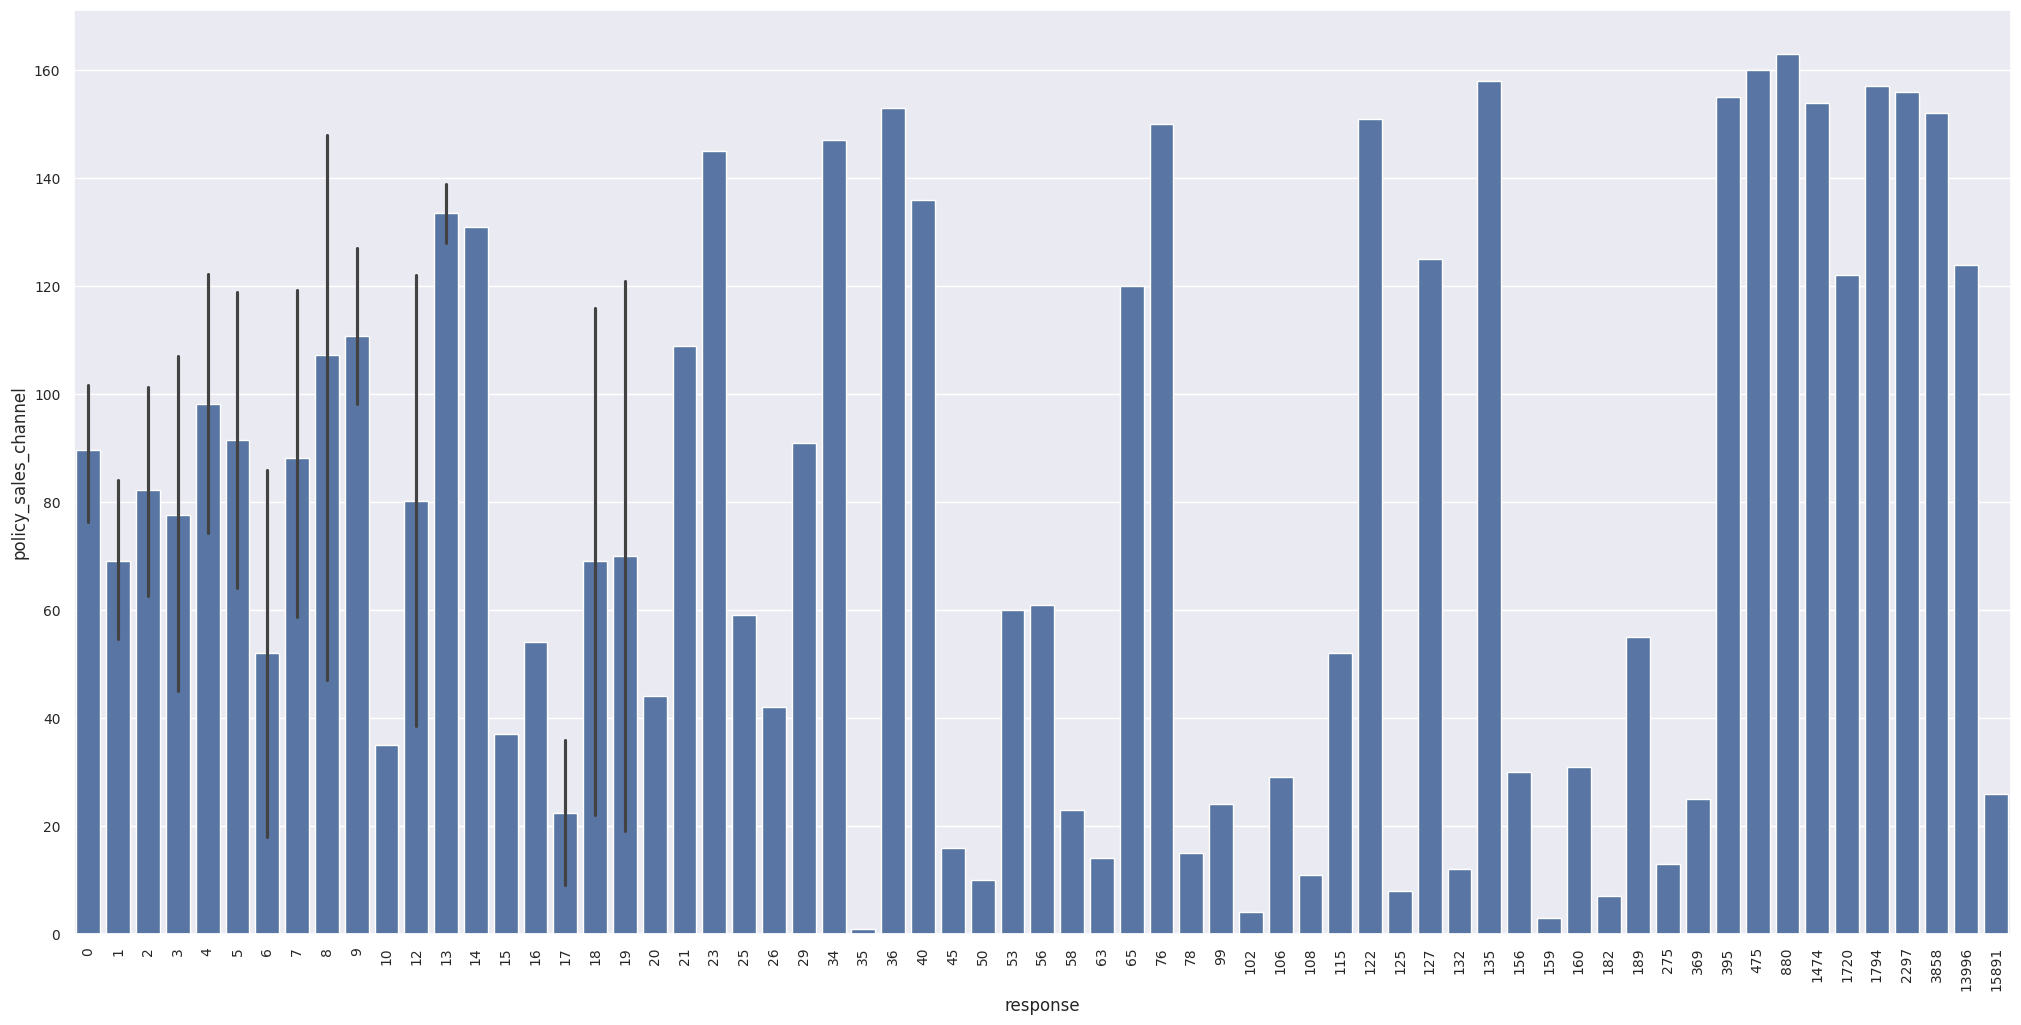

In [31]:
aux = df4[['policy_sales_channel', 'response']].groupby( 'policy_sales_channel' ).sum().reset_index()

fig, ax = plt.subplots(figsize=(25, 12)) # Increased figure size
sns.barplot(
    x='response', y='policy_sales_channel',
    data=aux, ax=ax
)

ax.tick_params(labelsize=10);
ax.tick_params(axis='x', rotation=90);

In [32]:
aux01 = df4[['policy_sales_channel', 'response']].groupby( 'policy_sales_channel' ).sum().reset_index()
aux02 = df4[['id', 'policy_sales_channel']].groupby( 'policy_sales_channel' ).size().reset_index().rename( columns={0:'total_responses'})

aux = pd.merge( aux01, aux02, how='inner', on='policy_sales_channel' )
aux.head()

,policy_sales_channel,response,total_responses
0,1.0,35,1074
1,2.0,1,4
2,3.0,159,523
3,4.0,102,509
4,6.0,0,3


### 4.1.10. Vintage

<Axes: xlabel='response', ylabel='vintage'>

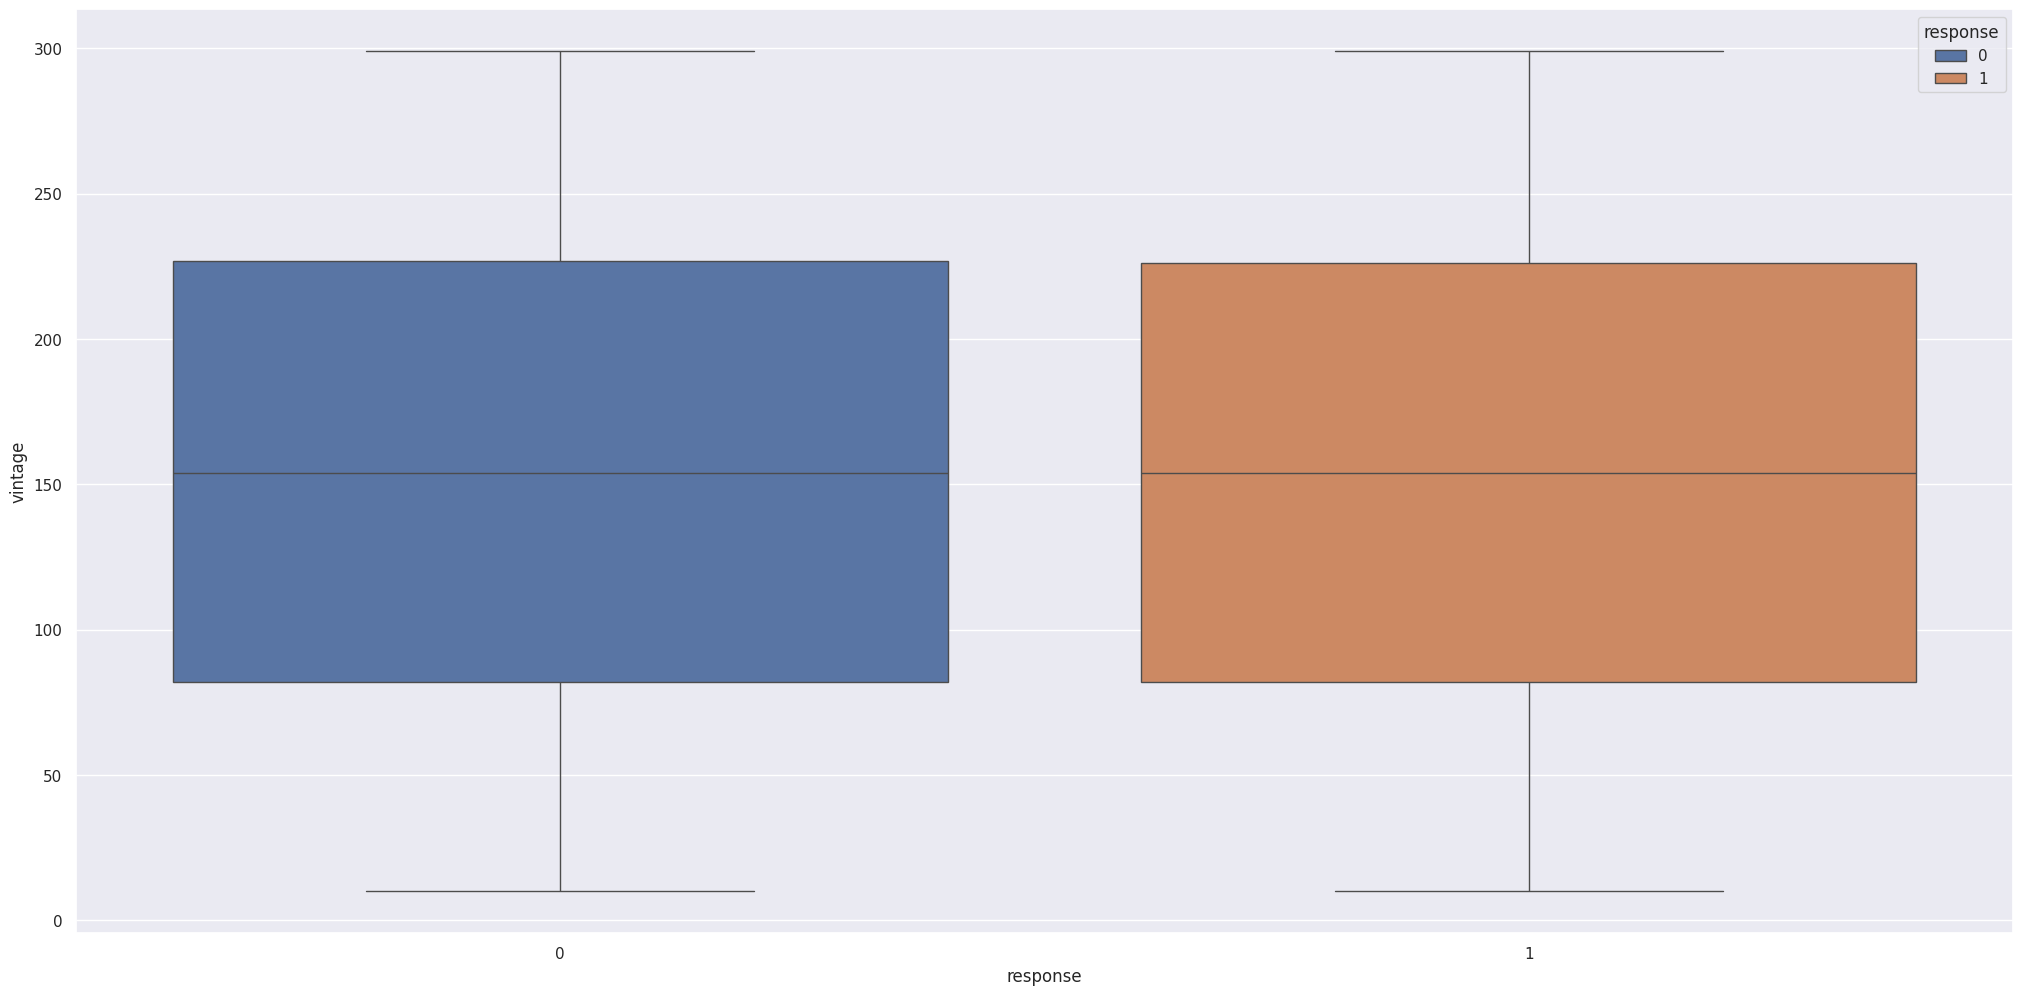

In [33]:
sns.boxplot( x='response', y='vintage', hue='response', data=df4 )

<Axes: xlabel='vintage', ylabel='Count'>

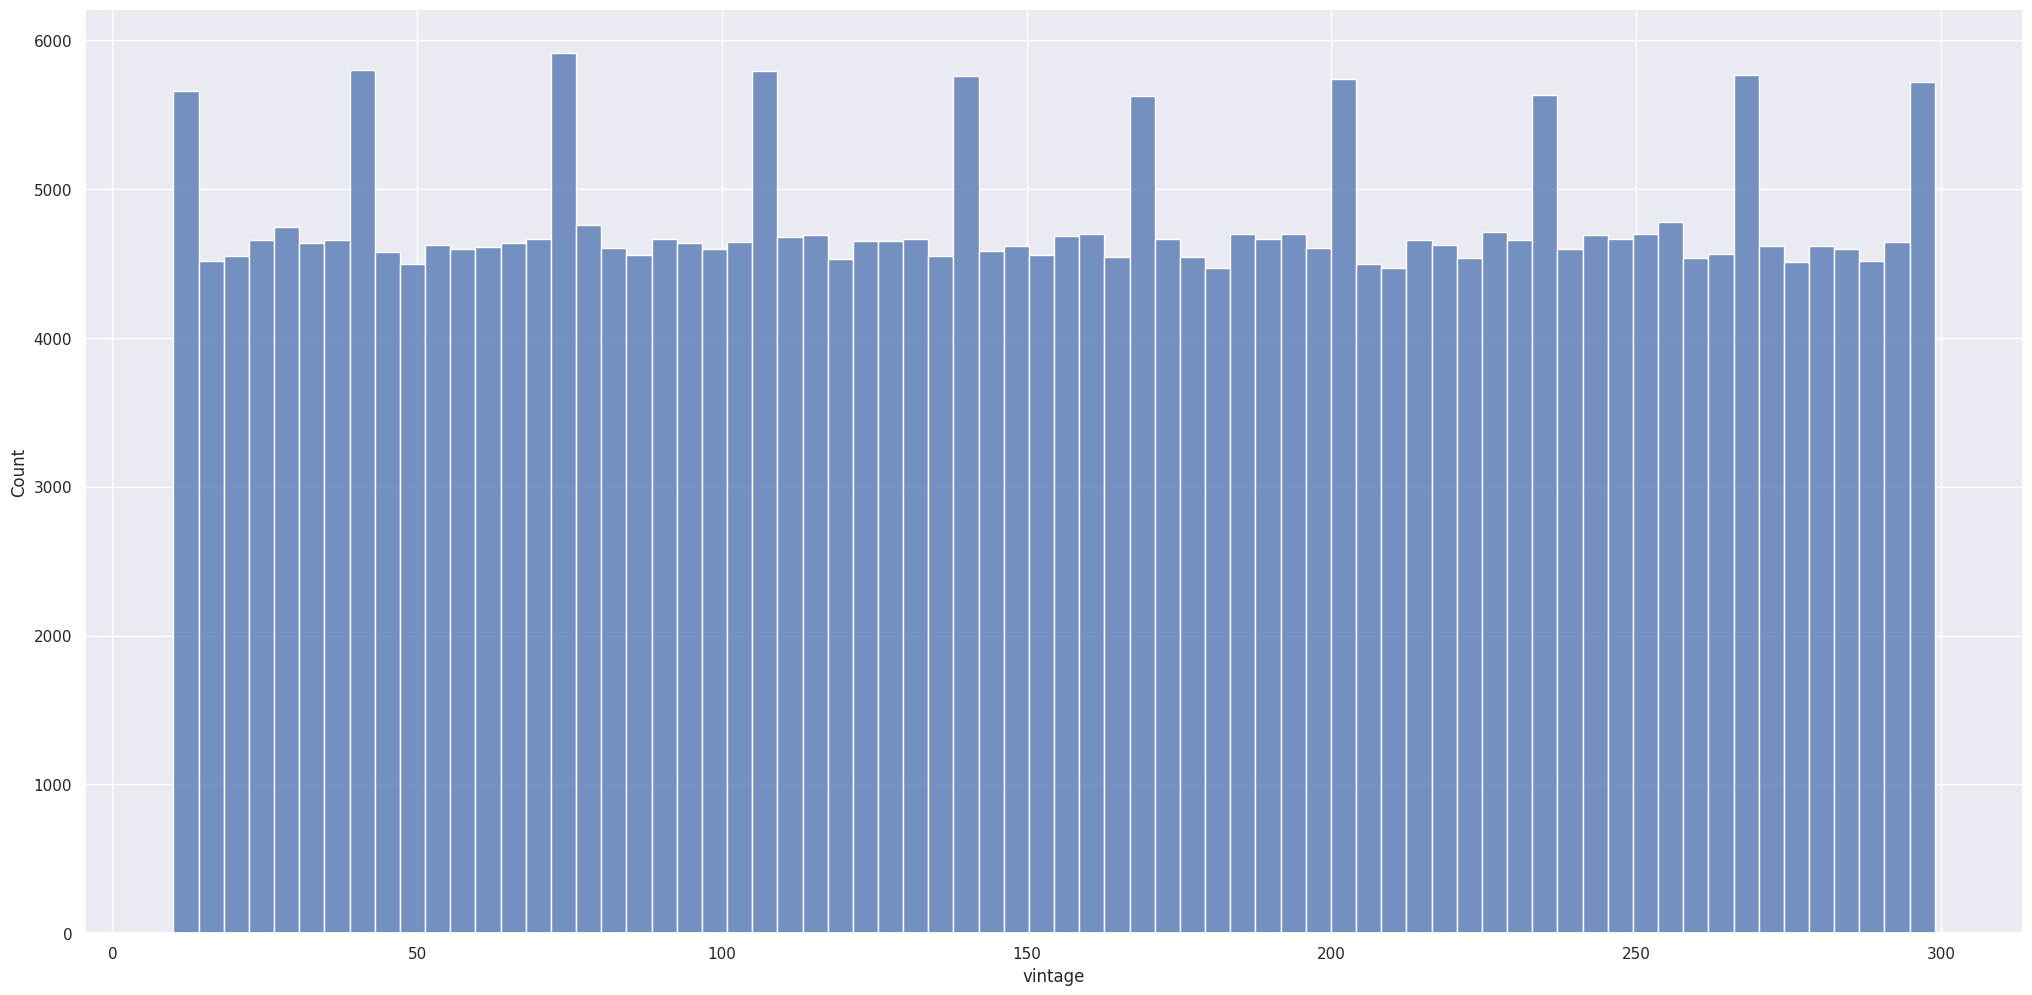

In [34]:
aux = df4.loc[df4['response'] == 0, 'vintage']
sns.histplot( aux )

<Axes: xlabel='vintage', ylabel='Count'>

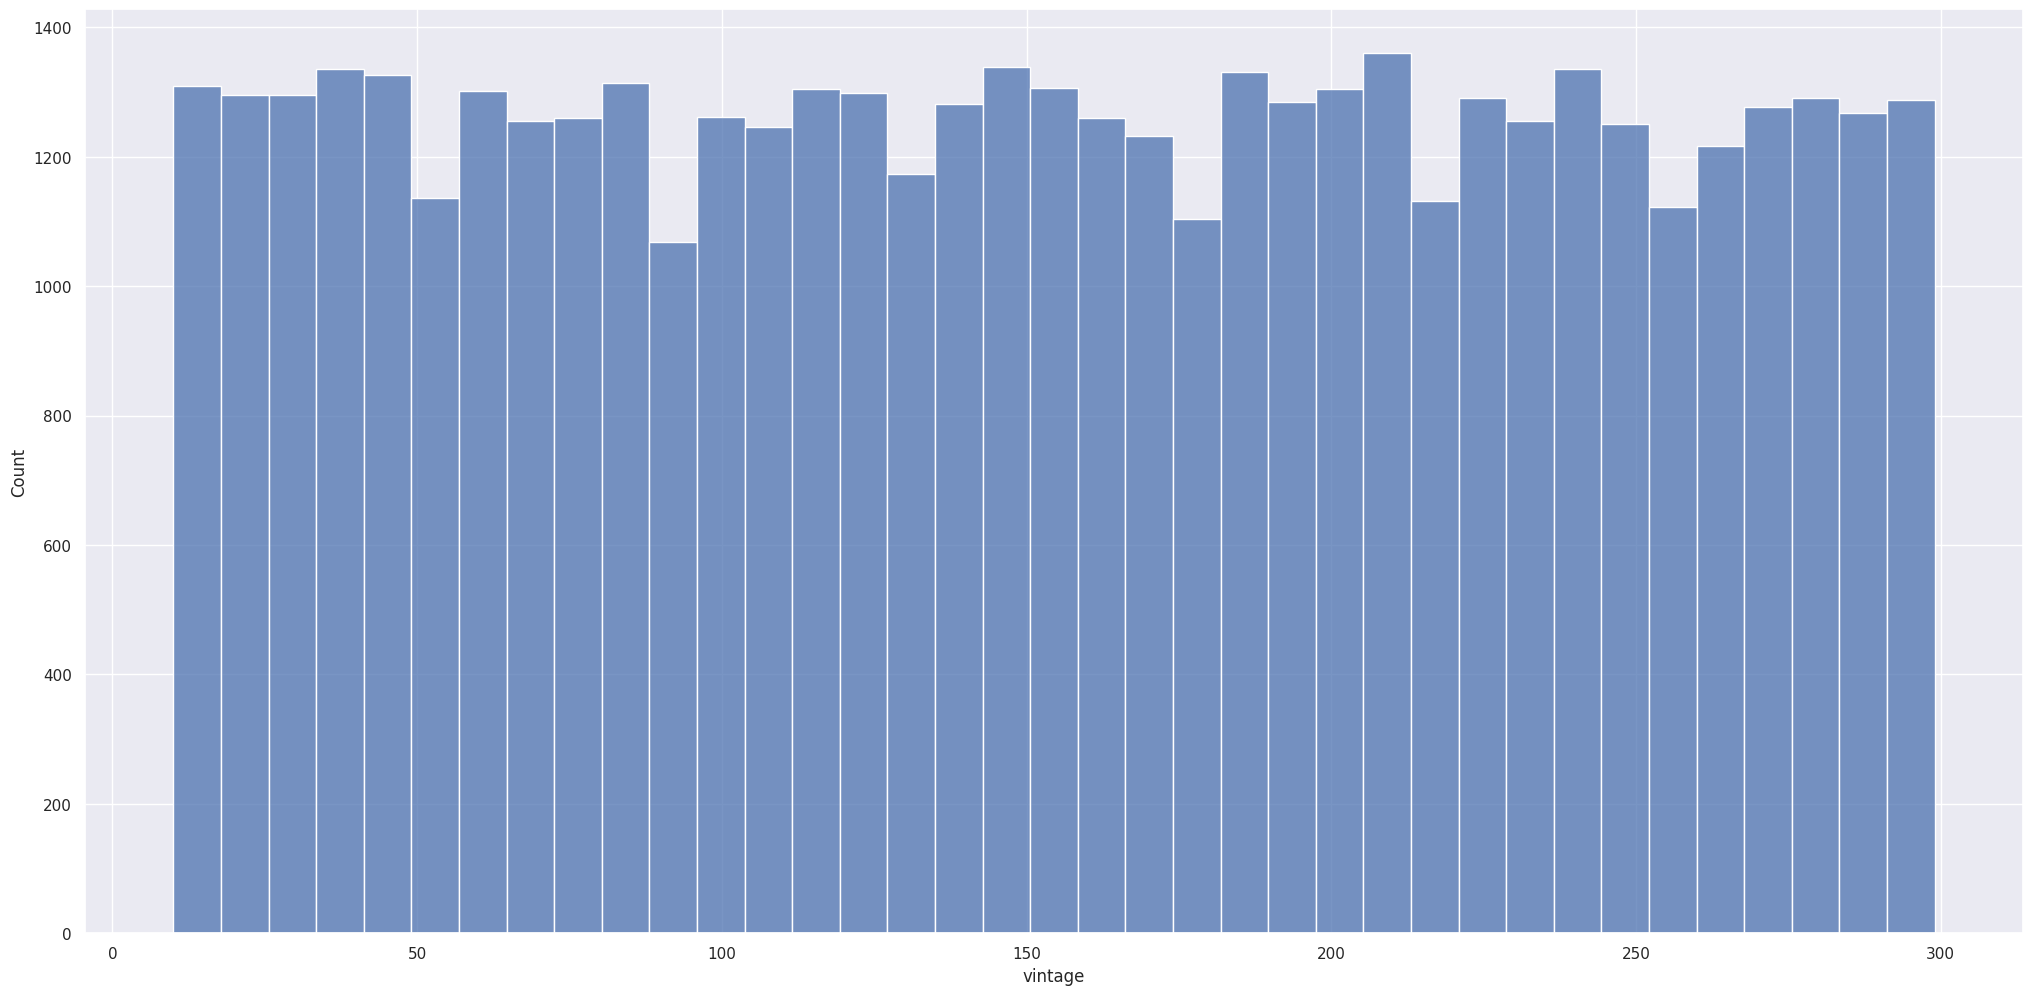

In [35]:
aux = df4.loc[df4['response'] == 1, 'vintage']
sns.histplot( aux )

In [36]:
df = pd.pivot_table( index='vintage', columns='response', values='id', data=df4).reset_index()
df.columns = ['vintage', 'no_response', 'yes_response']

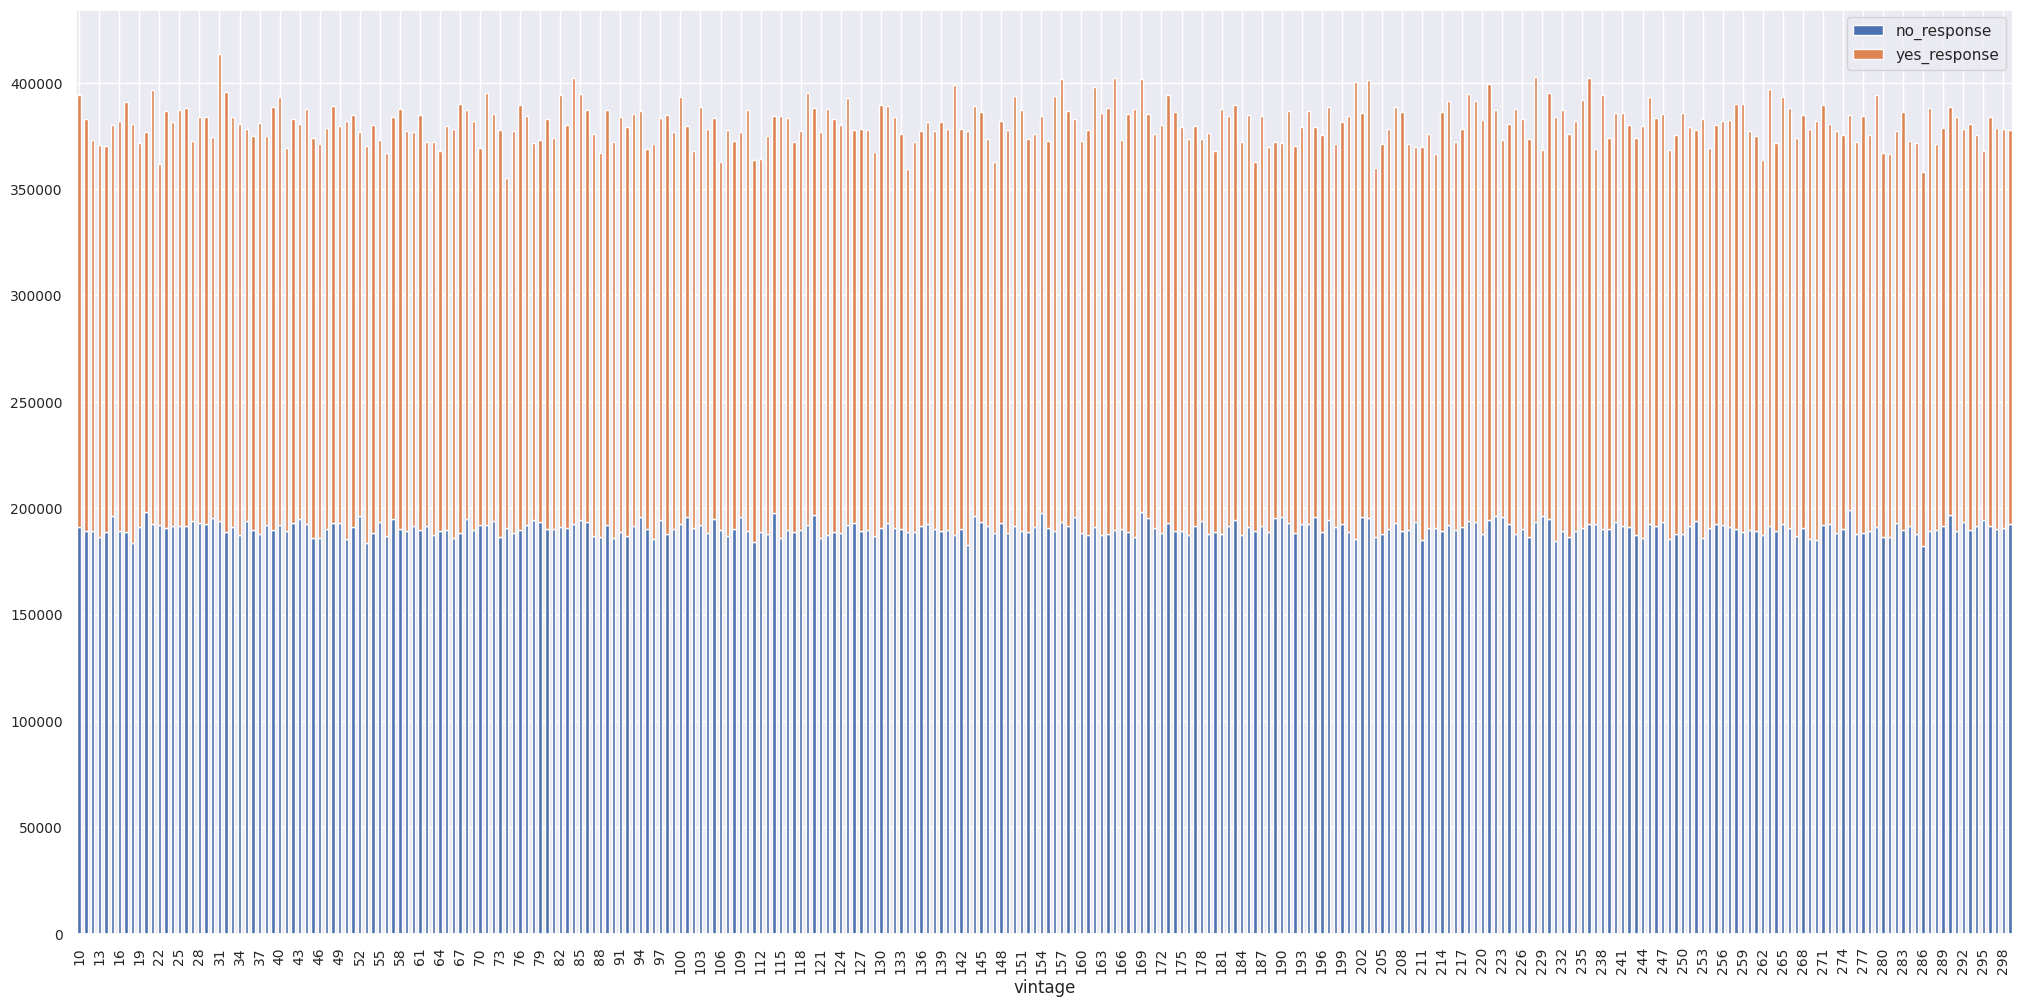

In [37]:
fig, ax = plt.subplots(figsize=(25, 12)) # Increased figure size
df.plot( x='vintage', kind='bar', stacked=True, ax=ax)

ax.tick_params(labelsize=10);
ax.tick_params(axis='x', rotation=90);

step = 3;  # troque pra 5, 10 etc conforme a quantidade de vintages
ticks = ax.get_xticks();
labels = [t.get_text() for t in ax.get_xticklabels()];
ax.set_xticks(ticks[::step]);
ax.set_xticklabels(labels[::step]);

## 4.2. Count Univariate Analysis

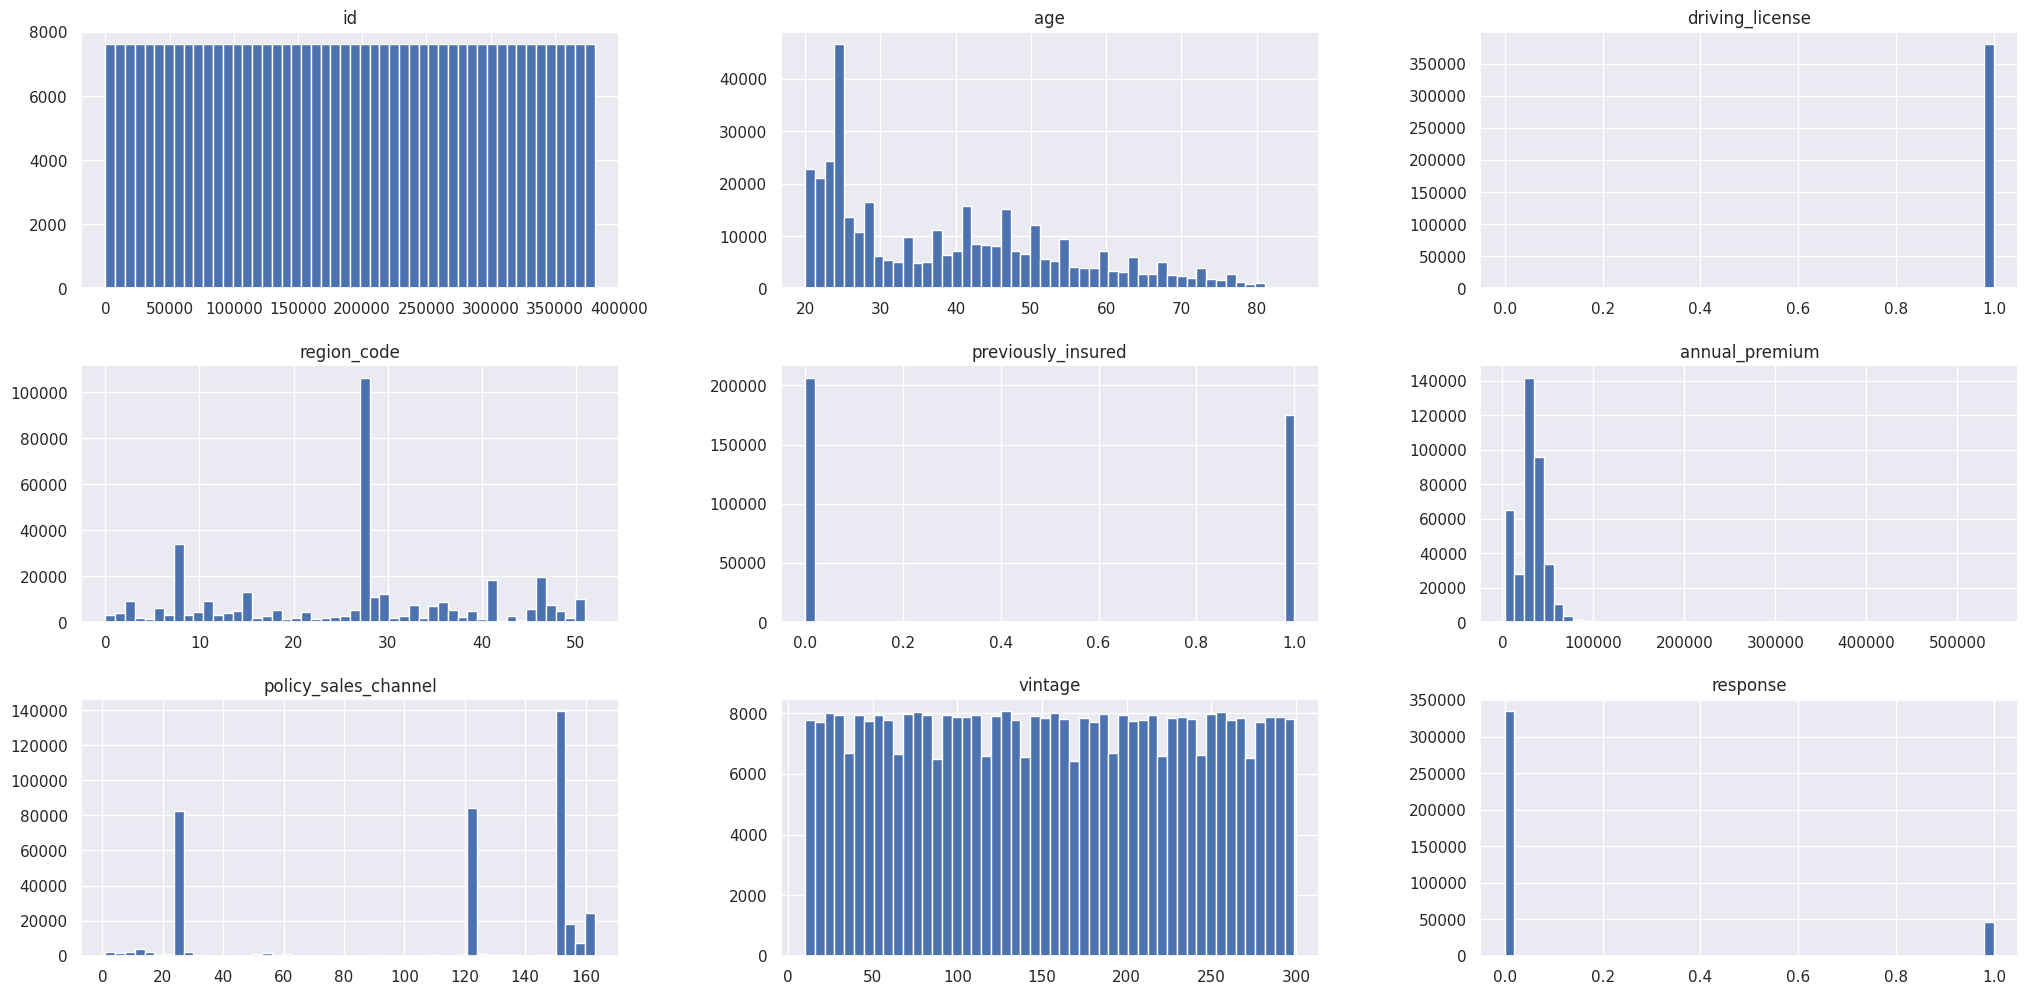

In [38]:
num_attributes.hist(bins = 50);

## 4.3. Multivariate Analysis

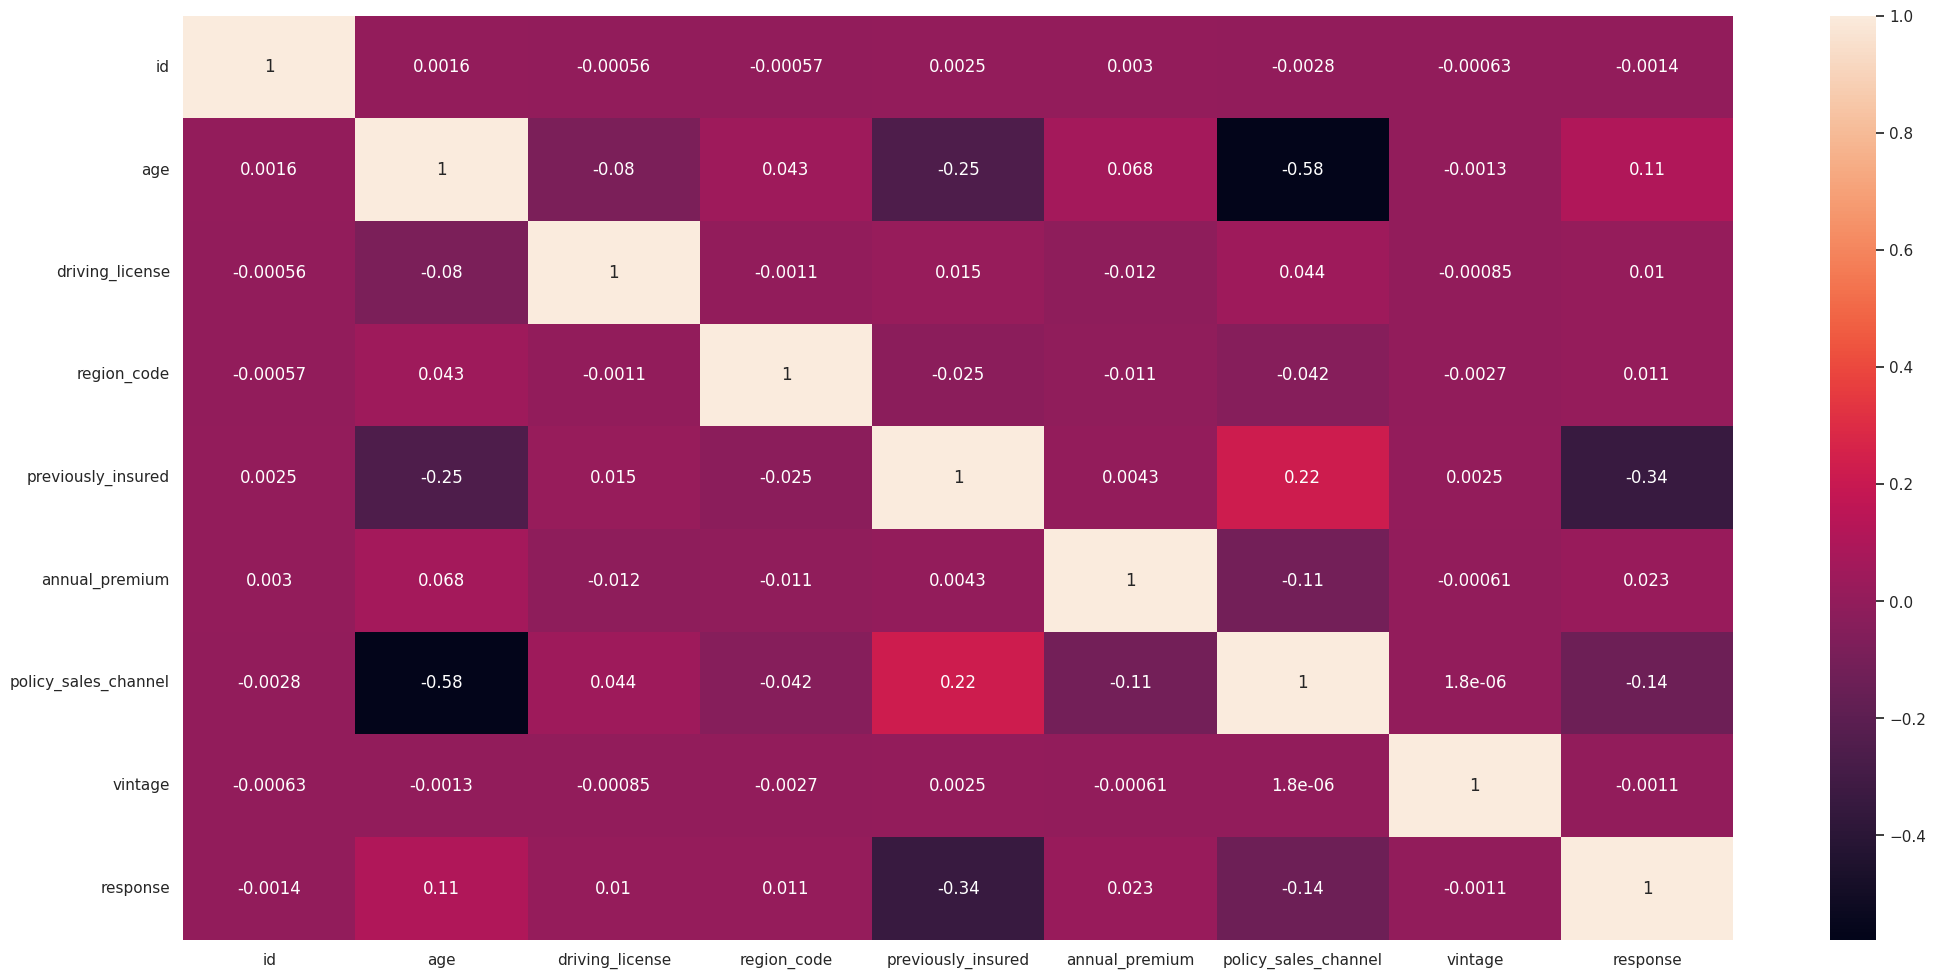

In [39]:
correlation = num_attributes.corr(method='pearson')
sns.heatmap( correlation, annot=True );

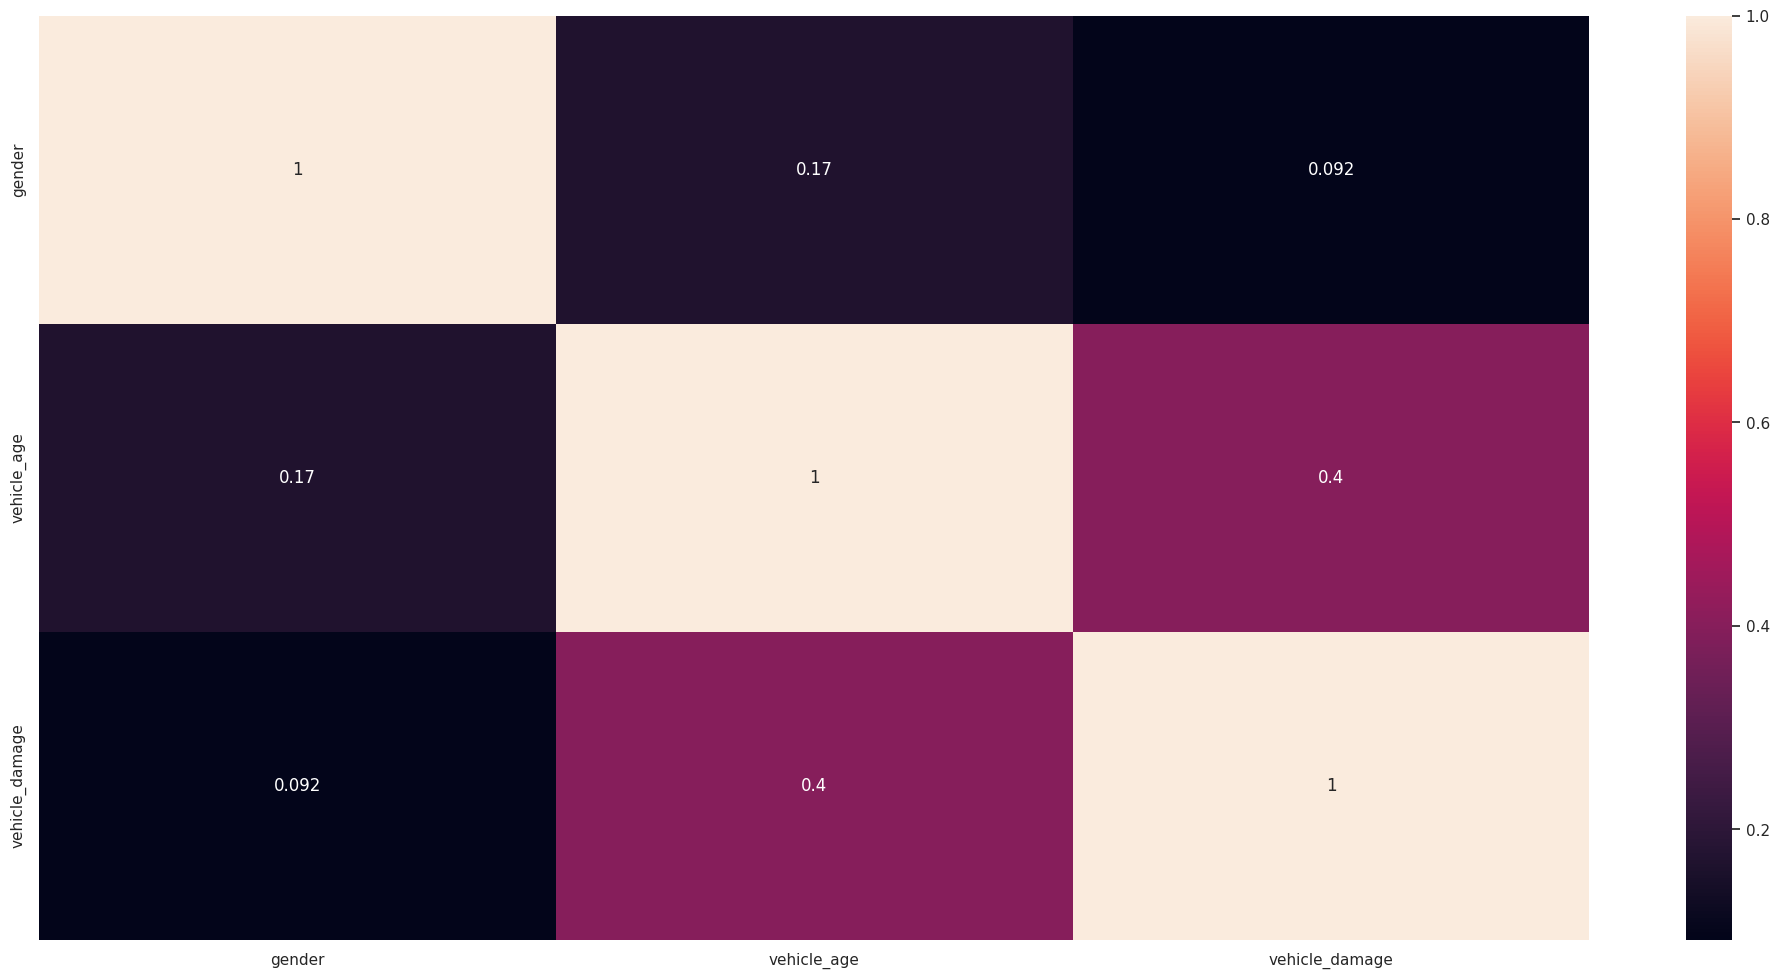

In [40]:
a1 = cramer_v(cat_attributes['gender'],cat_attributes['gender'])
a2 = cramer_v(cat_attributes['gender'],cat_attributes['vehicle_age'])
a3 = cramer_v(cat_attributes['gender'],cat_attributes['vehicle_damage'])

a4 = cramer_v(cat_attributes['vehicle_age'],cat_attributes['gender'])
a5 = cramer_v(cat_attributes['vehicle_age'],cat_attributes['vehicle_age'])
a6 = cramer_v(cat_attributes['vehicle_age'],cat_attributes['vehicle_damage'])

a7 = cramer_v(cat_attributes['vehicle_damage'],cat_attributes['gender'])
a8 = cramer_v(cat_attributes['vehicle_damage'],cat_attributes['vehicle_age'])
a9 = cramer_v(cat_attributes['vehicle_damage'],cat_attributes['vehicle_damage'])

#Dataset final
d = pd.DataFrame({'gender':[a1,a2,a3],
              'vehicle_age':[a4,a5,a6],
              'vehicle_damage':[a7,a8,a9]})

d = d.set_index(d.columns)
sns.heatmap(d,annot=True);

## 4.4. Perguntas de Negócio



1. Das pessoas interessadas no seguro, a maioria são homens
2. Pessoas mais velhas tem uma tendência maior de se interessarem pelo seguro
3. Das pessoas interessadas no seguro, a maioria tem licença para dirigir
4. Das pessoas interessadas no seguro, a maioria não tinha um seguro antes
5. Quanto mais velho o veículo, maior a chance da pessoa se interessar pelo seguro
6. Pessoas que sofreram batida de carro no passado, estão mais interessadas em adquirir o seguro
7. Quanto mais a pessoa paga de Anual Premium, maior a chance dela se interessar em ter um seguro
8. Quanto maior o tempo que a pessoa tem o seguro de vida, maior a chance dela se interessar pelo seguro





###4.4.1. Das pessoas interessadas no seguro, a maioria são homens

<b>VERDADEIRO</b> - 61.1% das pessoas que se interessam pelo seguro são homens

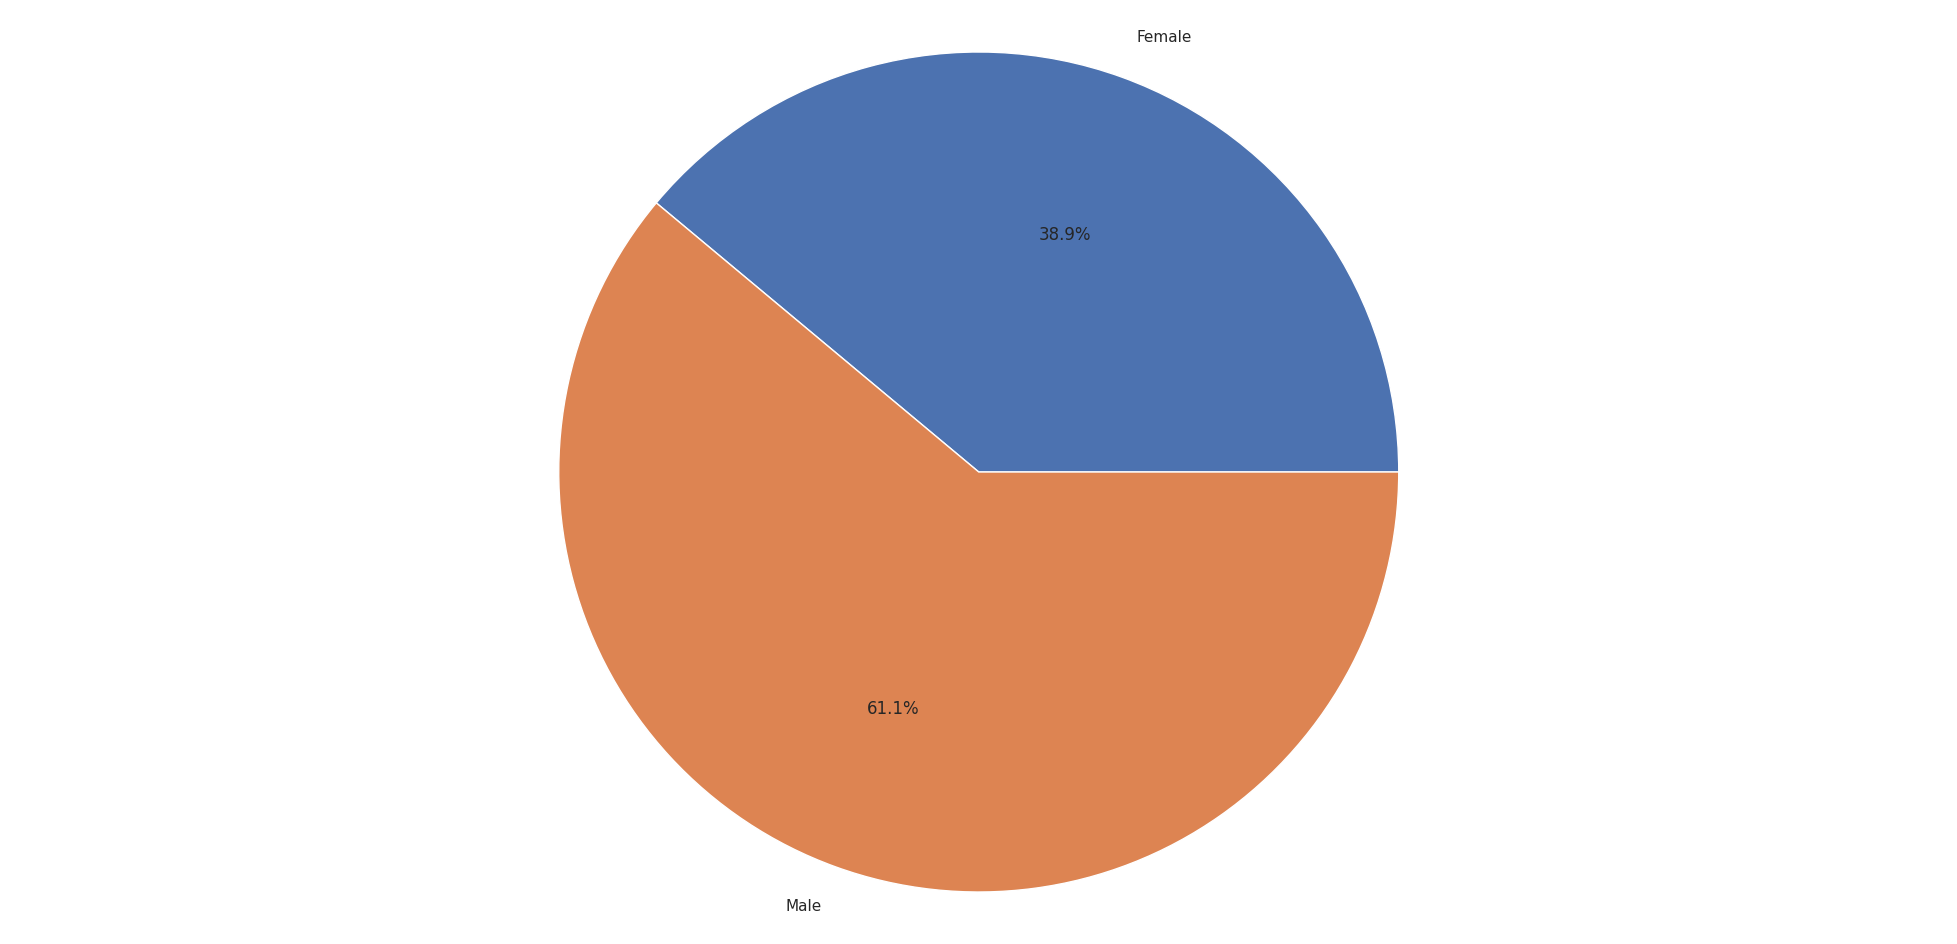

In [51]:
aux = df4.loc[(df4['response'] == 1),['gender','response']].groupby('gender').count().reset_index()

plt.pie(aux['response'], labels=aux['gender'], autopct='%1.1f%%')

plt.axis('equal')

plt.show()

###4.4.2. Pessoas mais velhas tem uma tendência maior de se interessarem pelo seguro
<b>FALSO</b> - Pessoas mais velhas tem umas tendência MENOR de se interessar pelo seguro

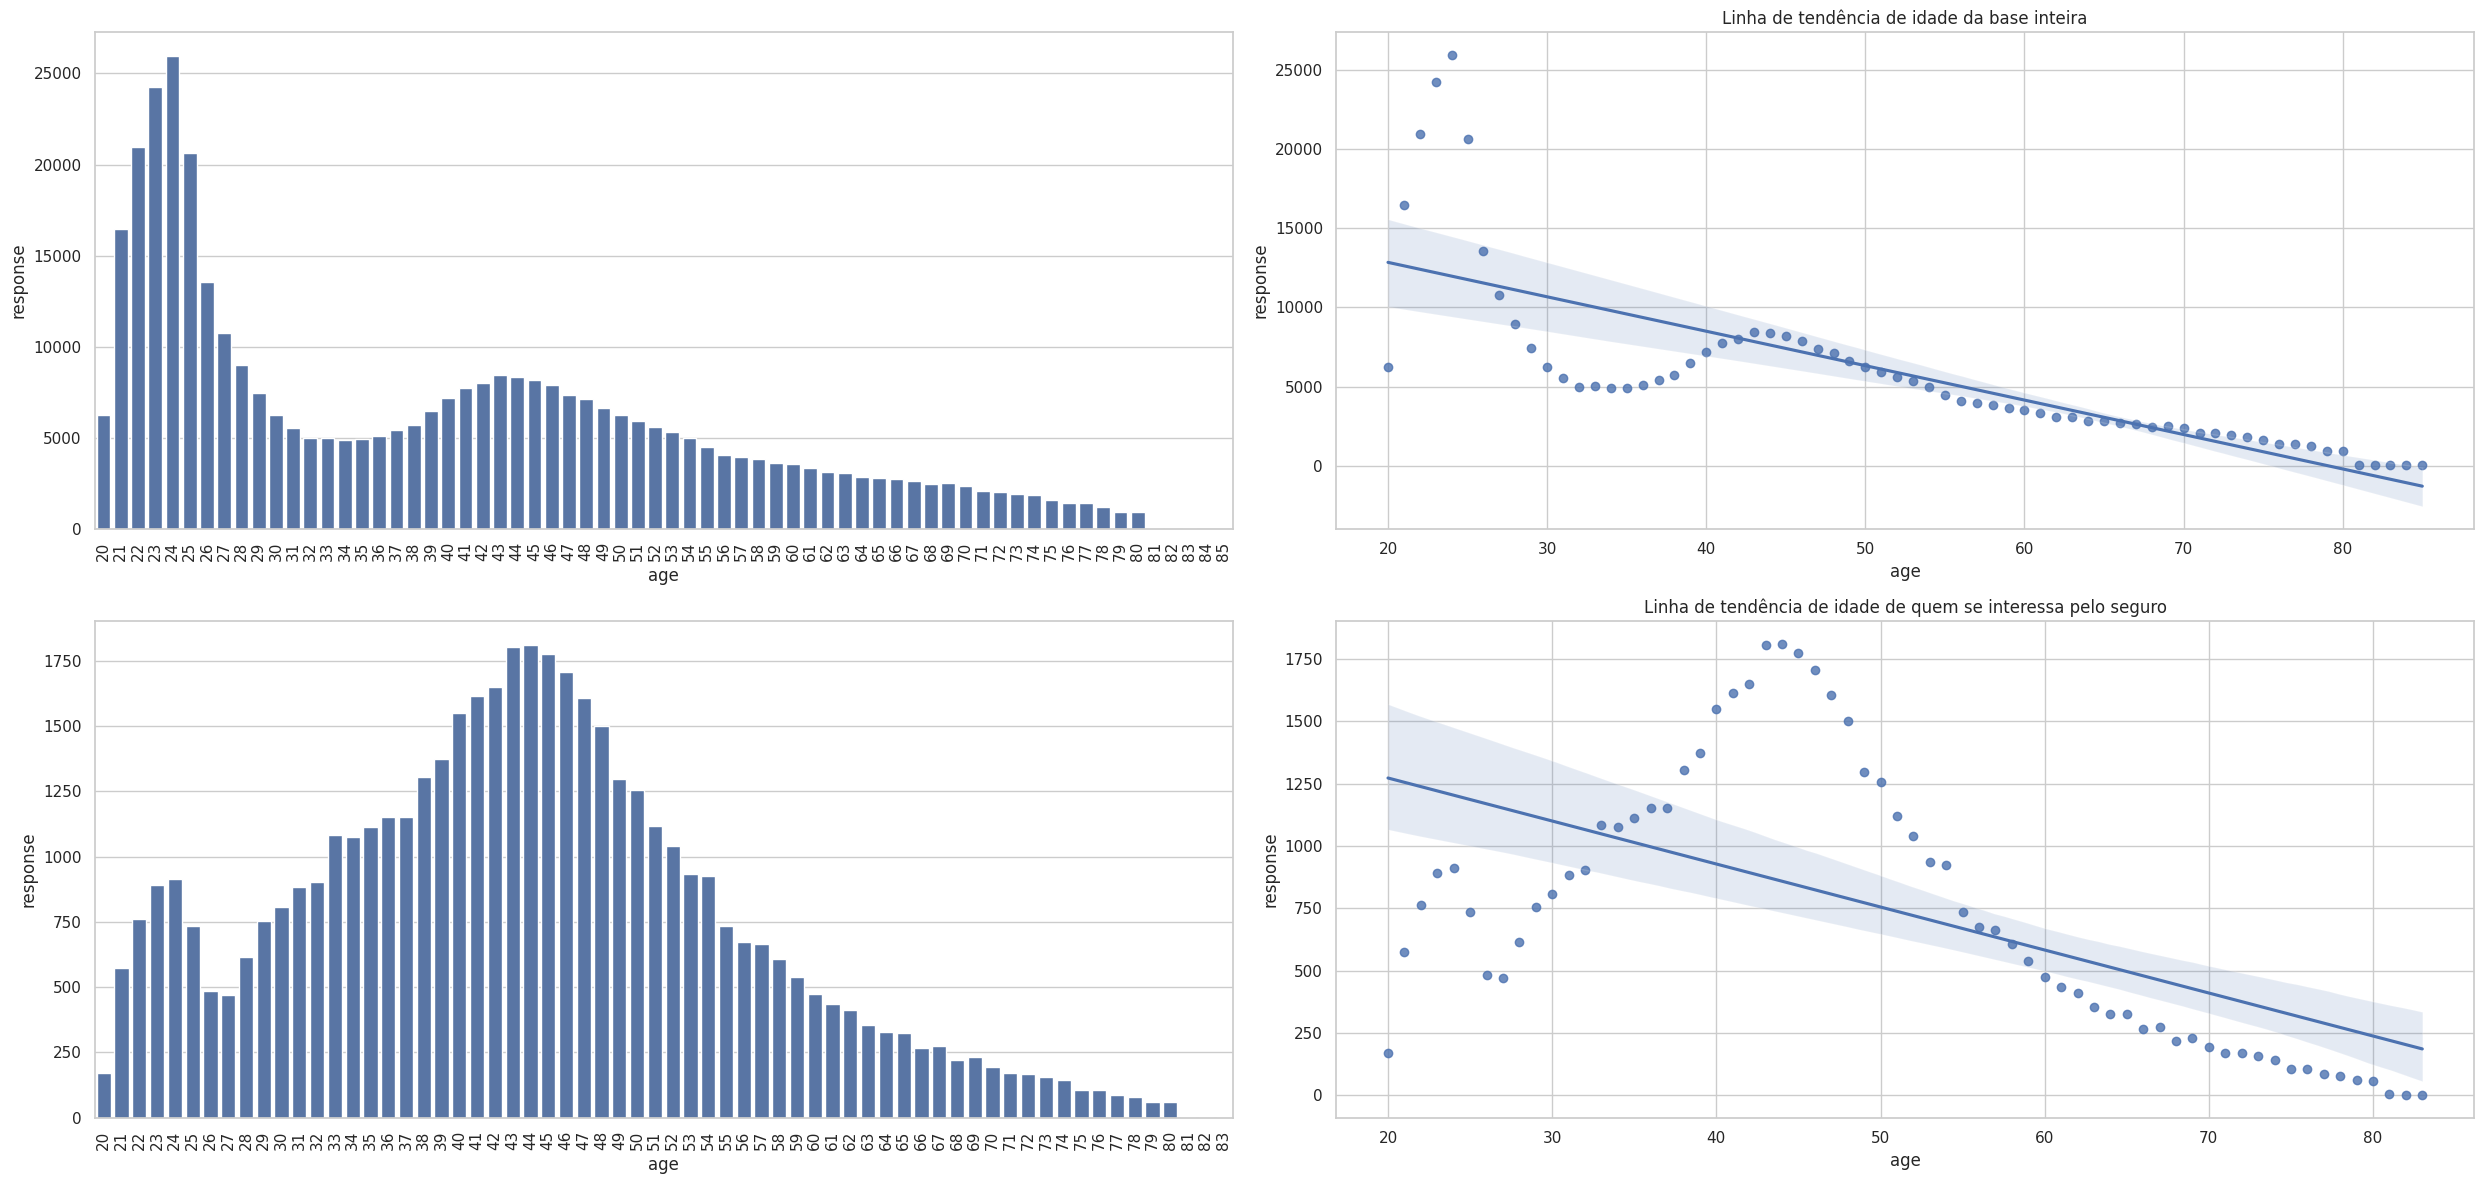

In [72]:
grid = GridSpec(2,2)

plt.subplot(grid[0,0])
aux = df4.loc[:,['age','response']].groupby('age').count().reset_index()
sns.barplot(y='response', x='age', data=aux);
plt.xticks(rotation=90);

plt.subplot(grid[0,1])
sns.regplot(y='response', x='age', data=aux);
plt.title('Linha de tendência de idade da base inteira');

plt.subplot(grid[1,0])
aux = df4.loc[(df4['response'] == 1),['age','response']].groupby('age').count().reset_index()
sns.barplot(y='response', x='age', data=aux);
plt.xticks(rotation=90);

plt.subplot(grid[1,1])
sns.regplot(y='response', x='age', data=aux);
plt.title('Linha de tendência de idade de quem se interessa pelo seguro');

plt.tight_layout()
plt.show()

###4.4.3. Das pessoas interessadas no seguro, a maioria tem licença para dirigir
<b>VERDADEIRO</b> - Pessoas que se interessam pelo seguro tem licença para dirigir em sua maioria

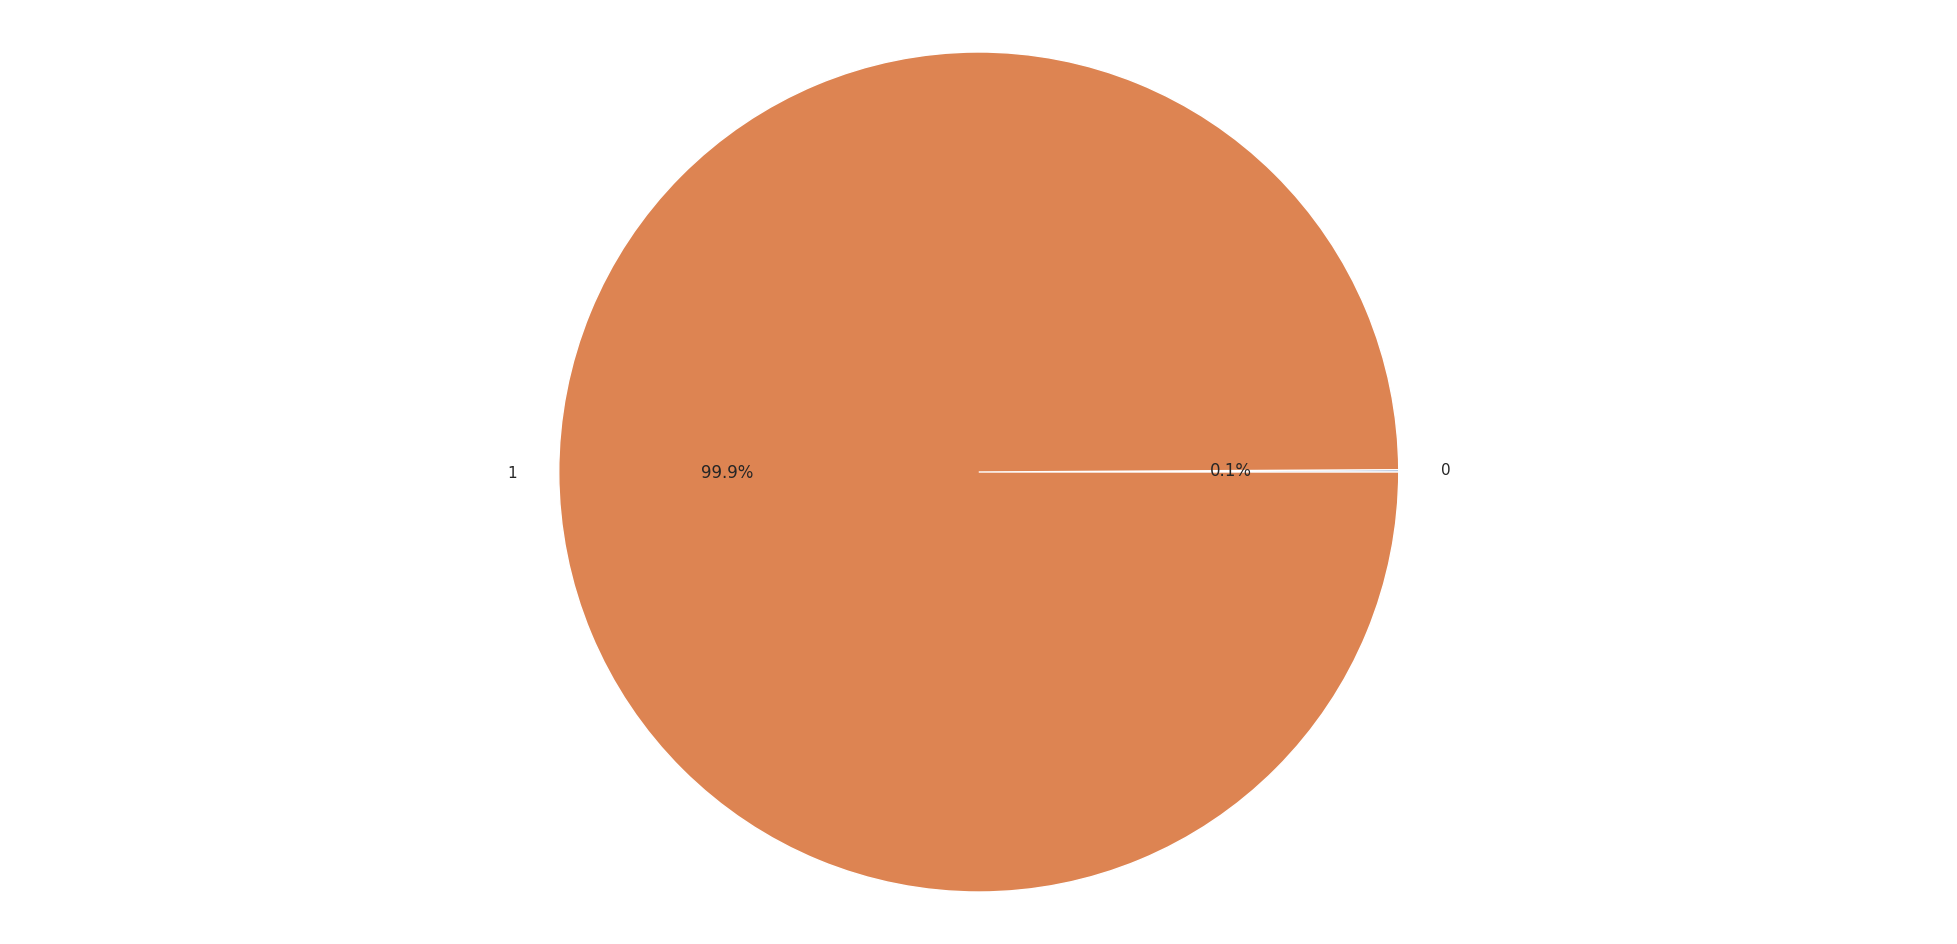

In [73]:
aux = df4.loc[(df4['response'] == 1),['driving_license','response']].groupby('driving_license').count().reset_index()

plt.pie(aux['response'], labels=aux['driving_license'], autopct='%1.1f%%')

plt.axis('equal')

plt.show()

###4.4.4. Das pessoas interessadas no seguro, a maioria não tinha um seguro antes
<b>VERDADEIRO</b> - Pessoas que se interessam pelo seguro, a maioria não tinha seguro antes

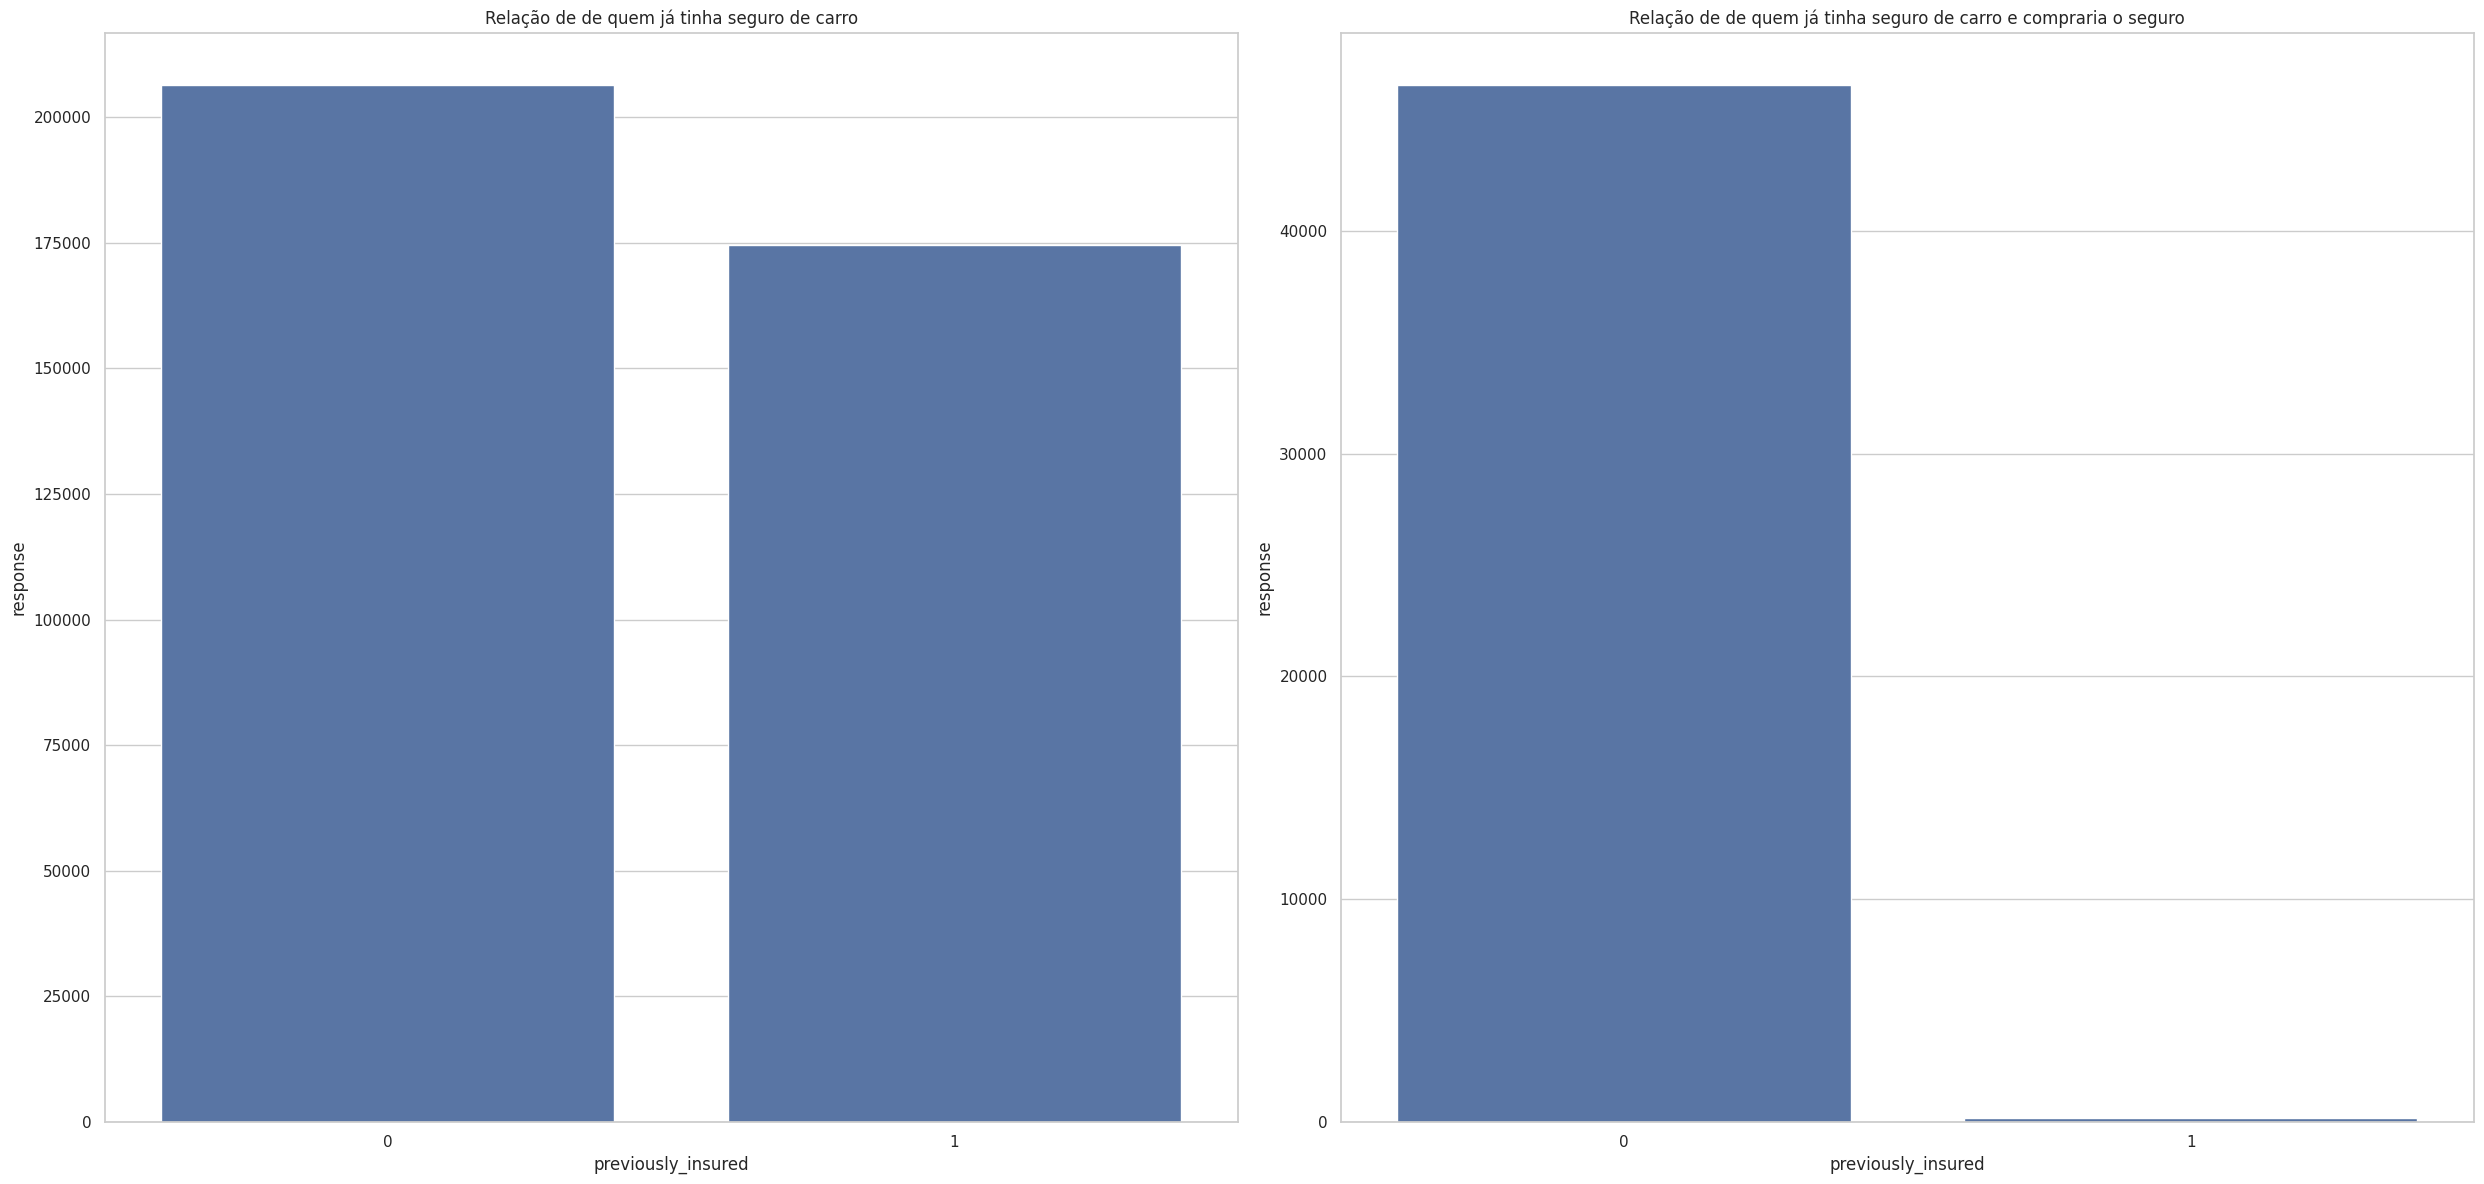

In [70]:
grid = GridSpec(1,2)

plt.subplot(grid[0,0])
aux_1 = df4.loc[:,['previously_insured','response']].groupby('previously_insured').count().reset_index()
sns.barplot(y='response',x='previously_insured',data=aux_1);
plt.title('Relação de de quem já tinha seguro de carro');

plt.subplot(grid[0,1])
aux_2 = df4.loc[(df4['response'] == 1),['previously_insured','response']].groupby('previously_insured').count().reset_index()
sns.barplot(y='response',x='previously_insured',data=aux_2);
plt.title('Relação de de quem já tinha seguro de carro e compraria o seguro');

plt.tight_layout()
plt.show()

###4.4.5. Quanto mais velho o veículo, maior a chance da pessoa se interessar pelo seguro
<b>VERDADEIRO</b> - A proproção de pessoas que se interessam pelo seguro é maior quando o veículo tem mais de 2 anos, portanto, quando mais velho o veículo, maior a chance da pessoa se interessar pelo seguro

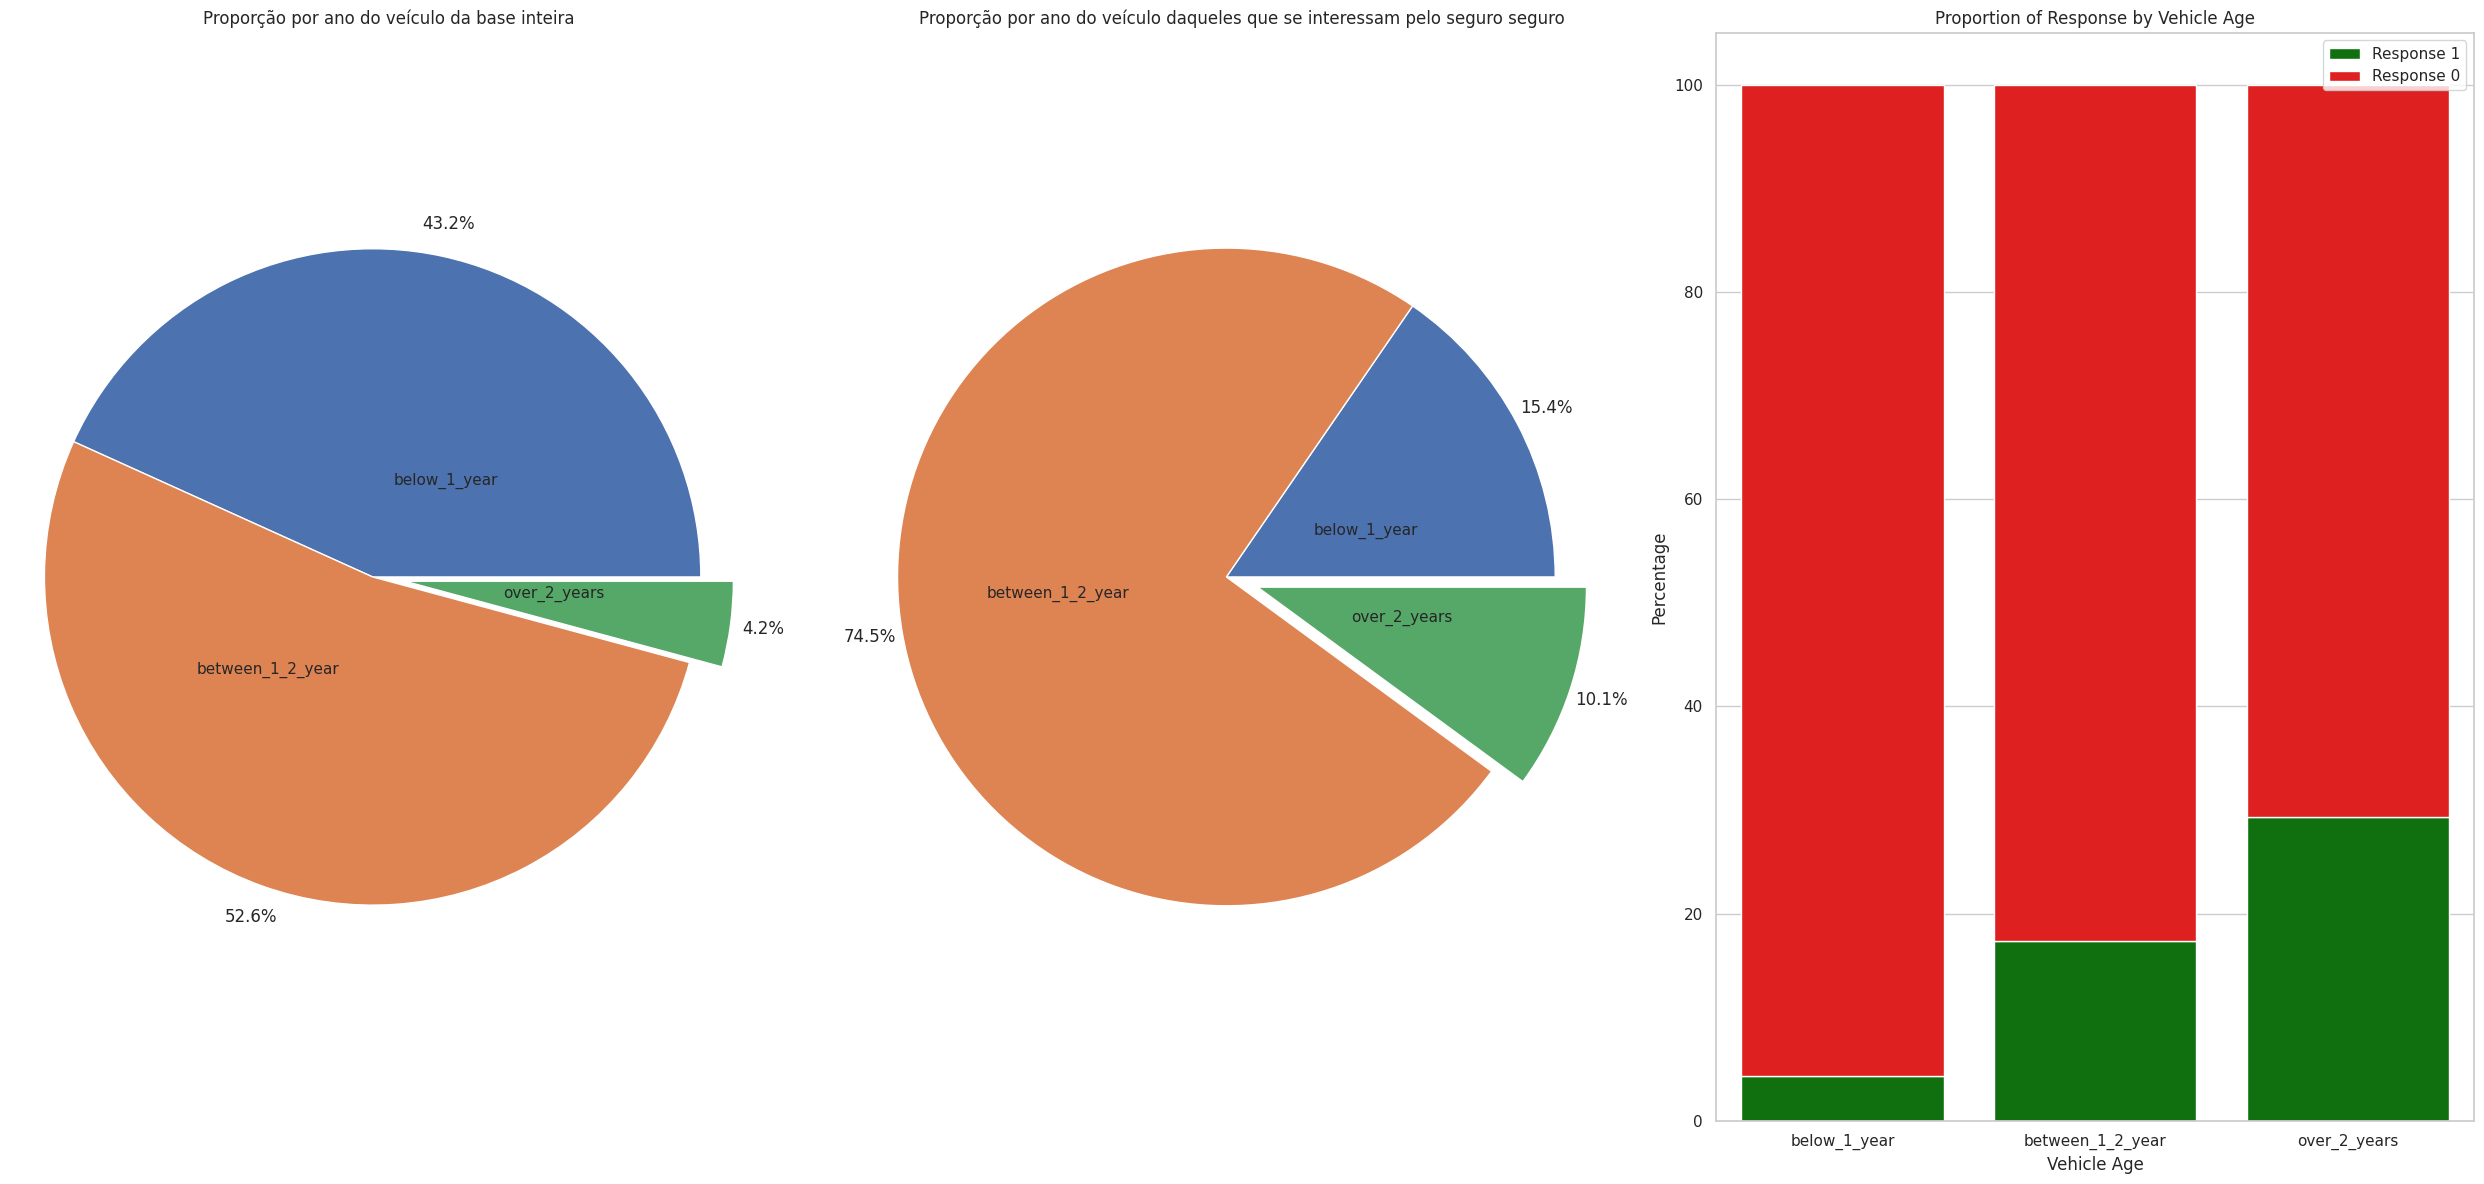

In [69]:
grid = GridSpec(1,3)

plt.subplot(grid[0,0])
aux_3 = df4.loc[:,['vehicle_age','response']].groupby('vehicle_age').count().reset_index()
explode = [0, 0, 0.1]
plt.pie(aux_3['response'], labels=aux_3['vehicle_age'], autopct='%1.1f%%', explode=explode,labeldistance=.3,pctdistance=1.1)
plt.axis('equal');
plt.title('Proporção por ano do veículo da base inteira');

plt.subplot(grid[0,1])
aux_4 = df4.loc[(df4['response'] == 1),['vehicle_age','response']].groupby('vehicle_age').count().reset_index()
plt.pie(aux_4['response'], labels=aux_4['vehicle_age'], autopct='%1.1f%%',explode=explode,labeldistance=.3,pctdistance=1.1);
plt.axis('equal');
plt.title('Proporção por ano do veículo daqueles que se interessam pelo seguro seguro');

plt.subplot(grid[0,2])
grouped_data = df4.groupby(['vehicle_age', 'response']).size().unstack()
grouped_data['total'] = grouped_data.sum(axis=1)
grouped_data['response_1_percentage'] = grouped_data[1] / grouped_data['total'] * 100
grouped_data['response_0_percentage'] = grouped_data[0] / grouped_data['total'] * 100
grouped_data = grouped_data.reset_index()


sns.set(style="whitegrid")

sns.barplot(x='vehicle_age', y='response_1_percentage', data=grouped_data, color='green', label='Response 1')
sns.barplot(x='vehicle_age', y='response_0_percentage', data=grouped_data, color='red', label='Response 0', bottom=grouped_data['response_1_percentage'])

plt.xlabel('Vehicle Age')
plt.ylabel('Percentage')
plt.title('Proportion of Response by Vehicle Age')
plt.legend();

plt.tight_layout()
plt.show()

###4.4.6. Pessoas que sofreram batida de carro no passado, estão mais interessadas em adquirir o seguro
<b>VERDADEIRO</b> - Das pessoas que se interessam pelo seguro de carro, em sua maioria, já sofreram danos no carro no passado

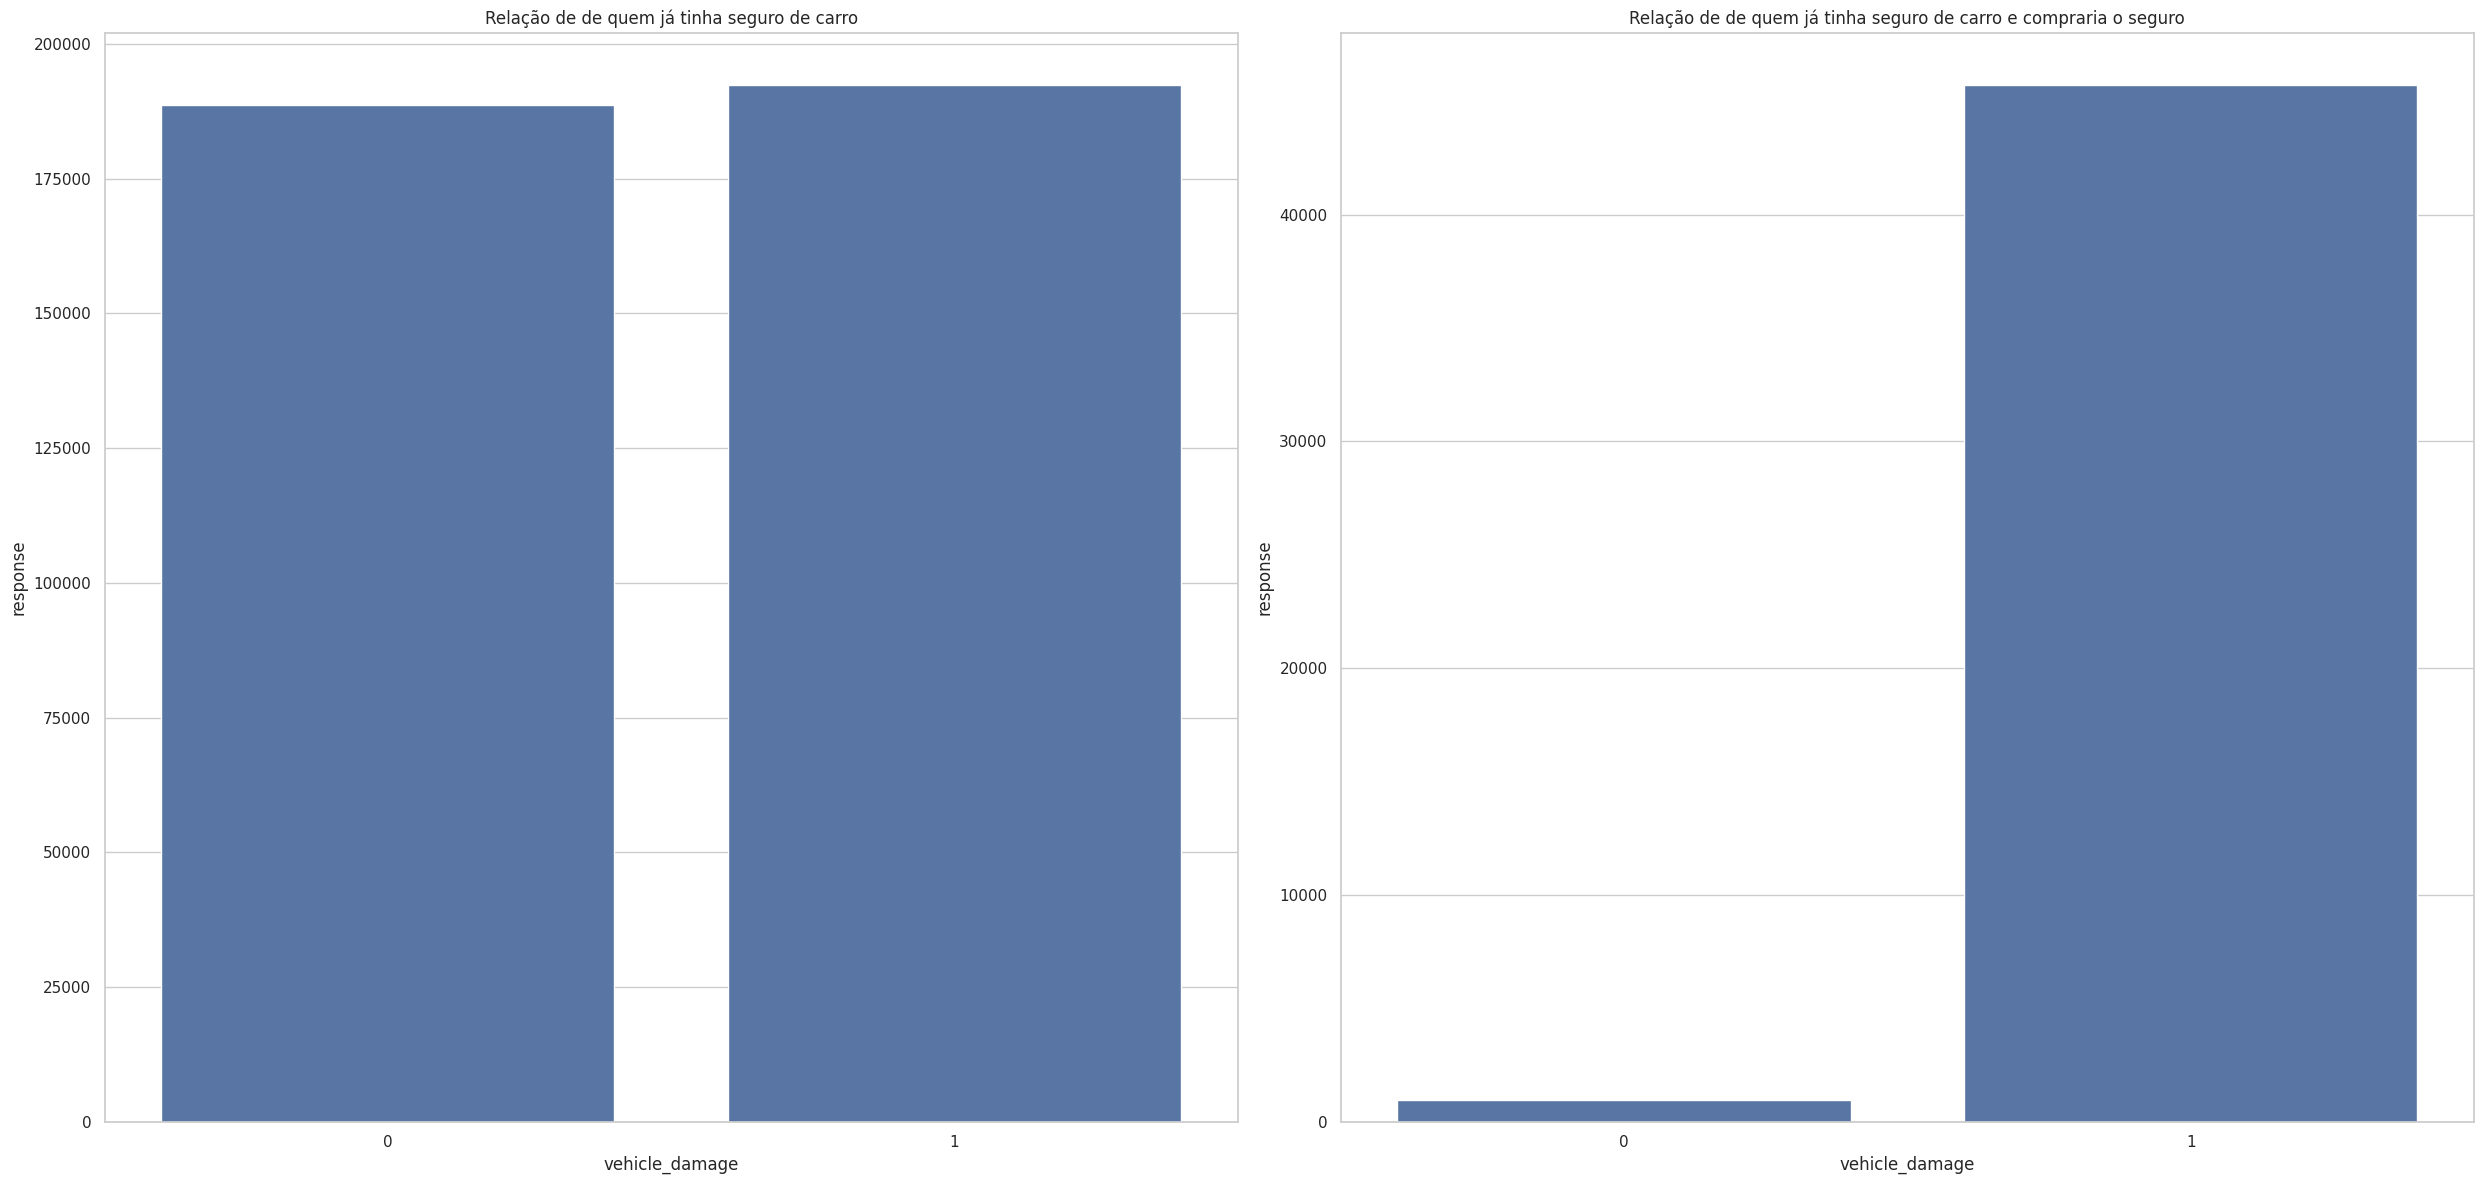

In [68]:
grid = GridSpec(1,2)

plt.subplot(grid[0,0])
aux_1 = df4.loc[:,['vehicle_damage','response']].groupby('vehicle_damage').count().reset_index()
sns.barplot(y='response',x='vehicle_damage',data=aux_1);
plt.title('Relação de de quem já tinha seguro de carro');

plt.subplot(grid[0,1])
aux_2 = df4.loc[(df4['response'] == 1),['vehicle_damage','response']].groupby('vehicle_damage').count().reset_index()
sns.barplot(y='response',x='vehicle_damage',data=aux_2);
plt.title('Relação de de quem já tinha seguro de carro e compraria o seguro');

plt.tight_layout()
plt.show()

###4.4.7. Quanto mais a pessoa paga de Anual Premium, maior a chance dela se interessar em ter um seguro
<b>FALSO</b> - Quanto mais a pessoa paga no Annual Premium, menos ela se interessa em adiquirir o seguro

/tmp/ipykernel_431/3753239870.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aux_4 = aux_3[['annual_premium_binned','response']].groupby('annual_premium_binned').sum().reset_index()
/tmp/ipykernel_431/3753239870.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aux_4 = aux_3[['annual_premium_binned','response']].groupby('annual_premium_binned').sum().reset_index()
/tmp/ipykernel_431/3753239870.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

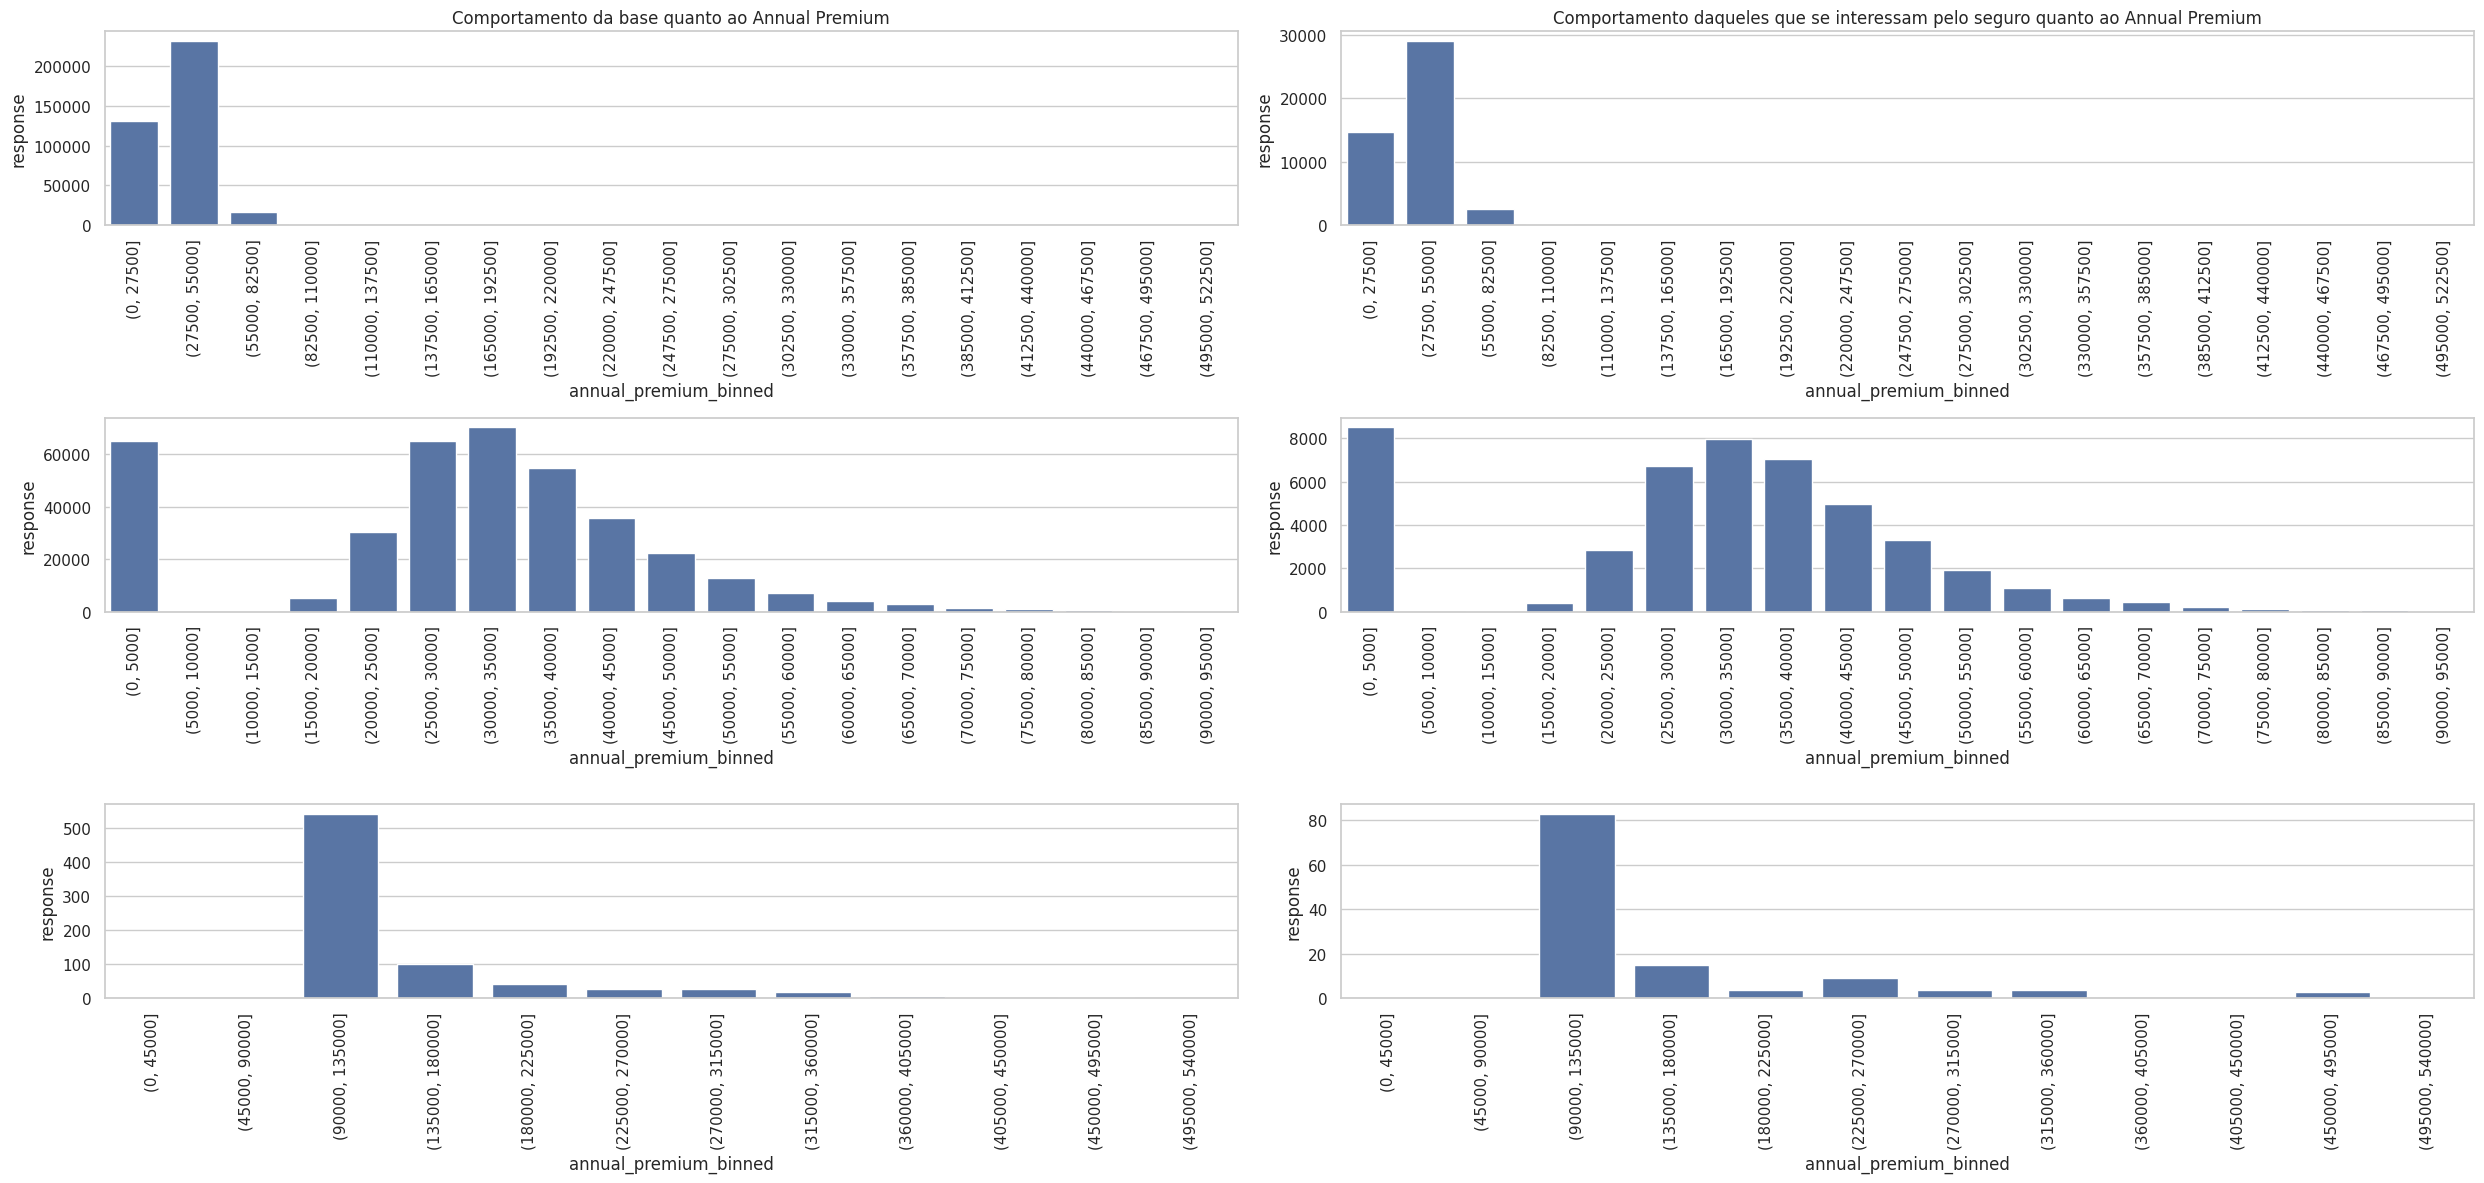

In [67]:
grid = GridSpec(3,2)

plt.subplot(grid[0,0])
bins2 = list(np.arange(0,550000,27500))
aux = df4.loc[:, :]
aux_3 = aux[['annual_premium','response']].groupby('annual_premium').count().reset_index()
aux_3['annual_premium_binned'] = pd.cut(aux_3['annual_premium'],bins=bins2)
aux_4 = aux_3[['annual_premium_binned','response']].groupby('annual_premium_binned').sum().reset_index()
sns.barplot(x='annual_premium_binned',y='response',data=aux_4);
plt.xticks(rotation=90);
plt.title('Comportamento da base quanto ao Annual Premium');

plt.subplot(grid[0,1])
aux = df4.loc[(df4['response'] == 1), :]
aux_3 = aux[['annual_premium','response']].groupby('annual_premium').count().reset_index()
aux_3['annual_premium_binned'] = pd.cut(aux_3['annual_premium'],bins=bins2)
aux_4 = aux_3[['annual_premium_binned','response']].groupby('annual_premium_binned').sum().reset_index()
sns.barplot(x='annual_premium_binned',y='response',data=aux_4);
plt.xticks(rotation=90);
plt.title('Comportamento daqueles que se interessam pelo seguro quanto ao Annual Premium');

plt.subplot(grid[1,0])
bins2 = list(np.arange(0,100000,5000))
aux = df4.loc[df4['annual_premium'] < 100000, :]
aux_3 = aux[['annual_premium','response']].groupby('annual_premium').count().reset_index()
aux_3['annual_premium_binned'] = pd.cut(aux_3['annual_premium'],bins=bins2)
aux_4 = aux_3[['annual_premium_binned','response']].groupby('annual_premium_binned').sum().reset_index()
sns.barplot(x='annual_premium_binned',y='response',data=aux_4);
plt.xticks(rotation=90);


plt.subplot(grid[1,1])
bins2 = list(np.arange(0,100000,5000))
aux = df4.loc[(df4['annual_premium'] < 100000) & (df4['response'] == 1), :]
aux_3 = aux[['annual_premium','response']].groupby('annual_premium').count().reset_index()
aux_3['annual_premium_binned'] = pd.cut(aux_3['annual_premium'],bins=bins2)
aux_4 = aux_3[['annual_premium_binned','response']].groupby('annual_premium_binned').sum().reset_index()
sns.barplot(x='annual_premium_binned',y='response',data=aux_4);
plt.xticks(rotation=90);


plt.subplot(grid[2,0])
bins2 = list(np.arange(0,550000,45000))
aux = df4.loc[(df4['annual_premium'] > 100000), :]
aux_3 = aux[['annual_premium','response']].groupby('annual_premium').count().reset_index()
aux_3['annual_premium_binned'] = pd.cut(aux_3['annual_premium'],bins=bins2)
aux_4 = aux_3[['annual_premium_binned','response']].groupby('annual_premium_binned').sum().reset_index()
sns.barplot(x='annual_premium_binned',y='response',data=aux_4);
plt.xticks(rotation=90);

plt.subplot(grid[2,1])
bins2 = list(np.arange(0,550000,45000))
aux = df4.loc[(df4['annual_premium'] > 100000) & (df4['response'] == 1), :]
aux_3 = aux[['annual_premium','response']].groupby('annual_premium').count().reset_index()
aux_3['annual_premium_binned'] = pd.cut(aux_3['annual_premium'],bins=bins2)
aux_4 = aux_3[['annual_premium_binned','response']].groupby('annual_premium_binned').sum().reset_index()
sns.barplot(x='annual_premium_binned',y='response',data=aux_4);
plt.xticks(rotation=90);

plt.tight_layout()
plt.show()

###4.4.8. Quanto maior o tempo que a pessoa tem o seguro de vida, maior a chance dela se interessar pelo seguro
<b>FALSO</b> - Depois de 15 dias, há uma tendência negativa, portanto, quanto maior o vintage, menor a chance da pessoa não se interessar pelo seguro de carro

/tmp/ipykernel_431/553200548.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aux_4 = aux_3[['vintage_binned','response']].groupby('vintage_binned').sum().reset_index()
/tmp/ipykernel_431/553200548.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aux_4_mean = aux_4.groupby('vintage_binned')['response'].mean().reset_index()
/tmp/ipykernel_431/553200548.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aux_4 = au

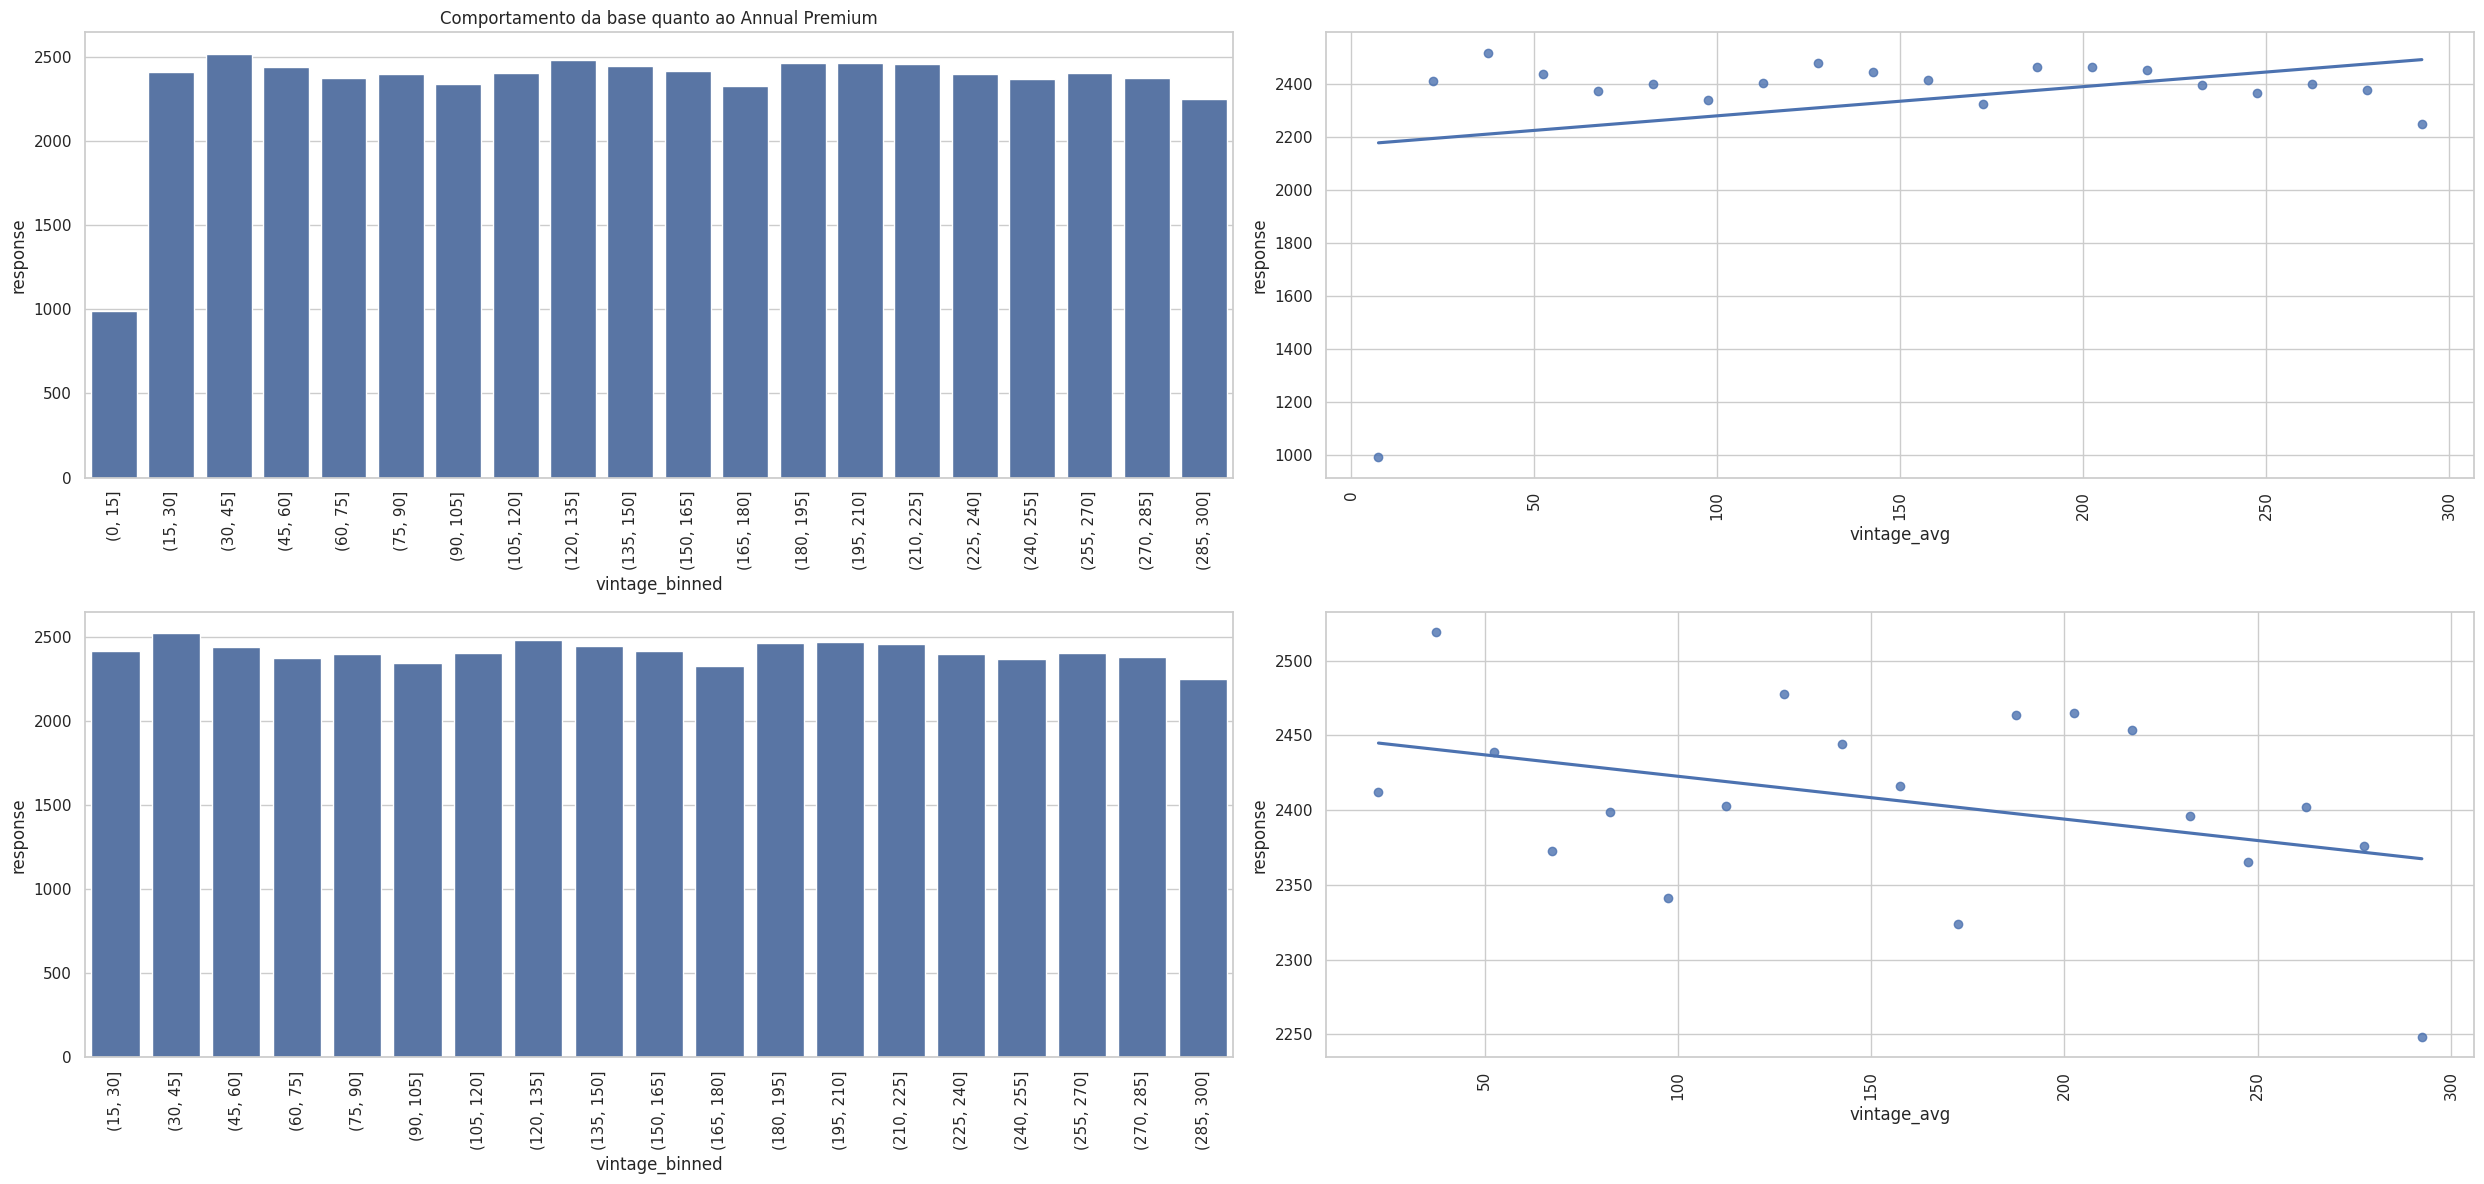

In [66]:
grid = GridSpec(2,2)

plt.subplot(grid[0,0])
bins2 = list(np.arange(0,301,15))
aux = df4.loc[(df4['response'] == 1), :]
aux_3 = aux[['vintage','response']].groupby('vintage').count().reset_index()
aux_3['vintage_binned'] = pd.cut(aux_3['vintage'],bins=bins2)
aux_4 = aux_3[['vintage_binned','response']].groupby('vintage_binned').sum().reset_index()
sns.barplot(x='vintage_binned',y='response',data=aux_4);
plt.xticks(rotation=90);
plt.title('Comportamento da base quanto ao Annual Premium');

plt.subplot(grid[0,1])
aux_4_mean = aux_4.groupby('vintage_binned')['response'].mean().reset_index()
aux_4_mean['vintage_avg'] = aux_4_mean['vintage_binned'].apply(lambda x: x.mid).astype(float)
sns.regplot(x='vintage_avg', y='response', data=aux_4_mean, ci=None);
plt.xticks(rotation=90);

plt.subplot(grid[1,0])
bins2 = list(np.arange(15,301,15))
aux = df4.loc[(df4['response'] == 1) & (df4['vintage'] > 15), :]
aux_3 = aux[['vintage','response']].groupby('vintage').count().reset_index()
aux_3['vintage_binned'] = pd.cut(aux_3['vintage'],bins=bins2)
aux_4 = aux_3[['vintage_binned','response']].groupby('vintage_binned').sum().reset_index()
sns.barplot(x='vintage_binned',y='response',data=aux_4);
plt.xticks(rotation=90);

plt.subplot(grid[1,1])
aux_4_mean = aux_4.groupby('vintage_binned')['response'].mean().reset_index()
aux_4_mean['vintage_avg'] = aux_4_mean['vintage_binned'].apply(lambda x: x.mid).astype(float)
sns.regplot(x='vintage_avg', y='response', data=aux_4_mean, ci=None);
plt.xticks(rotation=90);

plt.tight_layout()
plt.show()

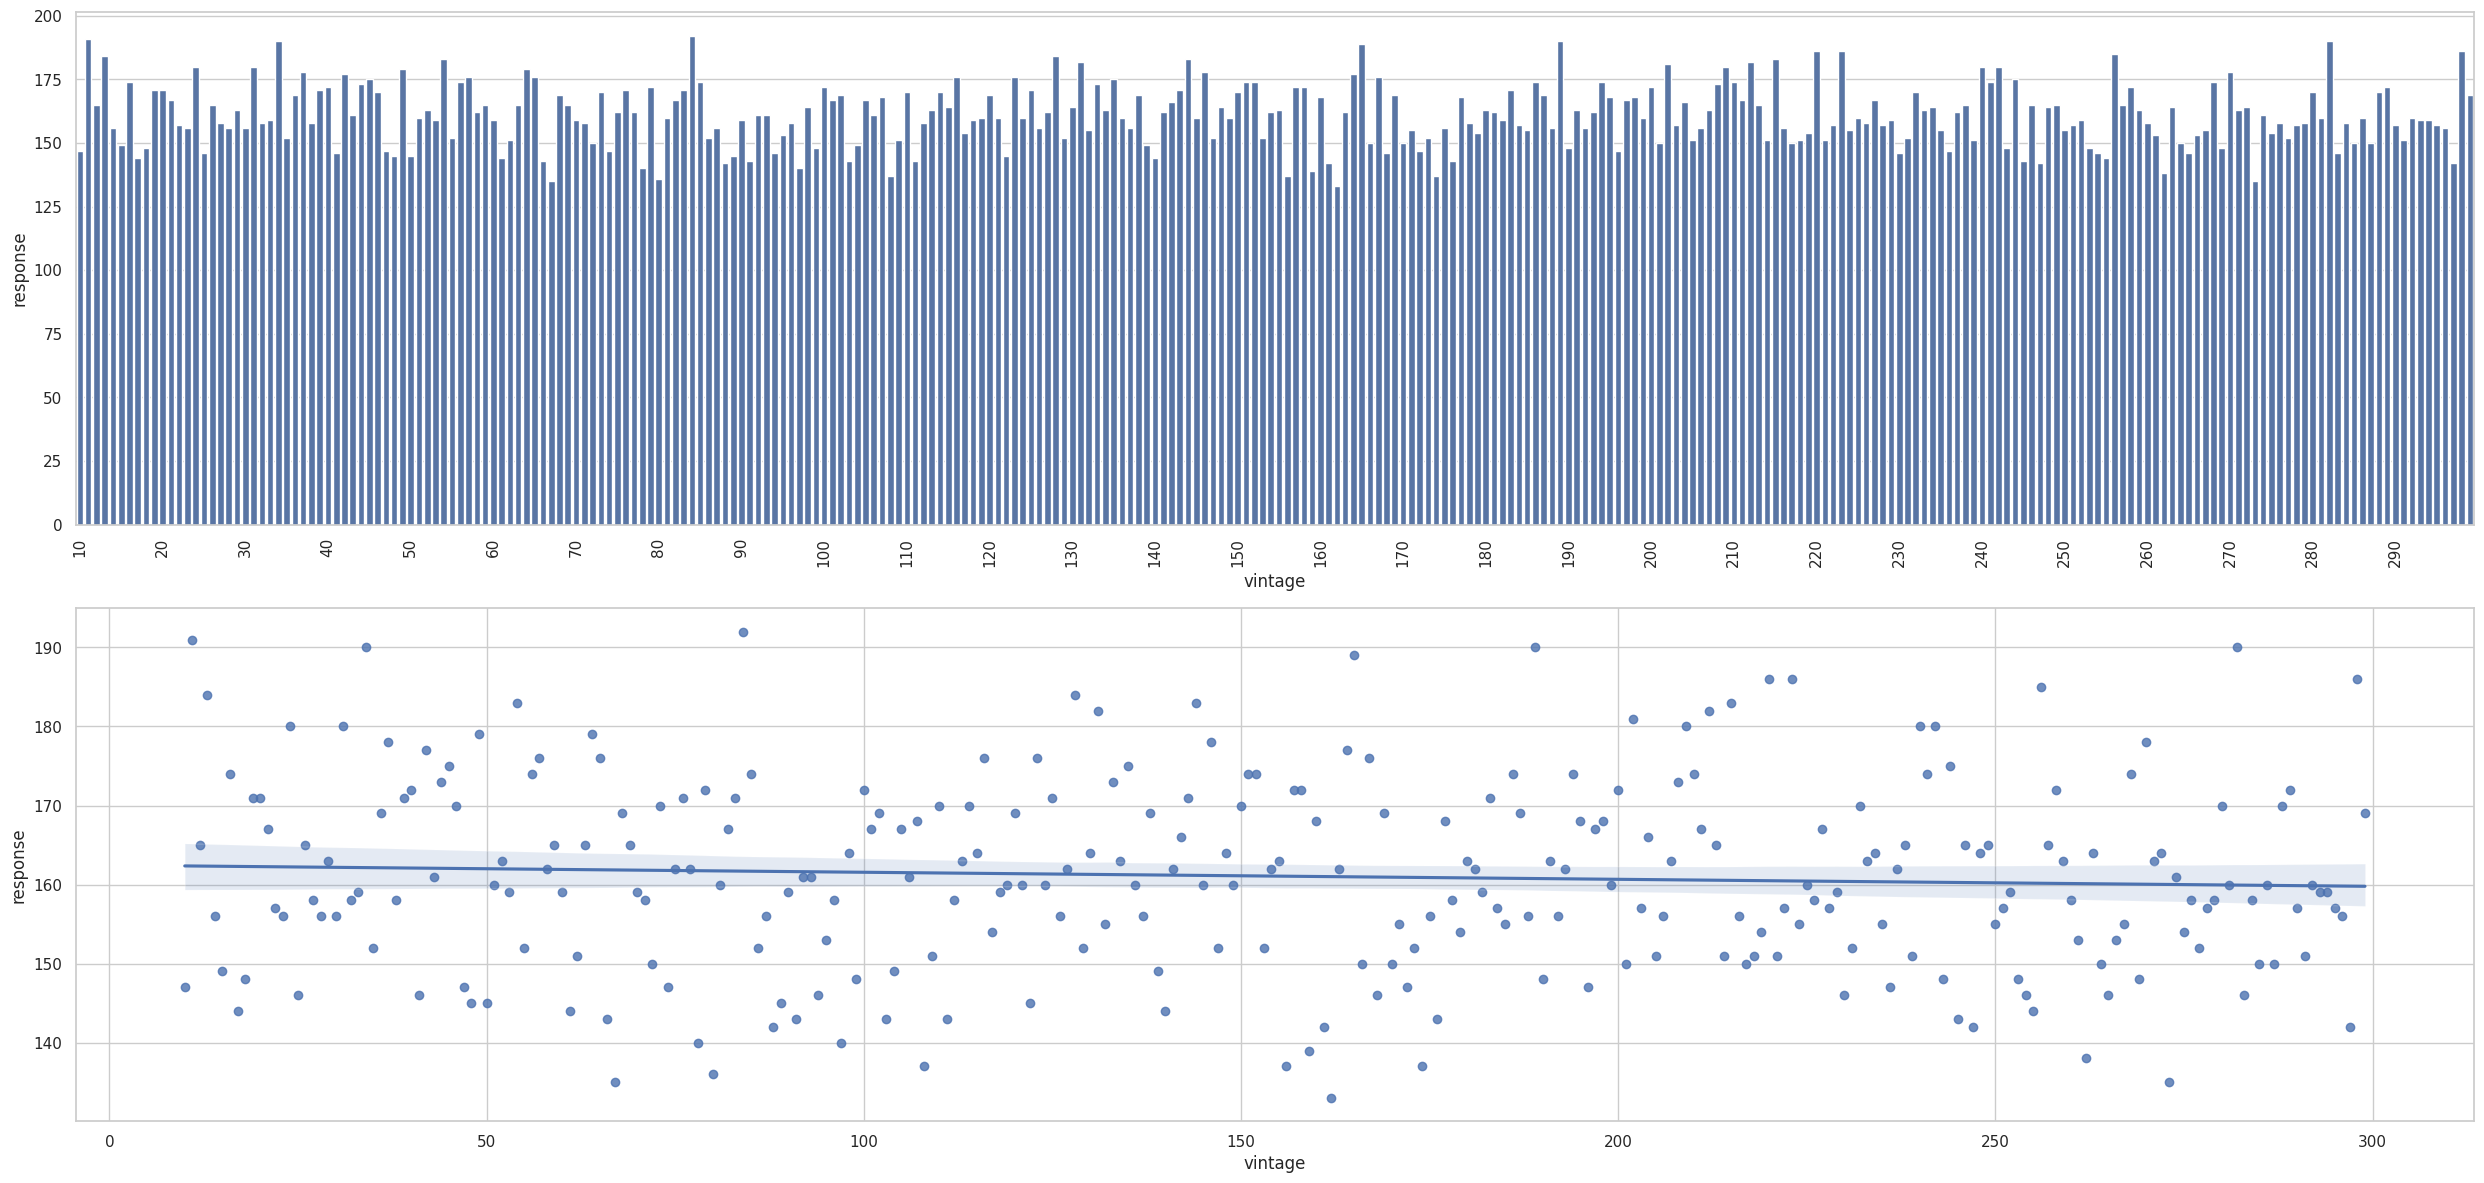

In [65]:
grid = GridSpec(2,1)

plt.subplot(grid[0,0])
aux = df4.loc[(df4['response'] == 1),['vintage','response']].groupby('vintage').count().reset_index()
sns.barplot(y='response', x='vintage', data=aux);
# Mostra o eixo x a cada 10 números
step = 10
ticks = range(0, len(aux), step)
plt.xticks(ticks=ticks, labels=aux['vintage'].iloc[ticks], rotation=90)

plt.subplot(grid[1,0])
sns.regplot(y='response', x='vintage', data=aux);

plt.tight_layout()
plt.show()

# 5.0. Data Preparation

In [ ]:
df5 = df4.copy()

In [ ]:
X = df4.drop( 'response', axis=1 )
y = df4['response'].copy()

x_train, x_validation, y_train, y_validation = ms.train_test_split( X, y, test_size=0.20 )

df5 = pd.concat( [x_train, y_train], axis=1 )

## 5.1. Standardization

In [ ]:
import os

# Create 'features' directory if it doesn't exist
if not os.path.exists('features'):
    os.makedirs('features')

In [ ]:
ss = pp.StandardScaler()

# anual premium - StandarScaler
df5['annual_premium'] = ss.fit_transform( df5[['annual_premium']].values )
pickle.dump( ss, open( 'features/annual_premium_scaler.pkl', 'wb' ) )

## 5.2. Rescaling

In [ ]:
mms_age = pp.MinMaxScaler()
mms_vintage = pp.MinMaxScaler()

# Age - MinMaxScaler
df5['age'] = mms_age.fit_transform( df5[['age']].values )
pickle.dump( mms_age, open( 'features/age_scaler.pkl', 'wb' ) )

# Vintage - MinMaxScaler
df5['vintage'] = mms_vintage.fit_transform( df5[['vintage']].values )
pickle.dump( mms_vintage, open( 'features/vintage_scaler.pkl', 'wb' ) )

## 5.3. Transformation

### 5.3.1. Encoding

In [ ]:
# gender - One Hot Encoding / Target Encoding
target_encode_gender = df5.groupby( 'gender' )['response'].mean()
df5.loc[:, 'gender'] = df5['gender'].map( target_encode_gender )
pickle.dump( target_encode_gender, open( 'features/target_encode_gender_scaler.pkl', 'wb' ) )

# region_code - Target Encoding / Frequency Encoding
target_encode_region_code = df5.groupby( 'region_code' )['response'].mean()
df5.loc[:, 'region_code'] = df5['region_code'].map( target_encode_region_code )
pickle.dump( target_encode_region_code, open( 'features/target_encode_region_code_scaler.pkl', 'wb' ) )

# vehicle_age - One Hot Encoding / Frequency Encoding
df5 = pd.get_dummies( df5, prefix='vehicle_age', columns=['vehicle_age'] )

# policy_sales_channel - Target Encoding / Frequency Encoding
fe_policy_sales_channel = df5.groupby( 'policy_sales_channel' ).size() / len( df5 )
df5.loc[:, 'policy_sales_channel'] = df5['policy_sales_channel'].map( fe_policy_sales_channel )
pickle.dump( fe_policy_sales_channel, open( 'features/fe_policy_sales_channel_scaler.pkl', 'wb' ) )

## 5.4. Validation Preparation

In [ ]:
# gender
x_validation.loc[:, 'gender'] =  x_validation.loc[:, 'gender'].map( target_encode_gender )

# age
x_validation.loc[:, 'age'] = mms_age.transform( x_validation[['age']].values )

# region_code
x_validation.loc[:, 'region_code'] = x_validation.loc[:, 'region_code'].map( target_encode_region_code )

# vehicle_age
x_validation = pd.get_dummies( x_validation, prefix='vehicle_age', columns=['vehicle_age'] )

# annual_premium
x_validation.loc[:, 'annual_premium'] = ss.transform( x_validation[['annual_premium']].values )

# policy_sales_channel
x_validation.loc[:, 'policy_sales_channel'] = x_validation['policy_sales_channel'].map( fe_policy_sales_channel )

# vintage
x_validation.loc[:, 'vintage'] = mms_vintage.transform( x_validation[['vintage']].values )

# fillna
x_validation = x_validation.fillna( 0 )

/tmp/ipykernel_5724/1030236340.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.49230769 0.09230769 0.06153846 ... 0.44615385 0.4        0.12307692]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_validation.loc[:, 'age'] = mms_age.transform( x_validation[['age']].values )
/tmp/ipykernel_5724/1030236340.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.39446367 0.5916955  0.14878893 ... 0.70934256 0.42560554 0.76816609]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_validation.loc[:, 'vintage'] = mms_vintage.transform( x_validation[['vintage']].values )
/tmp/ipykernel_5724/1030236340.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=F

# 6.0. Feature Selection

## 6.1. Boruta Algorithm

In [ ]:
x_train_n = df5.drop( ['id', 'response'], axis=1 ).values
y_train_n = y_train.values.ravel()

# Define model
et = en.RandomForestRegressor( n_jobs=-1 )

# Define boruta
boruta = bt.BorutaPy( et, n_estimators='auto', verbose=2, random_state=42 ).fit( x_train_n, y_train_n  )

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	9 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	10 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	11 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	12 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	13 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	14 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	15 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	16 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
I

In [ ]:
cols_selected = boruta.support_.tolist()

# best features
x_train_fs = df5.drop( ['id', 'response'], axis=1 )
cols_selected_boruta = x_train_fs.iloc[:, cols_selected].columns.to_list()

# not selected boruta
cols_not_selected_boruta = list( np.setdiff1d( x_train_fs.columns, cols_selected_boruta ) )

In [ ]:
cols_selected_boruta

['vehicle_damage']

## 6.2. Feature Importance

In [ ]:
# model definition
forest = en.ExtraTreesClassifier( n_estimators=250, random_state=0, n_jobs=-1 )

# data preparation
x_train_n = df5.drop( ['id', 'response'], axis=1 )
y_train_n = y_train.values
forest.fit( x_train_n, y_train_n )

ExtraTreesClassifier(n_estimators=250, n_jobs=-1, random_state=0)

Feature ranking:
                        feature  importance
0                       vintage    0.271084
0                annual_premium    0.243029
0                           age    0.167762
0                   region_code    0.106848
0                vehicle_damage    0.068642
0          policy_sales_channel    0.059361
0            previously_insured    0.055372
0      vehicle_age_below_1_year    0.014373
0  vehicle_age_between_1_2_year    0.006226
0                        gender    0.004695
0      vehicle_age_over_2_years    0.002117
0               driving_license    0.000491


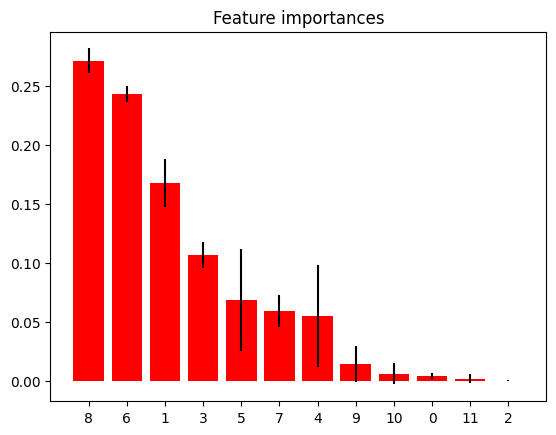

In [ ]:
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")
df = pd.DataFrame()
for i, j in zip( x_train_n, forest.feature_importances_ ):
    aux = pd.DataFrame( {'feature': i, 'importance': j}, index=[0] )
    df = pd.concat( [df, aux], axis=0 )

print( df.sort_values( 'importance', ascending=False ) )

# Plot the impurity-based feature importances of the forest
plt.figure()
plt.title("Feature importances")
plt.bar(range(x_train_n.shape[1]), importances[indices], color="r", yerr=std[indices], align="center")
plt.xticks(range(x_train_n.shape[1]), indices)
plt.xlim([-1, x_train_n.shape[1]])
plt.show()

# 7.0. Machine Learning Modelling

In [ ]:
cols_selected = ['annual_premium', 'vintage', 'age', 'region_code', 'vehicle_damage', 'previously_insured', 'policy_sales_channel']

In [ ]:
x_train = df5[ cols_selected ]

x_val = x_validation[ cols_selected ]
y_val = y_validation

## 7.1. KNN Classifier

In [ ]:
# model definition
knn_model = nh.KNeighborsClassifier( n_neighbors=7 )

# model training
knn_model.fit( x_train, y_train )

# model prediction
yhat_knn = knn_model.predict_proba( x_val )

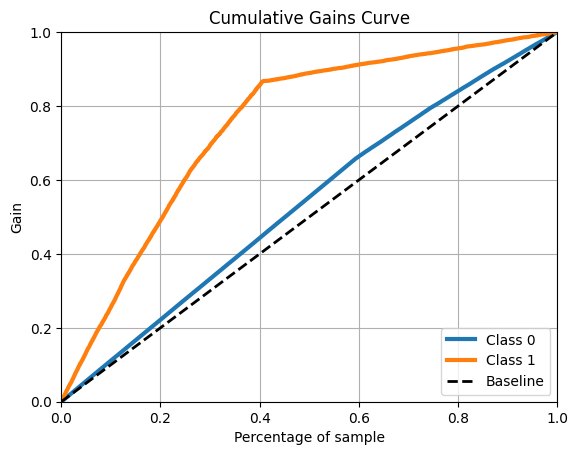

In [ ]:
# Accumulative Gain
skplt.metrics.plot_cumulative_gain( y_val, yhat_knn );

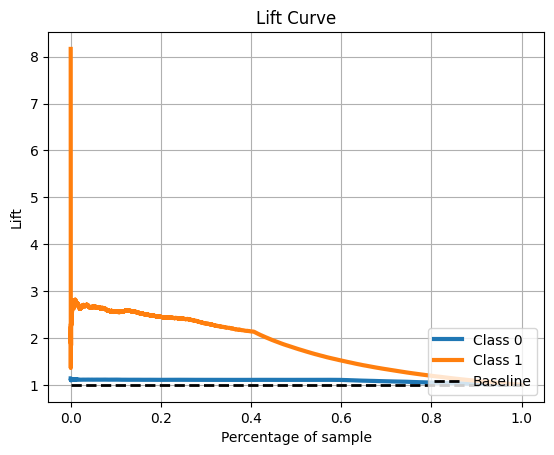

In [ ]:
#Scikitplot library is there to help
skplt.metrics.plot_lift_curve( y_val, yhat_knn );

In [ ]:
df_knn = cross_validation(knn_model,x_train,y_train,5,Verbose=True)
df_knn

Fold Number 1/5
Fold Number 2/5
Fold Number 3/5
Fold Number 4/5
Fold Number 5/5


,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
0,KNeighborsClassifier,0.5494 +/- 0.0014,0.2746 +/- 0.0028,0.7348 +/- 0.0075,0.7826 +/- 0.0033,0.8609 +/- 0.0007


## 7.2. Logistic Regression

In [ ]:
# model definition
lr_model = lm.LogisticRegression( random_state=42 )

# model training
lr_model.fit( x_train, y_train )

# model prediction
yhat_lr = lr_model.predict_proba( x_val )

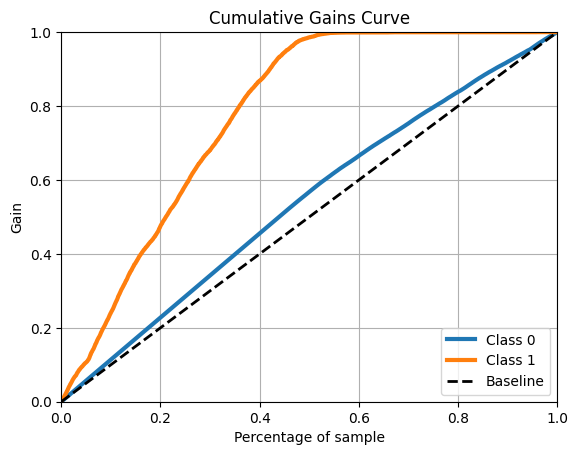

In [ ]:
# Accumulative Gain
skplt.metrics.plot_cumulative_gain( y_val, yhat_lr );

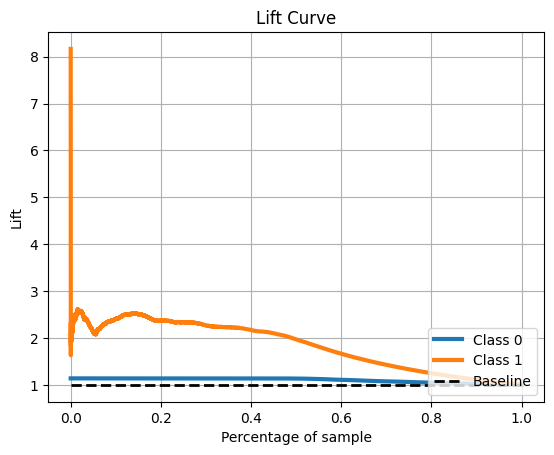

In [ ]:
#Scikitplot library is there to help
skplt.metrics.plot_lift_curve( y_val, yhat_lr );

In [ ]:
df_lr = cross_validation(lr_model,x_train,y_train,5,Verbose=True)
df_lr

Fold Number 1/5
Fold Number 2/5
Fold Number 3/5
Fold Number 4/5
Fold Number 5/5


,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
0,LogisticRegression,0.5 +/- 0.0,0.2766 +/- 0.0025,0.74 +/- 0.0066,0.8178 +/- 0.0026,0.8774 +/- 0.0


## 7.3. Extra Trees Classifier



In [ ]:
# model definition
et_model = en.ExtraTreesClassifier( n_estimators=250, n_jobs=-1, random_state=42 )

# model training
et_model.fit( x_train, y_train )

# model prediction
yhat_et = et_model.predict_proba( x_val )

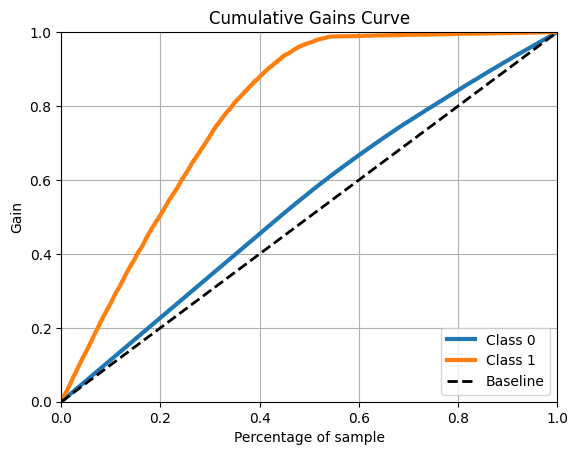

In [ ]:
# Accumulative Gain
skplt.metrics.plot_cumulative_gain( y_val, yhat_et );

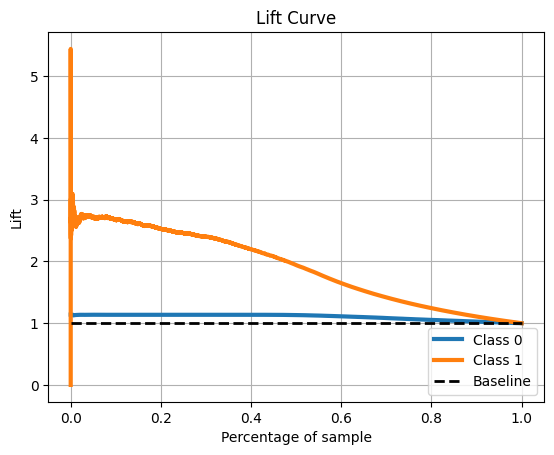

In [ ]:
#Scikitplot library is there to help
skplt.metrics.plot_lift_curve( y_val, yhat_et );

In [ ]:
df_et = cross_validation(et_model, x_train,y_train, 5, Verbose=True)
df_et

Fold Number 1/5
Fold Number 2/5
Fold Number 3/5
Fold Number 4/5
Fold Number 5/5


,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
0,ExtraTreesClassifier,0.5528 +/- 0.0016,0.2891 +/- 0.0013,0.7736 +/- 0.0036,0.8267 +/- 0.0016,0.8605 +/- 0.0009


## 7.4. Random Forest

In [ ]:
# model definition
rf_model = en.RandomForestClassifier( n_estimators=100, n_jobs=-1, random_state=42 )

# model training
rf_model.fit( x_train, y_train )

# model prediction
yhat_rf = rf_model.predict_proba( x_val )

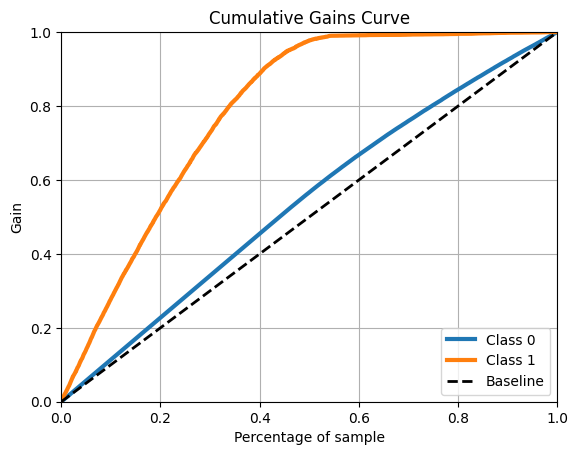

In [ ]:
# Accumulative Gain
skplt.metrics.plot_cumulative_gain( y_val, yhat_rf );

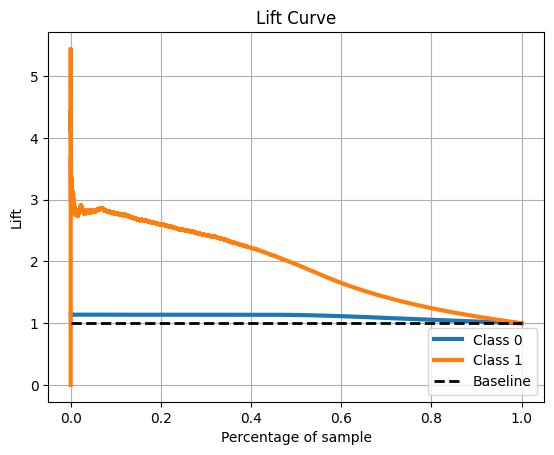

In [ ]:
#Scikitplot library is there to help
skplt.metrics.plot_lift_curve( y_val, yhat_rf );

In [ ]:
df_rf = cross_validation(rf_model,x_train,y_train,5,Verbose=True)
df_rf

Fold Number 1/5
Fold Number 2/5
Fold Number 3/5
Fold Number 4/5
Fold Number 5/5


,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
0,RandomForestClassifier,0.5447 +/- 0.0019,0.2928 +/- 0.0012,0.7833 +/- 0.0032,0.8318 +/- 0.0016,0.8648 +/- 0.0007


##7.5 - XGBoost

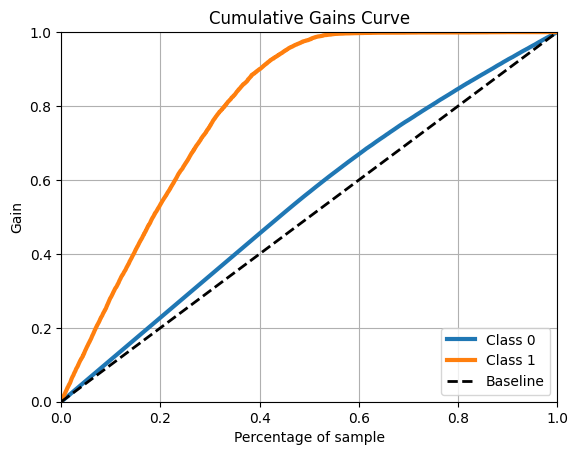

In [ ]:
# model definition
xgb_model = xgb.XGBClassifier(n_estimators=1000, n_jobs=-1,random_state=42)  # Você pode ajustar o número de estimadores conforme necessário

# model training
xgb_model.fit(x_train, y_train)

# model prediction
yhat_xgb = xgb_model.predict_proba(x_val)

#Acumilative Gain
skplt.metrics.plot_cumulative_gain(y_validation,yhat_xgb);

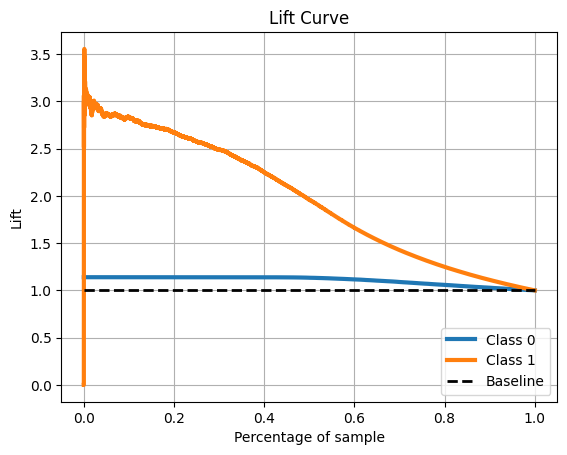

In [ ]:
skplt.metrics.plot_lift_curve(y_validation,yhat_xgb);

In [ ]:
df_xgb = cross_validation(xgb_model,x_train,y_train,5,Verbose=True)
df_xgb

Fold Number 1/5
Fold Number 2/5
Fold Number 3/5
Fold Number 4/5
Fold Number 5/5


,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
0,XGBClassifier,0.5399 +/- 0.0012,0.2978 +/- 0.0016,0.7967 +/- 0.0042,0.8368 +/- 0.001,0.8661 +/- 0.0006


##7.6 - Naive Bayes

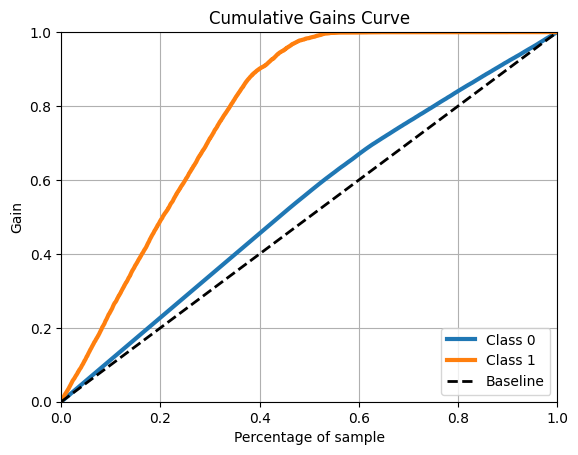

In [ ]:
# model definition
nb_model = GaussianNB()

# model training
nb_model.fit(x_train, y_train)

# model prediction
yhat_nb = nb_model.predict_proba(x_val)

#Acumilative Gain
skplt.metrics.plot_cumulative_gain(y_validation,yhat_nb);

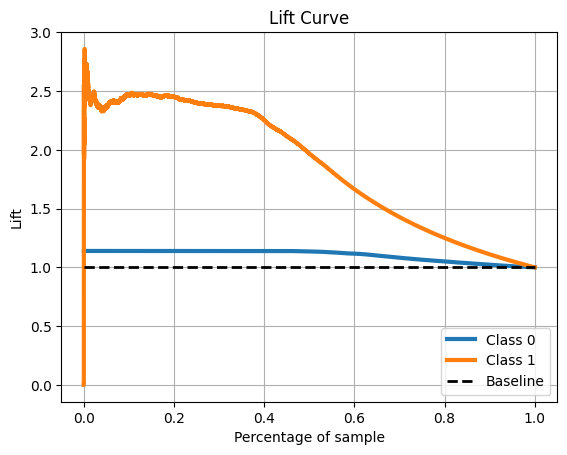

In [ ]:
skplt.metrics.plot_lift_curve(y_validation,yhat_nb);

In [ ]:
df_nb = cross_validation(nb_model,x_train,y_train,5,Verbose=True)
df_nb

Fold Number 1/5
Fold Number 2/5
Fold Number 3/5
Fold Number 4/5
Fold Number 5/5


,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
0,GaussianNB,0.7844 +/- 0.0005,0.2901 +/- 0.0015,0.7761 +/- 0.0041,0.8261 +/- 0.0023,0.6393 +/- 0.0011


##7.7 - Models Comparation

In [ ]:
model_performance_cv = pd.concat([df_knn,df_lr,df_et,df_rf,df_xgb,df_nb]).reset_index(drop=True)
model_performance_cv.sort_values('Recall @K Mean',ascending=False)

,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
4,XGBClassifier,0.5399 +/- 0.0012,0.2978 +/- 0.0016,0.7967 +/- 0.0042,0.8368 +/- 0.001,0.8661 +/- 0.0006
3,RandomForestClassifier,0.5447 +/- 0.0019,0.2928 +/- 0.0012,0.7833 +/- 0.0032,0.8318 +/- 0.0016,0.8648 +/- 0.0007
5,GaussianNB,0.7844 +/- 0.0005,0.2901 +/- 0.0015,0.7761 +/- 0.0041,0.8261 +/- 0.0023,0.6393 +/- 0.0011
2,ExtraTreesClassifier,0.5528 +/- 0.0016,0.2891 +/- 0.0013,0.7736 +/- 0.0036,0.8267 +/- 0.0016,0.8605 +/- 0.0009
1,LogisticRegression,0.5 +/- 0.0,0.2766 +/- 0.0025,0.74 +/- 0.0066,0.8178 +/- 0.0026,0.8774 +/- 0.0
0,KNeighborsClassifier,0.5494 +/- 0.0014,0.2746 +/- 0.0028,0.7348 +/- 0.0075,0.7826 +/- 0.0033,0.8609 +/- 0.0007


# 8.0. Performance Metrics

##8.1. Escolha do modelo

In [ ]:
df8 = x_validation.copy()
df8['response'] = y_validation.copy()

gain_knn = gain(df8,yhat_knn)
gain_et = gain(df8,yhat_et)
gain_rf = gain(df8,yhat_rf)
gain_xgb = gain(df8,yhat_xgb)
gain_nb = gain(df8,yhat_nb)

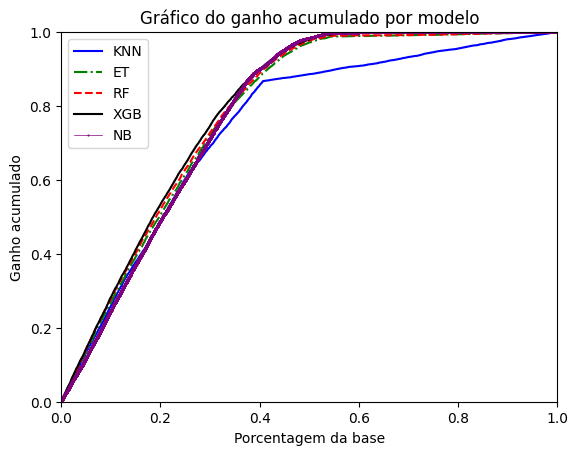

In [ ]:
plt.plot(gain_knn['base_porcentage'], gain_knn['recall'], label='KNN', color='blue')
plt.plot(gain_et['base_porcentage'], gain_et['recall'], '-.', label='ET', color='green')
plt.plot(gain_rf['base_porcentage'], gain_rf['recall'], '--', label='RF', color='red')
plt.plot(gain_xgb['base_porcentage'], gain_xgb['recall'], label='XGB', color='black')
plt.plot(gain_nb['base_porcentage'], gain_nb['recall'], '-o', linewidth=0.5, markersize=0.5, label='NB', color='purple')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel("Porcentagem da base")
plt.ylabel("Ganho acumulado")
plt.title("Gráfico do ganho acumulado por modelo")
plt.legend()
plt.show()

In [ ]:
k = [50,100,1000,2000,10000,20000,50000]
ganhos = [gain_knn['recall'],gain_et['recall'],gain_rf['recall'],gain_xgb['recall'],gain_nb['recall']]
modelos = ['KNN','Extra Forest','Random Forest','XGBoost','Naive Bayes']
ganhos_modelos = list(zip(ganhos, modelos))
for j in k:
    lista = []
    for ganho, modelo in ganhos_modelos:
        lista.append([modelo,ganho[j]])
    maior_valor = lista[0]
    for i in lista:
        if i[1] > maior_valor[1]:
            maior_valor = i
    print(f'Com os top {j}({round((j/df8.shape[0])*100,2)}%) do total da base, o melhor modelo foi {maior_valor[0]} atingindo {round(maior_valor[1]*100,2)}% daqueles que aceitarão o seguro')

Com os top 50(0.07%) do total da base, o melhor modelo foi Random Forest atingindo 0.2% daqueles que aceitarão o seguro
Com os top 100(0.13%) do total da base, o melhor modelo foi XGBoost atingindo 0.44% daqueles que aceitarão o seguro
Com os top 1000(1.31%) do total da base, o melhor modelo foi XGBoost atingindo 3.96% daqueles que aceitarão o seguro
Com os top 2000(2.62%) do total da base, o melhor modelo foi XGBoost atingindo 7.8% daqueles que aceitarão o seguro
Com os top 10000(13.12%) do total da base, o melhor modelo foi XGBoost atingindo 36.18% daqueles que aceitarão o seguro
Com os top 20000(26.24%) do total da base, o melhor modelo foi XGBoost atingindo 67.15% daqueles que aceitarão o seguro
Com os top 50000(65.6%) do total da base, o melhor modelo foi Naive Bayes atingindo 99.97% daqueles que aceitarão o seguro


In [ ]:
# Encontrar o índice do valor mínimo que seja maior ou igual à recall desejada
indice = np.argmax(gain_knn['recall'] >= 0.90)
indice

porcentagem = [0.50,0.75,0.80,0.85,0.90,0.95,0.97,0.98]

for porcent in porcentagem:
    lista = []
    for ganho, modelo in ganhos_modelos:
        indice = np.argmax(ganho >= porcent)
        lista.append([modelo,indice])
        menor_valor = lista[0]
    for i in lista:
        if i[1] < menor_valor[1]:
            menor_valor = i
    print(f'O melhor modelo é o {menor_valor[0]} atingindo {porcent*100}% daqueles que aceitarão o seguro com ({menor_valor[1]}) tentativas, ({round((menor_valor[1]/df8.shape[0])*100,2)}%) da base total')

O melhor modelo é o XGBoost atingindo 50.0% daqueles que aceitarão o seguro com (14111) tentativas, (18.51%) da base total
O melhor modelo é o XGBoost atingindo 75.0% daqueles que aceitarão o seguro com (22983) tentativas, (30.15%) da base total
O melhor modelo é o XGBoost atingindo 80.0% daqueles que aceitarão o seguro com (25123) tentativas, (32.96%) da base total
O melhor modelo é o XGBoost atingindo 85.0% daqueles que aceitarão o seguro com (27540) tentativas, (36.13%) da base total
O melhor modelo é o Naive Bayes atingindo 90.0% daqueles que aceitarão o seguro com (30381) tentativas, (39.86%) da base total
O melhor modelo é o Naive Bayes atingindo 95.0% daqueles que aceitarão o seguro com (34105) tentativas, (44.74%) da base total
O melhor modelo é o Naive Bayes atingindo 97.0% daqueles que aceitarão o seguro com (35774) tentativas, (46.93%) da base total
O melhor modelo é o Naive Bayes atingindo 98.0% daqueles que aceitarão o seguro com (37188) tentativas, (48.79%) da base total




##8.2. Melhor modelo escolhido foi o XGBoost



In [ ]:
#Definindo parâmetros aleatórios para o Random Search
param = {
    'n_estimators':[1500,1700,2500,3000,3500],
    'eta':[0.01,0.03],
    'max_depth':[3,5,9],
    'subsample':[0.1,0.5,0.7],
    'colsample_bytree':[0.3,0.7,0.9],
    'min_child_weight':[3,8,15]}

max_eval = 5

{'n_estimators': 1700, 'eta': 0.03, 'max_depth': 3, 'subsample': 0.7, 'colsample_bytree': 0.9, 'min_child_weight': 8}
{'n_estimators': 1700, 'eta': 0.03, 'max_depth': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 15}
{'n_estimators': 3500, 'eta': 0.01, 'max_depth': 9, 'subsample': 0.1, 'colsample_bytree': 0.3, 'min_child_weight': 8}
{'n_estimators': 3000, 'eta': 0.03, 'max_depth': 9, 'subsample': 0.1, 'colsample_bytree': 0.9, 'min_child_weight': 15}
{'n_estimators': 1500, 'eta': 0.01, 'max_depth': 3, 'subsample': 0.1, 'colsample_bytree': 0.7, 'min_child_weight': 8}


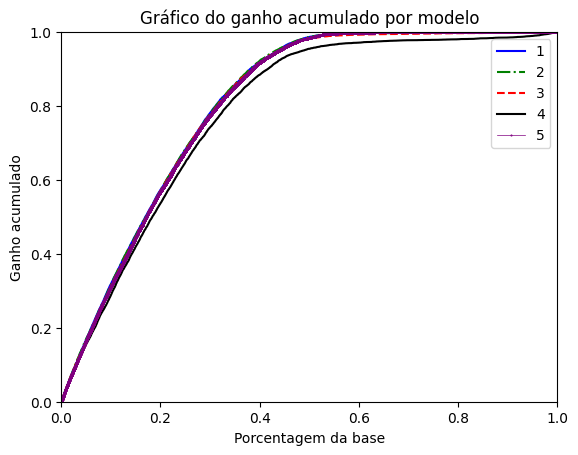

Com os top 50(0.07%) do total da base, o melhor teste foi 3 atingindo 0.31% daqueles que aceitarão o seguro
Com os top 100(0.13%) do total da base, o melhor teste foi 2 atingindo 0.56% daqueles que aceitarão o seguro
Com os top 1000(1.31%) do total da base, o melhor teste foi 2 atingindo 4.78% daqueles que aceitarão o seguro
Com os top 2000(2.62%) do total da base, o melhor teste foi 2 atingindo 9.49% daqueles que aceitarão o seguro
Com os top 10000(13.12%) do total da base, o melhor teste foi 2 atingindo 40.35% daqueles que aceitarão o seguro
Com os top 20000(26.24%) do total da base, o melhor teste foi 2 atingindo 70.74% daqueles que aceitarão o seguro
Com os top 50000(65.6%) do total da base, o melhor teste foi 5 atingindo 99.91% daqueles que aceitarão o seguro


In [ ]:
resultados = []
for i in range(max_eval):
    #choose valores for parameters randomly
    hp = {k: random.choice(v) for k, v in param.items()}
    print(hp)
    model_xgb = xgb.XGBClassifier( objective='reg:squarederror',
                                  n_estimators=hp['n_estimators'],
                                  eta=hp['eta'],
                                  max_depth=hp['max_depth'],
                                  subsample=hp['subsample'],
                                  colsample_bytree=hp['colsample_bytree'],
                                  min_child_weight=hp['min_child_weight'])

    # Treinando o modelo
    model_xgb.fit(x_train, y_train)

    # Fazendo previsões
    yhat_xgb = model_xgb.predict_proba(x_val)  # Previsão de probabilidade
    resultados.append(yhat_xgb)

gain_1 = gain(df8,resultados[0])
gain_2 = gain(df8,resultados[1])
gain_3 = gain(df8,resultados[2])
gain_4 = gain(df8,resultados[3])
gain_5 = gain(df8,resultados[4])

plt.plot(gain_knn['base_porcentage'], gain_1['recall'], label='1', color='blue')
plt.plot(gain_et['base_porcentage'], gain_2['recall'], '-.', label='2', color='green')
plt.plot(gain_rf['base_porcentage'], gain_3['recall'], '--', label='3', color='red')
plt.plot(gain_xgb['base_porcentage'], gain_4['recall'], label='4', color='black')
plt.plot(gain_nb['base_porcentage'], gain_5['recall'], '-o', linewidth=0.5, markersize=0.5, label='5', color='purple')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel("Porcentagem da base")
plt.ylabel("Ganho acumulado")
plt.title("Gráfico do ganho acumulado por modelo")
plt.legend()
plt.show()

k = [50,100,1000,2000,10000,20000,50000]
ganhos = [gain_1['recall'],gain_2['recall'],gain_3['recall'],gain_4['recall'],gain_5['recall']]
modelos = ['1','2','3','4','5']
ganhos_modelos = list(zip(ganhos, modelos))
for j in k:
    lista = []
    for ganho, modelo in ganhos_modelos:
        lista.append([modelo,ganho[j]])
    maior_valor = lista[0]
    for i in lista:
        if i[1] > maior_valor[1]:
            maior_valor = i
    print(f'Com os top {j}({round((j/df8.shape[0])*100,2)}%) do total da base, o melhor teste foi {maior_valor[0]} atingindo {round(maior_valor[1]*100,2)}% daqueles que aceitarão o seguro')

##8.3. Treinamento

Precision: 0.336133193340333

Recall: 0.7099260823653644


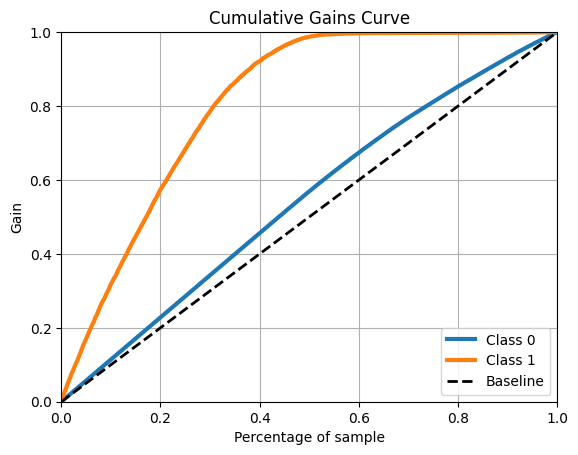

In [ ]:
model_xgb = xgb.XGBClassifier( objective='reg:squarederror',
                                  n_estimators=1700,
                                  eta=0.03,
                                  max_depth=5,
                                  subsample=0.7,
                                  colsample_bytree=0.7,
                                  min_child_weight=8)

# Treinando o modelo
model_xgb.fit(x_train, y_train)

# Fazendo previsões
yhat_xgb = model_xgb.predict_proba(x_val)  #Previsão de probabilidade

#Acumilative Gain
skplt.metrics.plot_cumulative_gain(y_validation,yhat_xgb);

df8 = x_validation.copy()
df8['response'] = y_validation.copy()

#propensity score
df8['score'] = yhat_xgb[:,1].tolist()

#sorted by propensity score
df8 = df8.sort_values('score',ascending=False)

#computing presicion at K
k_def = 20000
precision_at_20000 = precision_at_k(df8,k=k_def)
print(f'Precision: {precision_at_20000}')

#computing presicion at K
recall_at_20000 = recall_at_k(df8,k=k_def)
print(f'\nRecall: {recall_at_20000}')

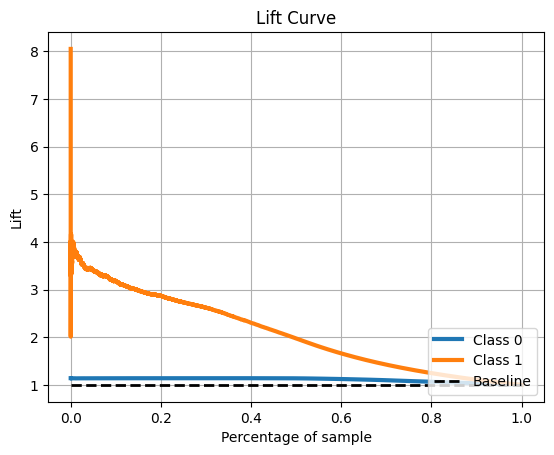

In [ ]:
#Curva Lift do modelo escolhido
skplt.metrics.plot_lift_curve(y_validation,yhat_xgb);
#Gerar as outras curvas de lift e comparar, talvez em outro ciclo

In [ ]:
# Fazendo previsões
yhat_xgb = model_xgb.predict_proba(x_val)  # Previsão de probabilidade
df8 = x_validation.copy()
df8['response'] = y_validation.copy()

#propensity score
df8['score'] = yhat_xgb[:,1].tolist()

#sorted by propensity score
df8 = df8.sort_values('score',ascending=False)

In [ ]:
yhat_model = model_xgb.predict(x_val)

# ROC AUC SCORE
auc_roc = roc_auc_score(df8['response'], df8['score'])


# TOP K SCORE
knum = df8['response'].value_counts().count()-1
top_k = top_k_accuracy_score(df8['response'],yhat_model,k=knum)


# Balanced Accuracy
accuracy_balanced = balanced_accuracy_score(y_validation,yhat_model)


# Precision at K
precision_k = precision_at_k(df8,20000)


# Recall at K
recall_k = recall_at_k(df8,20000)


df = pd.DataFrame({'Model Name': 'XGBoost Classifier',
                       'Accuracy Balanced': np.round(accuracy_balanced,4).astype(str),
                       'Precision @K Mean': np.round(precision_k,4).astype(str),
                       'Recall @K Mean': np.round(recall_k,4).astype(str),
                       'ROC AUC Score': np.round(auc_roc,4).astype(str),
                       'Top K Score': np.round(top_k,4).astype(str) },index = [0])

df

,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
0,XGBoost Classifier,0.5017,0.3361,0.7099,0.8544,0.875


In [ ]:
roc_auc_score(df8['response'], df8['score'])

np.float64(0.8543534450138248)

In [ ]:
df_final_model = cross_validation(model_xgb,x_train,y_train,5,Verbose=True)
df_final_model

Fold Number 1/5
Fold Number 2/5
Fold Number 3/5
Fold Number 4/5
Fold Number 5/5


,Model Name,Accuracy Balanced,Precision @K Mean,Recall @K Mean,ROC AUC Score,Top K Score
0,XGBClassifier,0.5016 +/- 0.0004,0.3084 +/- 0.0012,0.8282 +/- 0.0031,0.8535 +/- 0.0011,0.8778 +/- 0.0001


In [ ]:
len(y_validation)

76222

##8.4. Definição ROI

###8.3.1 - Para 20.000 tentativas, qual a porcentagem da base que eu acerto?


Recall: 0.706878080137133


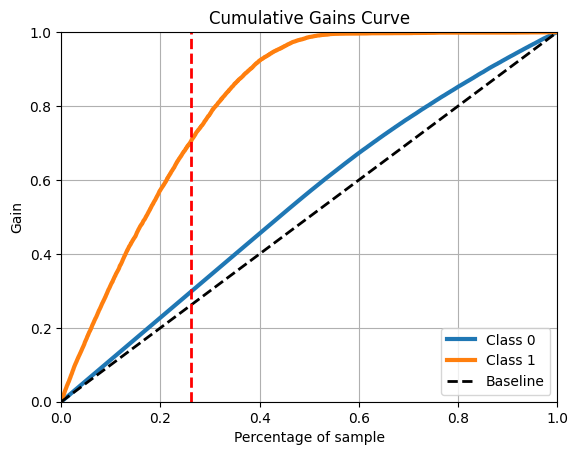

In [ ]:
#computing presicion at K
recall_at_20000 = recall_at_k(df8,k=20000)
print(f'\nRecall: {recall_at_20000}')

skplt.metrics.plot_cumulative_gain(y_validation, yhat_xgb)

# Índice que corresponde a 20000 amostras (ou o valor desejado) no eixo x
num_samples_to_compare = 20000
x_index = num_samples_to_compare / len(y_validation)

# Adicionando a linha vertical na posição desejada
plt.axvline(x=x_index, color='r', linestyle='--', label=f'Posição {num_samples_to_compare} amostras', linewidth=2);

###8.3.2 - Para 20.000 tentativas, quantas vezes o meu modelo é melhor que o modelo aleatório?

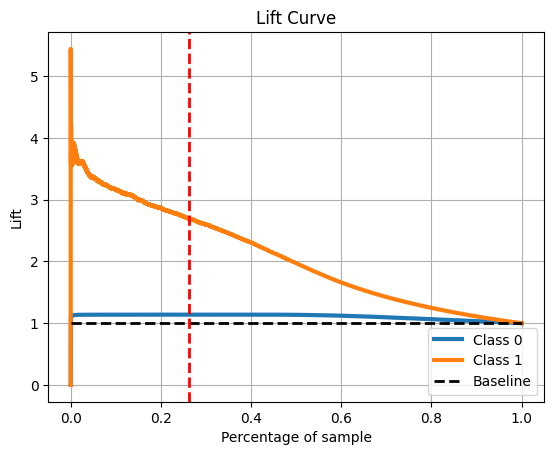

In [ ]:
# Plot da curva lift
skplt.metrics.plot_lift_curve(y_validation, yhat_xgb)

# Índice que corresponde a 20000 amostras (ou o valor desejado) no eixo x
num_samples_to_compare = 20000
x_index = num_samples_to_compare / len(y_validation)

# Adicionando a linha vertical na posição desejada
plt.axvline(x=x_index, color='r', linestyle='--', label=f'Posição {num_samples_to_compare} amostras', linewidth=2);

###8.3.3 - Para 40.000 tentativas, qual a porcentagem da base que eu acerto?


Recall: 0.9921791300621384


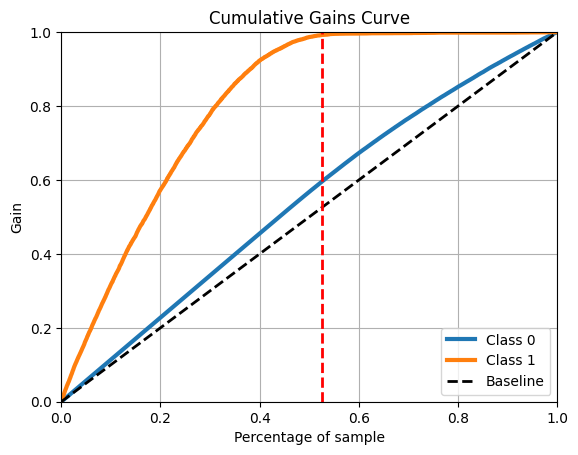

In [ ]:
#computing presicion at K
k_def = 40000
recall_at_40000 = recall_at_k(df8,k=k_def)
print(f'\nRecall: {recall_at_40000}')

skplt.metrics.plot_cumulative_gain(y_validation, yhat_xgb)

# Índice que corresponde a 40000 amostras (ou o valor desejado) no eixo x
num_samples_to_compare = 40000
x_index = num_samples_to_compare / len(y_validation)

# Adicionando a linha vertical na posição desejada
plt.axvline(x=x_index, color='r', linestyle='--', label=f'Posição {num_samples_to_compare} amostras', linewidth=2);

###8.3.4 - Para 40.000 tentativas, quantas vezes o meu modelo é melhor que o modelo aleatório?

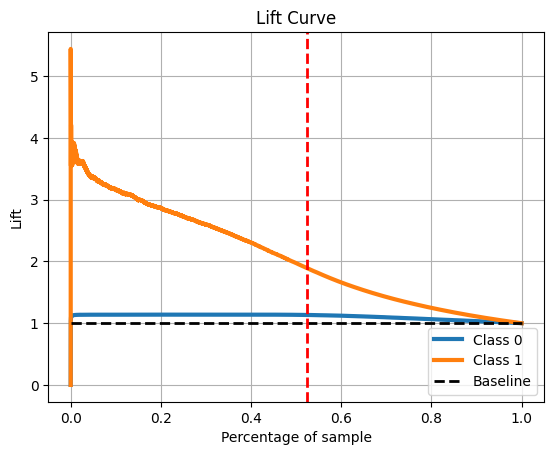

In [ ]:
skplt.metrics.plot_lift_curve(y_validation, yhat_xgb)

# Índice que corresponde a 40000 amostras (ou o valor desejado) no eixo x
num_samples_to_compare = 40000
x_index = num_samples_to_compare / len(y_validation)

# Adicionando a linha vertical na posição desejada
plt.axvline(x=x_index, color='r', linestyle='--', label=f'Posição {num_samples_to_compare} amostras', linewidth=2);

###8.3.5 - Para atingir 80% do total de acertos, quanto % da base usarei?

0.31152423184907246


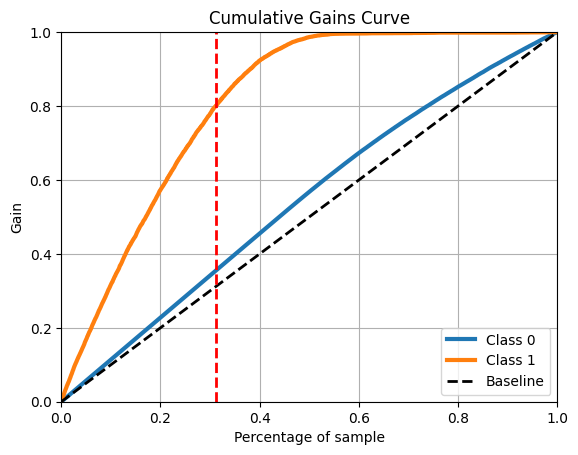

In [ ]:
df8 = x_validation.copy()
df8['response'] = y_validation.copy()
gain_xgb = gain(df8,yhat_xgb)
ganho = gain_xgb['recall']
porcent = 0.80
indice = np.argmax(ganho >= porcent)
print(indice/df8.shape[0])

skplt.metrics.plot_cumulative_gain(y_validation, yhat_xgb)

# Índice que corresponde a 20000 amostras (ou o valor desejado) no eixo x
num_samples_to_compare = indice
x_index = num_samples_to_compare / len(y_validation)

# Adicionando a linha vertical na posição desejada
plt.axvline(x=x_index, color='r', linestyle='--', label=f'Posição {num_samples_to_compare} amostras', linewidth=2);

<li>Portanto, se pegarmos todos os clientes do conjunto de dados de validação, teremos um total de 76.222 clientes.</li>
<li>Agora vamos calcular a receita que seria gerada a partir deste conjunto de dados de acordo com as questões de negócios solicitadas com o preço fixo de um seguro de U$ 2.000,00 por ano e não colocando na questão o custo de cada ligação para a empresa.</li>

In [ ]:
df8['response'].value_counts()

,count
response,
0,66888
1,9334


In [ ]:
#São 9334 pessoas interessadas em obter o seguro

df8 = x_validation.copy()
df8['response'] = y_validation.copy()

#propensity score
df8['score'] = yhat_xgb[:,1].tolist()

#sorted by propensity score
df9 = df8.sort_values('score',ascending=False)
df10 = df8.copy()

###8.3.6 - Comparação do modelo treinado contra o aleatório para 20.000 tentativas.

In [ ]:
recall_df9 = recall_at_k(df9,k=20000)
print(f'\nEm 20.000 tentativas, o modelo treinado atinge: {round((recall_df9*9256),0)} - {round((recall_df9)*100,2)}% do total de acertos.')
recall_df10 = recall_at_k(df10,k=20000)
print(f'\nEm 20.000 tentativas, o modelo treinado atinge: {round((recall_df10*9256),0)} - {round((recall_df10)*100,2)}% do total de acertos.')

print(f'\nSe para cada seguro fechado o valor é de U$ 2.000,00, qual o valor gerado por cada modelo?')

receita_df9 = recall_df9*9256*2000
receita_df10 = recall_df10*9256*2000

print(f'\nPara o modelo treinado a receita anual gerado é de: U${round((receita_df9),2)}')
print(f'\nPara o modelo aleatório a receita anual gerado é de: U${round((receita_df10),2)}')
print(f'\nPara o modelo treinado gera U${round((receita_df9),2) - round((receita_df10),2)} de receita anual a mais que o aletório')


Em 20.000 tentativas, o modelo treinado atinge: 6543.0 - 70.69% do total de acertos.

Em 20.000 tentativas, o modelo treinado atinge: 2395.0 - 25.87% do total de acertos.

Se para cada seguro fechado o valor é de U$ 2.000,00, qual o valor gerado por cada modelo?

Para o modelo treinado a receita anual gerado é de: U$13085727.02

Para o modelo aleatório a receita anual gerado é de: U$4789637.88

Para o modelo treinado gera U$8296089.14 de receita anual a mais que o aletório


###8.3.7 - Comparação do modelo treinado contra o aleatório para 40.000 tentativas.

In [ ]:
recall_df9 = recall_at_k(df9,k=40000)
print(f'\nEm 40.000 tentativas, o modelo treinado atinge: {round((recall_df9*9256),0)} - {round((recall_df9)*100,2)}% do total de acertos.')
recall_df10 = recall_at_k(df10,k=40000)
print(f'\nEm 40.000 tentativas, o modelo treinado atinge: {round((recall_df10*9256),0)} - {round((recall_df10)*100,2)}% do total de acertos.')

print(f'\nSe para cada seguro fechado o valor é de U$ 2.000,00, qual o valor gerado por cada modelo?')

receita_df9 = recall_df9*9256*2000
receita_df10 = recall_df10*9256*2000

print(f'\nPara o modelo treinado a receita anual gerado é de: U${round((receita_df9),2)}')
print(f'\nPara o modelo aleatório a receita anual gerado é de: U${round((receita_df10),2)}')
print(f'\nPara o modelo treinado gera U${round((receita_df9),2) - round((receita_df10),2)} de receita anual a mais que o aletório')


Em 40.000 tentativas, o modelo treinado atinge: 9184.0 - 99.22% do total de acertos.

Em 40.000 tentativas, o modelo treinado atinge: 4847.0 - 52.37% do total de acertos.

Se para cada seguro fechado o valor é de U$ 2.000,00, qual o valor gerado por cada modelo?

Para o modelo treinado a receita anual gerado é de: U$18367220.06

Para o modelo aleatório a receita anual gerado é de: U$9694306.41

Para o modelo treinado gera U$8672913.649999999 de receita anual a mais que o aletório


###8.3.8 - Comparação do modelo treinado contra o aleatório para 80% do total de acertos.

In [ ]:
porcent = 0.80

#create ranking order
df9['ranking'] = df9.index + 1 #Pra não começar do 0
#cumsum - soma acumulada
df9['recall'] = df9['response'].cumsum()/df9['response'].sum()
ganho_df9 = df9['recall']
indice_df9 = np.argmax(ganho_df9 >= porcent)
print(f'\nPara alcançar 80% do total de pessoas interessadas o modelo treino precisa de {indice_df9} tentativa.')

df10['ranking'] = df10.index + 1 #Pra não começar do 0
 #cumsum - soma acumulada
df10['recall'] = df10['response'].cumsum()/df10['response'].sum()
ganho_df10 = df10['recall']
porcent = 0.80
indice_df10 = np.argmax(ganho_df10 >= porcent)
print(f'\nPara alcançar 80% do total de pessoas interessadas o modelo aleatório precisa de {indice_df10} tentativa.')

print(f'\nAssim, o modelo treinado alcança a mesma porcentagem de acertos com {indice_df10 - indice_df9} tentativas a menos.')


Para alcançar 80% do total de pessoas interessadas o modelo treino precisa de 23745 tentativa.

Para alcançar 80% do total de pessoas interessadas o modelo aleatório precisa de 60648 tentativa.

Assim, o modelo treinado alcança a mesma porcentagem de acertos com 36903 tentativas a menos.


# 9.0. Deploy to Production

In [ ]:
# Create 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Save trained model
pickle.dump( model_xgb, open( 'models/xgb_model.pkl', 'wb' ) )

In [ ]:
from google.colab import files

# Download the scaler files from the 'models' directory
files.download('models/xgb_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import time

# Download the scaler files from the 'features' directory
downloads_features = ['features/annual_premium_scaler.pkl',
                      'features/age_scaler.pkl',
                      'features/vintage_scaler.pkl',
                      'features/target_encode_gender_scaler.pkl',
                      'features/target_encode_region_code_scaler.pkl',
                      'features/fe_policy_sales_channel_scaler.pkl']

for download in downloads_features:
    files.download(download)
    time.sleep(1)  # espera 1 segundo entre cada download

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9.1. Health Insurance Class

In [1]:
import pickle
import numpy  as np
import pandas as pd

class HealthInsurance:

    def __init__( self ):
        self.home_path = 'D:/repos/health_insurance_cross-sell/'
        self.annual_premium_scaler =            pickle.load( open( self.home_path + 'src/features/annual_premium_scaler.pkl' ) )
        self.age_scaler =                       pickle.load( open( self.home_path + 'src/features/age_scaler.pkl' ) )
        self.vintage_scaler =                   pickle.load( open( self.home_path + 'src/features/vintage_scaler.pkl' ) )
        self.target_encode_gender_scaler =      pickle.load( open( self.home_path + 'src/features/target_encode_gender_scaler.pkl' ) )
        self.target_encode_region_code_scaler = pickle.load( open( self.home_path + 'src/features/target_encode_region_code_scaler.pkl' ) )
        self.fe_policy_sales_channel_scaler =   pickle.load( open( self.home_path + 'src/features/fe_policy_sales_channel_scaler.pkl' ) )

    def data_cleaning( self, df1 ):
        # 1.1. Rename Columns
        cols_new = ['id', 'gender', 'age', 'driving_license', 'region_code', 'previously_insured', 'vehicle_age',
                    'vehicle_damage', 'annual_premium', 'policy_sales_channel', 'vintage', 'response']

        # rename
        df1.columns = cols_new

        return df1


    def feature_engineering( self, df2 ):
        # 2.0. Feature Engineering

        # Vehicle Damage Number
        df2['vehicle_damage'] = df2['vehicle_damage'].apply( lambda x: 1 if x == 'Yes' else 0 )

        # Vehicle Age
        df2['vehicle_age'] =  df2['vehicle_age'].apply( lambda x: 'over_2_years' if x == '> 2 Years' else 'between_1_2_year' if x == '1-2 Year' else 'below_1_year' )

        return df2


    def data_preparation( self, df5 ):
        # anual premium - StandarScaler
        df5['annual_premium'] = self.annual_premium_scaler.transform( df5[['annual_premium']].values )

        # Age - MinMaxScaler
        df5['age'] = self.age_scaler.transform( df5[['age']].values )

        # Vintage - MinMaxScaler
        df5['vintage'] = self.vintage_scaler.transform( df5[['vintage']].values )

        # gender - One Hot Encoding / Target Encoding
        df5.loc[:, 'gender'] = df5['gender'].map( self.target_encode_gender )

        # region_code - Target Encoding / Frequency Encoding
        df5.loc[:, 'region_code'] = df5['region_code'].map( self.target_encode_region_code )

        # vehicle_age - One Hot Encoding / Frequency Encoding
        df5 = pd.get_dummies( df5, prefix='vehicle_age', columns=['vehicle_age'] )

        # policy_sales_channel - Target Encoding / Frequency Encoding
        df5.loc[:, 'policy_sales_channel'] = df5['policy_sales_channel'].map( self.fe_policy_sales_channel )

        # Feature Selection
        cols_selected = ['annual_premium', 'vintage', 'age', 'region_code', 'vehicle_damage', 'previously_insured',
                         'policy_sales_channel']

        return df5[ cols_selected ]


    def get_prediction( self, model, original_data, test_data ):
        # model prediction
        pred = model.predict_proba( test_data )

        # join prediction into original data
        original_data['prediction'] = pred

        return original_data.to_json( orient='records', date_format='iso' )

## 9.2. API Handler

In [5]:
import os
import pickle
import pandas as pd
from flask import Flask, request, Response
from healthinsurance import HealthInsurance

# loading model
path = 'D:/repos/health_insurance_cross-sell/'
model = pickle.load( open( path + 'src/models/xgb_model.pkl', 'rb' ) )

# initialize API
app = Flask( __name__ )

@app.route( '/heathinsurance/predict', methods=['POST'] )
def health_insurance_predict():
    test_json = request.get_json()

    if test_json: # there is data
        if isinstance( test_json, dict ): # unique example
            test_raw = pd.DataFrame( test_json, index=[0] )

        else: # multiple example
            test_raw = pd.DataFrame( test_json, columns=test_json[0].keys() )

        # Instantiate Rossmann class
        pipeline = HealthInsurance()

        # data cleaning
        df1 = pipeline.data_cleaning( test_raw )

        # feature engineering
        df2 = pipeline.feature_engineering( df1 )

        # data preparation
        df3 = pipeline.data_preparation( df2 )

        # prediction
        df_response = pipeline.get_prediction( model, test_raw, df3 )

        return df_response

    else:
        return Response( '{}', status=200, mimetype='application/json' )

if __name__ == '__main__':
    port = os.environ.get('PORT', 5000)
    app.run( '0.0.0.0', port=port )

ModuleNotFoundError: No module named 'healthinsurance'

## 9.3. API Tester

In [2]:
import requests
import json

In [ ]:
# loading test dataset
df_test = x_validation
df_test['response'] = y_validation

In [ ]:
df_test = df_test.sample(10)

In [ ]:
# convert dataframe to json
data = json.dumps( df_test.to_dict( orient='records' ) )

In [ ]:
data

'[{"id": 74147, "gender": "Female", "age": 26, "driving_license": 1, "region_code": 28.0, "previously_insured": 0, "vehicle_age": "between_1_2_year", "vehicle_damage": 1, "annual_premium": 43343.0, "policy_sales_channel": 124.0, "vintage": 288, "response": 0}, {"id": 322299, "gender": "Male", "age": 44, "driving_license": 1, "region_code": 28.0, "previously_insured": 0, "vehicle_age": "between_1_2_year", "vehicle_damage": 1, "annual_premium": 45209.0, "policy_sales_channel": 124.0, "vintage": 230, "response": 0}, {"id": 331804, "gender": "Female", "age": 43, "driving_license": 1, "region_code": 15.0, "previously_insured": 0, "vehicle_age": "between_1_2_year", "vehicle_damage": 1, "annual_premium": 26894.0, "policy_sales_channel": 26.0, "vintage": 171, "response": 0}, {"id": 363080, "gender": "Male", "age": 44, "driving_license": 1, "region_code": 28.0, "previously_insured": 0, "vehicle_age": "between_1_2_year", "vehicle_damage": 0, "annual_premium": 41405.0, "policy_sales_channel": 23.

In [ ]:
# API Call
#url = 'http://0.0.0.0:5000/predict'
url = 'https://health-insurance-cross-sell-prediction-k2oj.onrender.com/predict'
header = {'Content-type': 'application/json' }

r = requests.post( url, data=data, headers=header )
print( 'Status Code {}'.format( r.status_code ) )

Status Code 200


In [ ]:
d1 = pd.DataFrame( r.json(), columns=r.json()[0].keys() )
d1.sort_values( 'score', ascending=False ).head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response,score
3,363080,0.138780,0.369231,1,0.187988,0,below_1_year,0,0.492486,23.0,0.930796,0,0.050289
7,318230,0.138780,0.230769,1,0.187988,0,below_1_year,0,-0.511883,26.0,0.615917,0,0.044430
0,74147,0.099756,0.092308,1,0.187988,0,below_1_year,0,0.669245,124.0,0.961938,0,0.044017
1,322299,0.138780,0.369231,1,0.187988,0,below_1_year,0,0.839437,124.0,0.761246,0,0.041979
9,107812,0.138780,0.338462,1,0.187988,0,below_1_year,0,3.605010,26.0,0.640138,1,0.037594
